In [263]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn # To ignore some warnings from sklearn logistic regression
from sklearn.exceptions import ConvergenceWarning # To avoid logistic regression failing in case of perfect separation

import datetime
import numpy as np
from scipy.optimize import minimize # minimizing function for AIOLI
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import pandas as pd
from sklearn.linear_model import LogisticRegression # for classic logistic regression
from typing import Literal
from sklearn.neighbors import KDTree # For Knn for SMOTE

options={"disp": False} # To not get verbose from minimize function
np.set_printoptions(suppress=True, precision=4) #removes e notation
pd.options.display.float_format = '{:.10f}'.format # To remove e notation
from matplotlib.lines import Line2D

# Global variables

In [ ]:
default_n = 100
default_runs = 10
default_test_size = 100

# Algorithms

## Helper functions for algorithms

In [ ]:
def sig(z):
    """ Sigmoid function that avoids overflow """
    if z < 0:
        return np.exp(z) / (1 + np.exp(z))
    else:
        return 1 / (1 + np.exp(-z))

In [ ]:
def calculate_OTB(array, method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None, p = 0.5):
    """ Weighted average function
    ----
    Parameters:
        p: Proportion of last observations to average over. Ex p = 0.3 means average over last 30% of observations.
    Methods:
        Suffix averaging: Average over last p percentage of observations.
        Uniform: Average over all iterates equally
        Last iterate: Consider only the last iterate.
        """
    n = len(array)
    # Check p is a proportion
    if p is None:
        p = 0.5
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    match method:
        case "suffix_averaging":
            i = round((1-p)*n)
            result = np.mean(array[i:], axis=0)
        case "last_iterate":
            last_iterate = n - 1
            result = array[last_iterate]
        case _: # Uniform is default
            result = np.mean(array, axis=0)

    return result

In [ ]:
def log_loss(betas,data_x,data_y):
    """ Works for a vector of betas and a whole dataset """
    return np.mean(np.logaddexp(0,-data_y*np.inner(data_x,betas)))

In [ ]:
def generate_x(n,d, correlated = False, means = None, sds = None, highly_correlated = False, seed = 40, standardized = False):
    seed_used = seed
    rng = np.random.default_rng(seed) # Random number generator
    x = []

    if sds is None:
        sds = rng.uniform(0.1,0.5,d)
    if means is None:
        means = [rng.normal(1,sd,1).item() for sd in sds]
    # Put variances in covariance matrix
    cov = np.diag(sds**2)

    if not correlated:
        x = rng.multivariate_normal(means,cov, size = n)
    if correlated:
        # Create off diagonal, triangular matrix
        off_diag = np.triu(rng.uniform(0,2, size = (d,d)))
        cov = cov + off_diag + off_diag.T
        x = rng.multivariate_normal(means,cov, size = n)
    if highly_correlated and d == 3:
        x1 = generate_x(n,1, seed = seed_used)
        x2 = x1 + rng.normal(2,1)
        x3 = x1 + x2
        x = np.concatenate((x1,x2,x3), axis = 1)

    if standardized:
        standardized_x = (x - np.mean(x, axis=0) ) / np.std(x, axis=0)
        x = standardized_x
    return x


In [286]:
ys = np.concatenate([np.repeat(1, 95), np.repeat(-1,5)])
sum(ys == 1)/len(ys)
# len(ys)
1/100 +0.01

0.02

In [ ]:
def generate_y(n,x, betas,method, seed = 40, plot = False, balanced = True):
    y = np.zeros(n)
    prob_y1 = np.zeros(n)
    rng = np.random.default_rng(seed) # Random number generator

    match method:
        case "sinusoidal":
            prob_y1 = [(1/2)*np.sin(2*np.inner(x_t,betas))+1/2 for x_t in x]

            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "quadratic":
            prob_y1 = [sig(np.inner((x_t**2),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "alternating":
            prob_y1 = 0.5 if balanced else 1/n+0.01
            y = rng.choice([1,-1],size = n, p = [prob_y1,1-prob_y1])

        case "sign":
            y = [np.sign(np.inner(x_t,betas)) for x_t in x]

        case "well specified": # Sigmoid function is default
            prob_y1 = [sig(np.inner(x_t,betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

    # Graphs
    if plot:
        for i in range(x.shape[1]):
            sns.scatterplot(x = x[:,i].flatten(), y = prob_y1)
            plt.title(f"P(Y=1) over x{i+1}")
            plt.show()

    return np.array(y)

In [ ]:
(1/2)*np.sin(2*np.inner([1,-2,0.83],[2.4,0.8,-1.2]))+1/2

## Generate data

In [ ]:
def generate_data(setting, balanced = True, seed = 30, n = default_n, x_means = None, B = 4, a = 1, b = -1, plot_y = False, X_hazan = 1,d = 3, hyperparameter_analysis = False, betas = None, large_betas = False):
    # Allocate space for variables
    x = []
    y = []
    betas = [] if betas is None else betas
    # betas = betas
    rng = np.random.default_rng(seed)
    hazan_py1 = 0
    # Define x means based on balanced or unbalanced setting
    x_means_simulation = [1,-2,0.83] if x_means is None else x_means
    x_means_simulation = [-2,-1.7,1.5] if hyperparameter_analysis else x_means_simulation
    # test_size = round(default_test_ratio*n)
    test_size = default_test_size
    full_n = n+test_size
    av_sigma_hidden = None

    # Generate data according to setup
    match setting:
        case "well specified":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if hyperparameter_analysis:
                betas = [1.4,-3.3,-1.9] if balanced else [1,-0.6,3.9]
                betas = np.array(betas)*10 if large_betas else betas
            elif None in betas or len(betas) == 0:
                betas = [0.4,-0.3,-1.2] if balanced else [-1,-1.7,2.6] # average sigmoid balanced: 0.5, unbalanced : 0.01

            y = generate_y(full_n,x,betas = betas, seed = seed, method = "well specified")

        case "high dimensional" | "hidden x":
            # Define betas and x means to fit high dimensionality
            betas = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7] if balanced else [2,1.8,-3.7,1.4,0.5,0.2,-1,-0.3,2.2,0.1,0.6,1.9,-1.4,2.7,-1.4,0.5,-1,3.2,1.5,-1.5,-2.4,1.2,3.6,-0.8,-1.2]
            x_means_simulation = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]
            if hyperparameter_analysis:
                x_means_simulation = [2, -4.2, 1, 2.4, -1.6, -3.8, -5, -4.1,0.2, 6, 1, -3, 4.2, -2.1,5.6, -6,6.3, 4.5, -1.3, 6.2, 2.3, 1.4, 4, -2, 2] if balanced else [2, -4.2, 1, 2.4, -1.6, -3.8, -5, -4.1,0.2, 6, 1, -3, 4.2, -2.1,5.6, -6,6.3, 5.8, -1.3, 6.2, 2.3, 1.4, 4, -2, 2.6]
            # Generate x again for the high dimensional setting
            x = generate_x(full_n,25, means = x_means_simulation, seed = seed)
            y = generate_y(full_n,x,betas = betas, seed = seed, method = "well specified")
            if setting == "hidden x":
                av_sigma_hidden = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
                betas = betas[:3]
                x = x[:,:3]

        case "quadratic":
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if hyperparameter_analysis:
                betas = [1.5,1.7,3.9] if balanced else [1,-0.6,3]
            else:
                betas = [-1.44,0.5,-0.8] if balanced else [0.9,-1.1,-1.2]
            y = generate_y(full_n,x,betas = betas, seed = seed, method = "quadratic")
        case "hazan 1-dimensional":
            # B = np.log(full_n) if B_hazan is None else B_hazan
            B = 1.5 if hyperparameter_analysis else 1
            # B = 300
            # epsilon = (B**(2/3))/(n**(2/3))
            epsilon = 0.01
            theta = np.sqrt(epsilon)/B
            hazan_py1 = theta/2 + X_hazan*epsilon/B
            xy = rng.choice([[1- theta/2,a],[theta,b]], size = full_n, p = [theta/2 + X_hazan*epsilon/B, 1- (theta/2 + X_hazan*epsilon/B)])
            x = xy[:,0]
            y = xy[:,1]
            x = x.reshape(full_n,1)

        case "alternating":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if hyperparameter_analysis:
                betas = [1,2.5,0.3]
            elif None in betas or len(betas) == 0:
                betas = [2.4,0.8,-1.2]
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "alternating", balanced = balanced)
        case "sinusoidal":
            if not balanced:
                print("Sinusoidal will not be studied in unbalanced case")
            # Generate data

            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if hyperparameter_analysis:
                betas = [1.5,-1,-0.9]
            elif None in betas or len(betas) == 0:
                betas = [2.4,1.8,-0.7] if balanced else [-1.1,0.5,-0.8] # unbalanced average 0.325 on seed 30
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "sinusoidal")

        case "sign":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed, sds = np.array([1,1,1]))
            if hyperparameter_analysis:
                betas = [-2.3,1.2,-1.4] if balanced else [-1.3,2.6,-3.9]
            elif None in betas or len(betas) == 0:
                betas = [-0.8,-1.4,-2.6] if balanced else [1.3,-3.7,-1.2] # average
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "sign")

        case "binomial_x":
            if hyperparameter_analysis:
                x = rng.binomial(n=6,p=0.4,size = (full_n,d))
                betas = [-2.3,1.2,1.1] if balanced else [1.5,-1,-2.9]
            else:
                x = rng.binomial(n = 5, p = 0.7, size = (full_n,d))
                # betas = rng.uniform(size = d,low = -0.5,high = 0.8)
                betas = [1.3,0.3,-1.4] if balanced else [1.5,-1,-2.9]
            # Just to have the correct d later
            x_means_simulation = np.zeros(d)
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "well specified")

    if setting == "hazan 1-dimensional":
        print(f"{n} (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of {hazan_py1}")
    else:
        d = len(x_means_simulation)
        if setting == "sign" or setting == "alternating":

            print(f"{n} (training) samples were generated in the {setting} {"balanced" if balanced else "unbalanced"} setting. Using {d} variable(s), with an average P(Y=1) of {sum(y == 1)/len(y)}")
        else:
            av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3) if av_sigma_hidden is None else av_sigma_hidden
            av_sin = round(np.mean( [(1/2)*np.sin(5*xb) +1/2 for xb in np.inner(x,betas)]),3)
            print(f"{n} (training) samples were generated in the {setting} {"balanced" if balanced else "unbalanced"} setting. Using {d} variable(s), with an average P(Y=1) of {av_sin if setting == "sinusoidal" else av_sigma}{" using large betas." if large_betas else "."}")

    # Make train/test split

    x_train = x[test_size:]
    y_train = y[test_size:]
    x_test = x[:test_size]
    y_test = y[:test_size]

    return x_train, y_train, x_test, y_test

In [ ]:
a,b,c,d= generate_data("hazan 1-dimensional",balanced = False, n = 100, hyperparameter_analysis=True)

print(sum(b == 1)/len(b))
print(sum(d == 1)/len(d))


## Online Gradient Descent

In [ ]:
def online_gd(data_y, data_x, OTB_method = None, OTB_average_proportion = None):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.

    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)
    y_hat = np.zeros(n)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        y_hat[t] = sig(np.inner(betas[t],xt))

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0

    # Store endtime
    end_time =  datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas,
        "predictions": y_hat
    }


### Testing ODG

In [ ]:
#ogd = online_gd(n = 40,d = 3,data_y = y,data_x = x,B = 40)

## AIOLI

In [ ]:
class AIOLI:
    def __init__(self):
        self.first_sum  = []
        self.etas_gradients = []
        self.x0 = [] # Initializer for minimizing algorithm
        self.reg_lambda = 0
        self.train_size = 0
        self.d = 0
        self.n = 0

    # Define function to minimize for AIOLI
    @staticmethod # Because I dont use the self
    def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
        l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
        # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
        result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
        return result

    def new_point_loss(self,X,Y, OTB_method):
        convergence_new = 0
        beta_hat = np.zeros((self.train_size,self.d))
        first_sum  = np.zeros(self.d)
        etas_gradients = np.zeros((self.d,self.d))
        for t in range(self.train_size):
            # Minimize using data up until t-1
            result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
            beta_hat[t] = result.x
            convergence_new += result.success
            # Update minimization elements for next round
            first_sum += self.first_sum[t]
            etas_gradients += self.etas_gradients[t]

        # Get OTB
        big_beta = calculate_OTB(beta_hat, OTB_method)

        # Suffer loss
        loss_point = np.logaddexp(0,-Y*np.inner(X,big_beta))

        return loss_point

    def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
        start_time = datetime.datetime.now()
        new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
        end_time = datetime.datetime.now()
        return{
                "runtime" : (end_time - start_time).total_seconds(),
                "loss" : np.mean(new_losses)
            }


    def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b", dynamic_B = False):
        """AIOLI
        This is the function to run AIOLI.

        Parameters
        ---------
        data_y : ndarray
            Vector with outcome(y) values. Dimensions: n x 1
        data_x: ndarray
            Array with independent variables. Dimensions: n x d
        B: float
            Radius of the L2 ball constraint for the parameter vector beta
        X: float
            Radius of the L2 ball constraint for the feature vector x"""
        # Record start time
        start_time = datetime.datetime.now()

        # Get data dimensions
        self.n = data_x.shape[0]
        n = self.n
        self.d = data_x.shape[1]
        d = self.d
        self.x0 = np.zeros(d) # Initializer for minimizing algorithm
        self.train_size = n
        # Initialize vectors for storage
        betas = np.zeros((n, d))
        ys = np.zeros(n)
        y_hats = np.zeros(n)
        loss = np.zeros(n)
        etas = np.zeros(n)
        gradients = np.zeros((n, d))
        self.reg_lambda = 1 / (B**2)

        # Keep sums for loss functions
        self.first_sum  = np.zeros((n, d))
        self.etas_gradients = np.zeros((n,d,d))
        first_sum  = np.zeros(d)
        etas_gradients = np.zeros((d,d))

        # Track convergence
        convergence = 0
        minimizer_gradient = 0

        # Run Algorithm
        for t in range(n):
            # Get context vector
            xt = data_x[t]

            # Update beta parameter
            # noinspection PyTypeChecker # This is to avoid the underlining which
            if t == 0: # Initialize to 0 for first round
                betas[t] = np.zeros(d)
            else:
                result = minimize(self.parameter_function_AIOLI,
                                  np.zeros(d),
                                  method = minimize_method,
                                  args=(xt, self.reg_lambda,first_sum, etas_gradients),
                                  options = {"maxiter":100000}
                                  )
                betas[t] = result.x
                convergence += result.success
                minimizer_gradient += np.linalg.norm(result.jac)

            # # Project beta onto set
            # betas[t] = project_onto_l2_ball(beta_tilde,B)
            # betas[t] = self.x0

            # Generate prediction
            y_hats[t] = np.inner(xt,betas[t])

            # Observe true y from data
            ys[t] = data_y[t]

             # Compute gradient
            gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

            # Estimate eta
            etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

            # Suffer loss
            loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))

            # Compute elements for AIOLI loss function

            fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
            eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
            self.first_sum[t] = fs
            self.etas_gradients[t] = eg
            first_sum += fs
            etas_gradients += eg
            # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.

            # Dynamic Hyperparameter tuning
            if dynamic_B:
                B = max(B, np.linalg.norm(betas[t]))

        # for loop ends

        # Get Batch estimate
        betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

        # Get Batch estimate loss
        loss_OTB = log_loss(betas_OTB,data_x, data_y)

        end_time = datetime.datetime.now()

        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "Total_Loss" : loss_OTB,
            "Online_Loss" : sum(loss),
            "Batch_estimate": betas_OTB,
            "All_Betas": betas,
            "convergence" : convergence,
            "minimizer_gradient" : minimizer_gradient
        }



### Testing AIOLI

AIOLI convergence check

In [ ]:
# aioli_model = AIOLI()
# aioli_results_nondynamic = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 1, minimize_method = "l-bfgs-b", dynamic_B = False)
# aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

In [ ]:
# aioli_model = AIOLI()
# aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = "l-bfgs-b", dynamic_B = True)
# aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

In [ ]:
# minimization_methods = ["l-bfgs-b",'bfgs',"CG"]
#
# for method in minimization_methods:
#     aioli_model = AIOLI()
#     aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 5, minimize_method = method)
#     print(f"Method: {method}")
#     print(f"convergence: {aioli_results["convergence"]}")
#     print(f"minimizer_gradient: {aioli_results["minimizer_gradient"]}")
#     print(f"Online loss: {aioli_results["Online_Loss"]}")


In [ ]:
# aioli_model.new_data_loss(new_data_x = x_test, new_data_y = y_test, OTB_method = "uniform")

## Ada Grad

In [ ]:
def online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = betas[t,i] - eta_ti*gradient[i]
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [ ]:
# x = generate_x(150,3, means= [2,2,1])
# betas = [2,20,-4.2]
# y = generate_y(150,x,betas = betas)
#
# x_train = x[:100]
# y_train = y[:100]
# x_test = x[100:]
# y_test = y[100:]
#
# standardized_x_train = (x_train - np.mean(x_train, axis=0) ) / np.std(x_train, axis=0)
#x_train = standardized_x_train

In [ ]:
# ag_trial = online_AdaGrad(y_train, x_train, np.repeat(40/13,3))
# ag_trial
# print(log_loss(ag_trial["Batch_estimate"],x_test,y_test))
# ag_u = calculate_OTB(ag_trial["All_Betas"], "uniform")
# ag_s  = calculate_OTB(ag_trial["All_Betas"], "suffix_averaging")
# ag_li  = calculate_OTB(ag_trial["All_Betas"], "last_iterate")
# print(f"{log_loss(ag_u,x_test,y_test)}, {log_loss(ag_s,x_test,y_test)},  {log_loss(ag_li,x_test,y_test)}" )


In [ ]:
# og_trial = online_gd(y_train, x_train, 40)
# og_trial
# log_loss(og_trial["Batch_estimate"],x_test,y_test)

## Logistic Regression

In [ ]:
def classic_logistic_regression(data_x, data_y):
    # Using safe implementation where if data is perfectly separable, then it's just fit minimizing the logistic loss.
    start_time = datetime.datetime.now()

    try:
        logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=10000)
        logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        # Single class case: fit manually using scipy minimize on the logistic loss
        def logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores))

        result = minimize(logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Logistic regression was fit manually")


    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [ ]:
x_train, y_train, x_test, y_test = generate_data(setting = "well specified", balanced = False, seed = 42, n =50)

In [ ]:
y_train

In [ ]:
b = classic_logistic_regression(x_train,y_train)["Batch_estimate"]
log_loss(b,x_test,y_test)

In [ ]:
# def classic_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty=None, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Ridge Logistic Regression

In [107]:
def ridge_logistic_regression(data_x, data_y, reg_lambda=0.1):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l2', C=1/reg_lambda, fit_intercept=False, max_iter=10000)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def ridge_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.linalg.norm(b)**2

        result = minimize(ridge_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Ridge LR was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [ ]:
# def ridge_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty="l2", random_state=1, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Lasso Logistic Regression

In [108]:
def lasso_logistic_regression(data_x, data_y, reg_lambda=0.1):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l1', C=1/reg_lambda, fit_intercept=False, max_iter=10000)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def lasso_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.abs(np.linalg.norm(b, ord = 1))

        result = minimize(lasso_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Lasso LR was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

## Sample Minmax Predictor (SMP)

In [ ]:
class sample_minmax_predictor():
    def __init__(self,data_x, data_y):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = sig(1*np.inner(beta_hat_y1,new_x)) / ( sig(np.inner(beta_hat_y1,new_x)*1) + sig(np.inner(beta_hat_y_1,new_x)*(-1)) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde)) # Here i have this so that i can actually calculate the loss for both outcomes, in the paper they have it reduced for simplicity, but what they mean is evaluate the density of the observed y, but f_tilde right now is only for y=1, so to calculate both i need to put it in this form instead of simpluy -log (f_tilde)

        # loss_point = np.logaddexp(0,-new_y*np.inner(new_x,beta_hat_y1))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : np.mean(new_losses),
            "loss_t" : new_losses
        }


### Testing SMP

In [ ]:
# smp = sample_minmax_predictor(x_train, y_train)
# smp.get_new_loss(x_test, y_test)

## Ridge-regularized SMP

In [ ]:
class ridge_sample_minmax_predictor():
    def __init__(self,data_x, data_y, reg_lambda = 0.1):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0
        self.n = 0
        self.reg_lambda = reg_lambda

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = (np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))) / (self.n + 1) + (self.reg_lambda/2) * np.linalg.norm(b)**2
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = (sig(1*np.inner(beta_hat_y1,new_x)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2)) / ( ( sig(np.inner(beta_hat_y1,new_x)*1) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2) )  + ( sig(np.inner(beta_hat_y_1,new_x)*(-1)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y_1)**2) ) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        self.n = self.data_x.shape[0]
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : np.mean(new_losses),
            "loss_t" : new_losses
        }


## SMOTE

In [ ]:
class SMOTE():
    def __init__(self,data_x, data_y ,seed = 40, k = 1, S = 100):
        """ This class performs SMOTE on a dataset. The apply_smote method returns the new data with synthetic samples """
        self.seed = seed
        self.rng = np.random.default_rng(self.seed)
        self.d = 0
        self.k = k
        self.Xmin = []
        self.new_data_y = []
        self.synthetic = [] # array to store synthetic samples
        self.new_i = 0 # variable to keep indices of new synthetic samples. Initialize to 0
        self.data_x = data_x
        self.data_y = data_y
        self.M = 0
        self.S = S
        self.oneclass = False

    def get_min_class_x(self):
        # Get proportion of y = 1
        prop_y1 = np.sum(self.data_y == 1) / len(self.data_y)
        # Get the value of y that is minority
        y_minority = 1 if prop_y1 < 0.5 else -1
        self.oneclass = True if prop_y1 == 1 or prop_y1 == 0 else False
        self.M = np.sum(self.data_y == y_minority)
        # Get only x values for which the outcome is part of the minority
        self.Xmin = self.data_x[self.data_y == y_minority]
        n_new_samples = int((self.S/100)*self.M)
        new_minority_ys = np.full(n_new_samples,y_minority)
        self.new_data_y = np.append(self.data_y,new_minority_ys)
        return True if prop_y1 == 0.5 else False

    def populate(self, s_j, i, nn_indices):
        while s_j != 0:
            # Chose one of the k nearest neighbours of i
            ss = self.rng.integers(0,self.k)
            # Now for every attribute
            for j in range(self.d):
                diff = self.Xmin[nn_indices[ss]][j] - self.Xmin[i][j]
                gap = self.rng.uniform(0,1)
                self.synthetic[self.new_i][j] = self.Xmin[i][j] + gap*diff
            # end for
            self.new_i += 1
            s_j -= 1

    def apply_smote(self):
        """Synthetic Minority Oversampling Technique (SMOTE)
        Parameters
        ---------
        Xmin : array
            Array of minority class samples
        M: int
            Number of minority class samples
        S: int
            Percentual amount of SMOTE
        """

        # Get the Xmin (x values with outcome from minority class)
        no_minority = self.get_min_class_x()

        if no_minority:
            print("Dataset is balanced")
            return self.data_x,self.data_y
        if self.oneclass:
            print("Dataset only has one class")
            return self.data_x,self.data_y
        if self.k > self.M:
            print("k must be smaller than the number of training samples")
            return self.data_x, self.data_y

        # If S is less than 100%, randomize the minority class samples as only a random percent of them will be SMOTEd
        if self.S < 100:
            self.M = (self.S/100)*self.M
            self.S = 100
        # Get number of synthetic samples
        s = int(self.S/100)
        # Get number of attributes
        self.d = self.Xmin.shape[1]
        # Assign correct dimensions to synthetic samples array
        self.synthetic = np.zeros((s*self.M,self.d))

        # Make k nearest neighbors tree
        tree = KDTree(self.Xmin)

        # Get synthetic samples for each datapoint
        for i in range(self.M):
            nn_indices = tree.query(self.Xmin[i:i+1], k = self.k)[1][0]  # First index [1] is to get only the item with the indices, that gives a dataframe of 1 row. Second index [0] is to get that row and simply get an array of the indices
            self.populate(s,i,nn_indices)
        new_data_x = np.concatenate((self.data_x, self.synthetic))
        return new_data_x,self.new_data_y



In [ ]:
np.concatenate((np.arange(1, 4, 1),np.array([np.log(100).round(1)]),np.arange(5,51,15)))
# np.array(np.log(100))

In [103]:
np.concatenate((np.arange(0.1, 1.1, 0.1).round(1),np.arange(2,5,1)))

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 2. , 3. , 4. ])

 # Hyperparameter selection

In [382]:
def hyperparameter_analysis(setting, algorithm, evaluated_parameter,balanced=True, seed=100,n=100, X_hazan=1, d=3, n_runs=20):

    records = []
    all_losses = []
    values = None
    x_means = [-2,-0.7,-0.5]
    # loss = []
    BX_sequence = np.concatenate((np.arange(1, 4, 1),np.array([np.log(100).round(1)]),np.arange(5,51,15)))
    lambda_sequence = np.concatenate((np.arange(0.1, 1.1, 0.1).round(1),np.arange(2,5,1)))
    for run in range(n_runs):
        run_seed = seed + run

        x_train, y_train, x_test, y_test = generate_data(setting, balanced, run_seed, n, x_means,
                                                hyperparameter_analysis = True,
                                                X_hazan = X_hazan,
                                                d = d
        )
        d_run = x_train.shape[1]

        match evaluated_parameter:
            case "B":
                match algorithm:
                    case "AIOLI":
                        values = BX_sequence
                        loss = np.zeros(len(values))
                        for i in range(len(values)):
                            aioli_model = AIOLI()
                            aioli_model.fit(data_y=y_train, data_x=x_train, X=1, B=values[i],
                                             minimize_method="l-bfgs-b", dynamic_B=False)
                            loss[i] = aioli_model.new_data_loss(
                                new_data_x=x_test, new_data_y=y_test, OTB_method="uniform"
                            )["loss"]
                        for v, l in zip(values, loss):
                            records.append({evaluated_parameter: v, "Risk": l, "run": run})

                    case "ADAGRAD":
                        values = BX_sequence
                        loss = np.zeros((len(values), 3))
                        for i in range(len(values)):
                            adagrad = online_AdaGrad(data_y=y_train, data_x=x_train,
                                                      B_vector=np.repeat(values[i], d_run))
                            ag_u = calculate_OTB(adagrad["All_Betas"], "uniform")
                            ag_s = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
                            ag_li = calculate_OTB(adagrad["All_Betas"], "last_iterate")
                            loss[i] = [log_loss(ag_u, x_test, y_test),
                                       log_loss(ag_s, x_test, y_test),
                                       log_loss(ag_li, x_test, y_test)]
                        for i, v in enumerate(values):
                            for method, col in zip(["uniform", "suffix", "last_iterate"], range(3)):
                                records.append({evaluated_parameter: v, "Risk": loss[i, col],
                                                 "run": run, "method": method})

            case "X":
                values = BX_sequence
                loss = np.zeros(len(values))
                for i in range(len(values)):
                    aioli_model = AIOLI()
                    aioli_model.fit(data_y=y_train, data_x=x_train, X=values[i], B=1,
                                     minimize_method="l-bfgs-b")
                    loss[i] = aioli_model.new_data_loss(
                        new_data_x=x_test, new_data_y=y_test, OTB_method="uniform"
                    )["loss"]
                for v, l in zip(values, loss):
                    records.append({evaluated_parameter: v, "Risk": l, "run": run})

            case "S":
                values = np.arange(100, 400, 100)
                loss = np.zeros(len(values))
                for i in range(len(values)):
                    sm = SMOTE(data_x=x_train, data_y=y_train, S=values[i])
                    smote_x, smote_y = sm.apply_smote()
                    classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
                    loss[i] = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
                for v, l in zip(values, loss):
                    records.append({evaluated_parameter: v, "Risk": l, "run": run})

            case "k":
                values = np.arange(1, 10, 1)
                loss = np.zeros(len(values))
                for i in range(len(values)):
                    sm = SMOTE(data_x=x_train, data_y=y_train, k=values[i], S=100)
                    smote_x, smote_y = sm.apply_smote()
                    classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
                    loss[i] = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
                for v, l in zip(values, loss):
                    records.append({evaluated_parameter: v, "Risk": l, "run": run})
            case "lambda":
                values = lambda_sequence
                loss = np.zeros(len(values))

                match algorithm:

                    case "Ridge_LR":
                        for i in range(len(values)):
                            ridge_LR = ridge_logistic_regression(data_x=x_train, data_y=y_train, reg_lambda = values[i])
                            loss[i] = log_loss(ridge_LR["Batch_estimate"], x_test, y_test)

                    case "Lasso_LR":
                        for i in range(len(values)):
                            lasso_LR = lasso_logistic_regression(data_x=x_train, data_y=y_train, reg_lambda = values[i])
                            loss[i] = log_loss(lasso_LR["Batch_estimate"], x_test, y_test)

                    case "Ridge_SMP":
                        for i in range(len(values)):
                            ridge_smp = ridge_sample_minmax_predictor(x_train, y_train, reg_lambda= values[i])
                            loss[i] = ridge_smp.get_new_loss(x_test, y_test)["loss"]

                for v, l in zip(values, loss):
                    records.append({evaluated_parameter: v, "Risk": l, "run": run})

        all_losses.append(loss)

    df = pd.DataFrame.from_records(records)

    # Graph
    match algorithm:
        case "AIOLI" | "SMOTE" | "Ridge_LR"|"Lasso_LR"|"Ridge_SMP":

            sns.boxplot(
                data=df,
                x=evaluated_parameter,
                y="Risk",
                fliersize=0,
                showmeans=True,
                meanprops=dict(
                    marker='D',
                    markerfacecolor='white',
                    markeredgecolor='black',
                    markersize=7,
                    markeredgewidth=1.2,
                    zorder=10
                )
            )

            if algorithm == "AIOLI":
                sns.stripplot(
                    data=df,
                    x=evaluated_parameter,
                    y="Risk",
                    color="black",
                    size=4,
                    jitter=True,
                    alpha=0.7
                )

            plt.title(f"Risk over hyperparameter {evaluated_parameter} for {algorithm} in {setting} setting")

            if algorithm == "Ridge_LR" or algorithm == "Lasso_LR" or algorithm == "Ridge_SMP":
                plt.xticks(rotation=90)

            # Build custom legend that includes the mean marker
            ax = plt.gca()
            mean_handle = Line2D(
                [], [],
                marker='D',
                markerfacecolor='white',
                markeredgecolor='black',
                markersize=7,
                linestyle='none',
                label='Expected Risk'
            )
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(
                handles=handles + [mean_handle],
                labels=labels + ['Expected Risk'],
                title="",
                loc="upper right",
                prop={'size': 10}
            )

            plt.show()
            plt.close()
        # AGAGRAD -------------------------------------------------------------------------------------------------------------------------
        case "ADAGRAD":

            fig, axs = plt.subplots(ncols=3, sharey=True)
            for ax, method in zip(axs, ["uniform", "suffix", "last_iterate"]):
                sub = df[df["method"] == method]
                # sns.lineplot(data=sub, x=evaluated_parameter, y="Risk", marker="o", markersize=10,
                #              linewidth=2, color="steelblue", errorbar="sd", ax=ax)
                sns.boxplot(
                    data=sub,
                    x=evaluated_parameter,
                    y="Risk",
                    ax=ax,
                    showmeans=True,
                    meanprops=dict(
                        marker='D',
                        markerfacecolor='white',
                        markeredgecolor='black',
                        markersize=7,
                        markeredgewidth=1.2,
                        zorder=10
                    )
                )

                ax.set_title(method)
                ax.set_xlabel("")
                ax.set_ylabel("")
                ax.tick_params(axis='x', rotation=90, pad=0.2)

            fig.supxlabel("B", size=12)
            fig.supylabel("Risk", size=12)
            fig.suptitle(f"Risk over hyperparameter {evaluated_parameter} for {algorithm} in {setting} setting", size=16)

            # Custom legend for the whole figure (top right)
            mean_handle = Line2D(
                [], [],
                marker='D',
                markerfacecolor='white',
                markeredgecolor='black',
                markersize=7,
                linestyle='none',
                label='Expected Risk'
            )
            fig.legend(
                handles=[mean_handle],
                loc="upper right",
                bbox_to_anchor=(0.85, 0.87),
                prop={'size': 10}
            )

            # plt.xticks(rotation=90)
            plt.show()
            plt.close()

    return df, np.array(all_losses)

In [206]:
settings = ["well specified", "quadratic", "binomial_x","sinusoidal","sign","hidden x","alternating", "hazan 1-dimensional"]


## Hyperparameter analysis

### AIOLI "B"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.519.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.


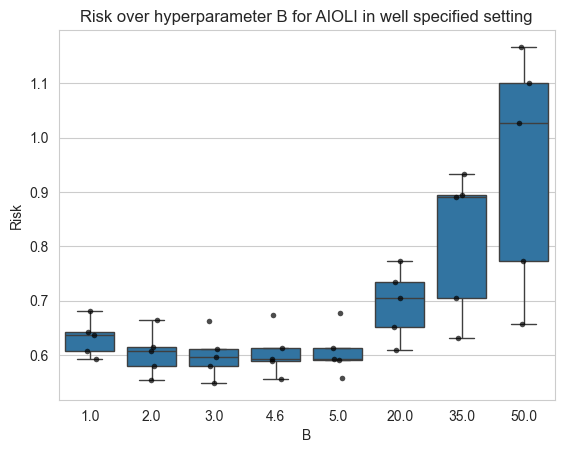

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49.


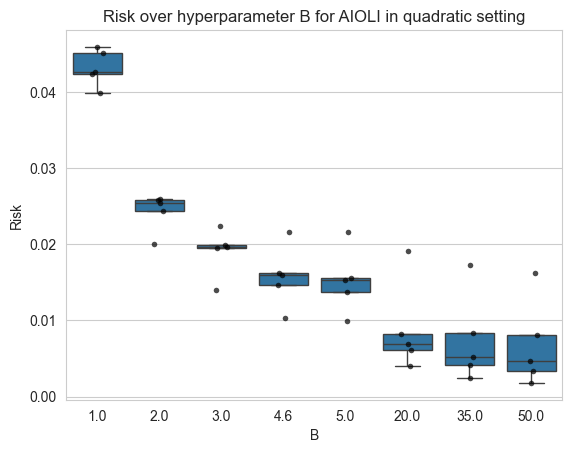

100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.


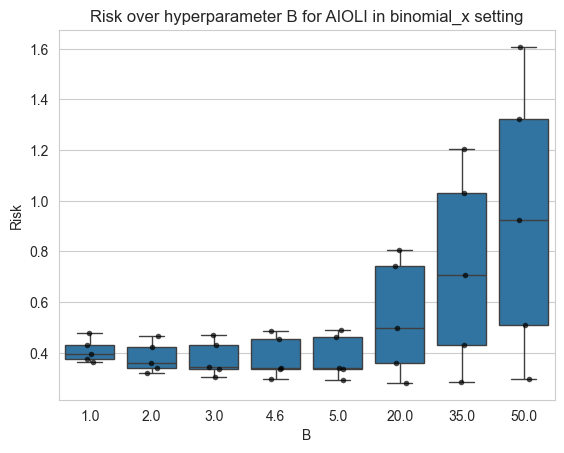

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.


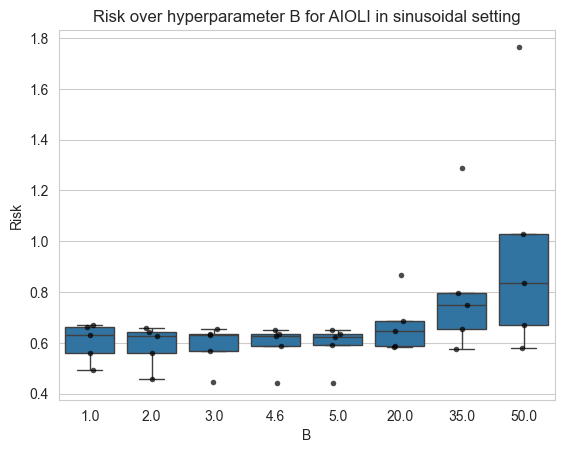

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.62
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.635
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.555
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.59


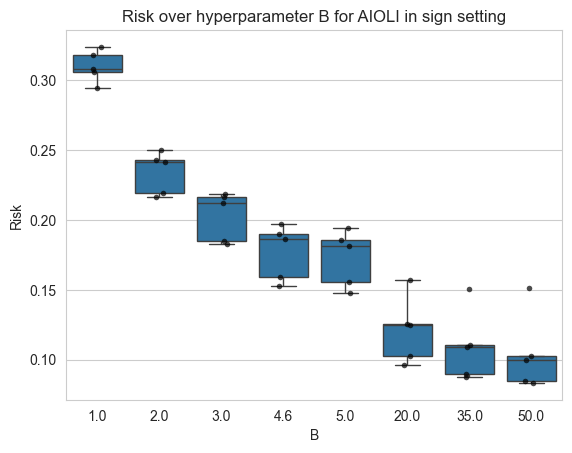

100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.522.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.534.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.492.


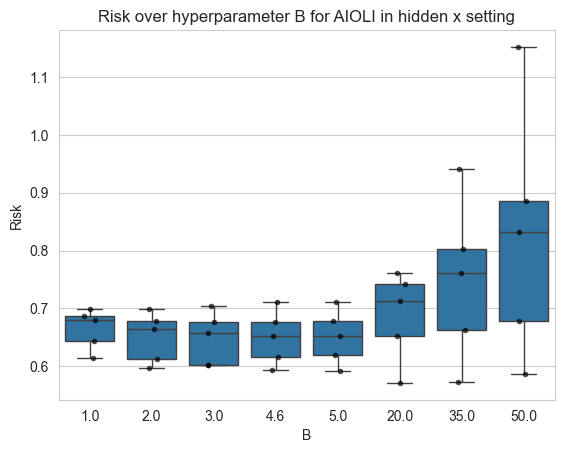

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.405
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53


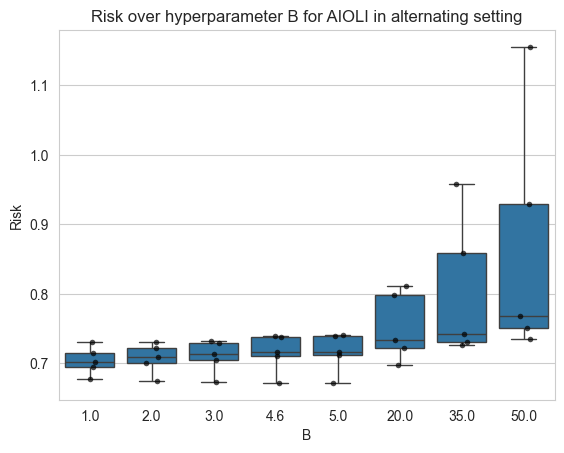

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


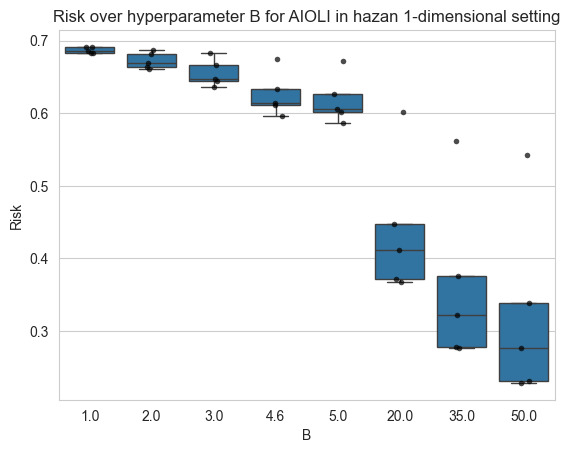

In [352]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, n_runs=5)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.99.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.


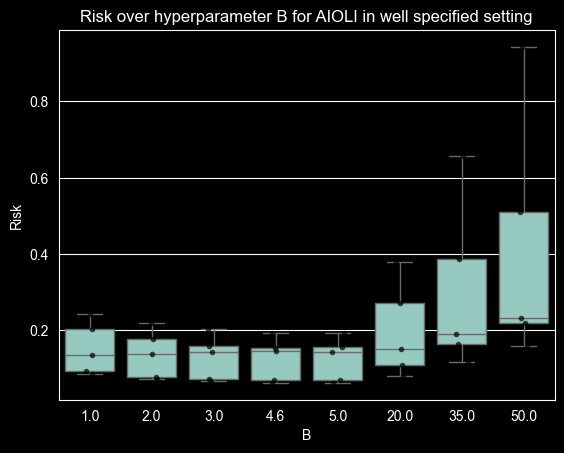

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.935.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.939.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.963.


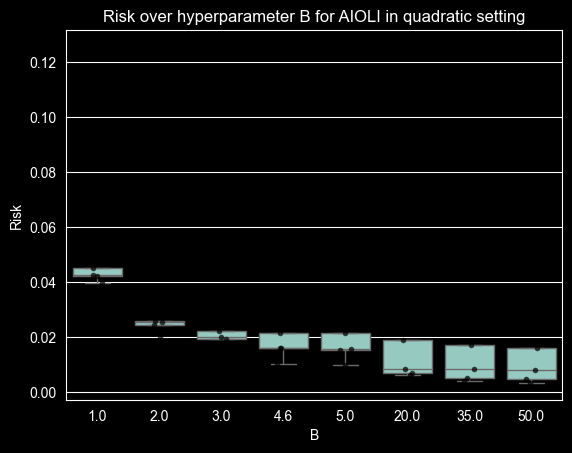

100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.1.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.09.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.096.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.103.


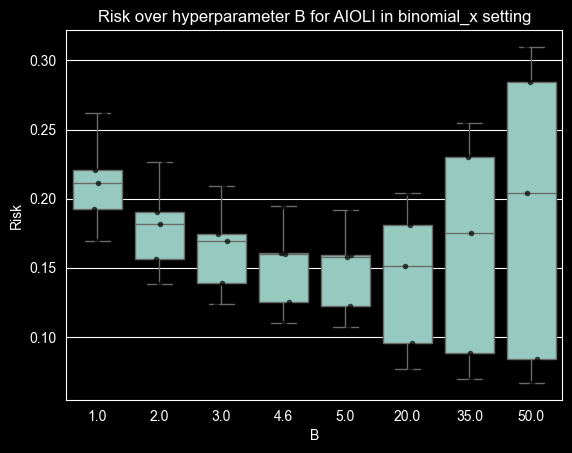

Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.


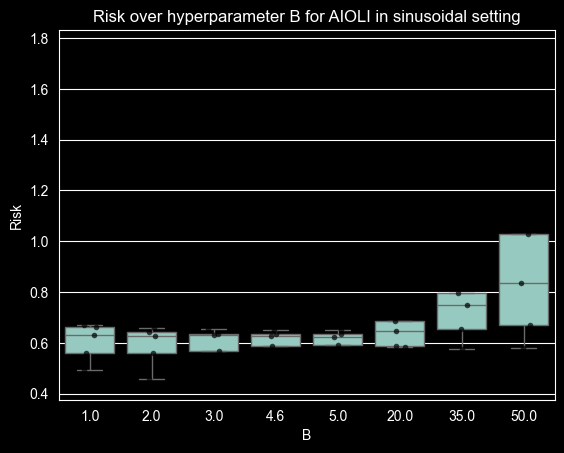

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.08
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04


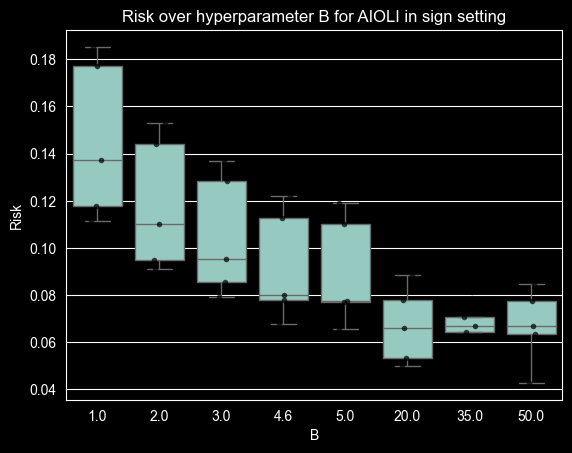

100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.


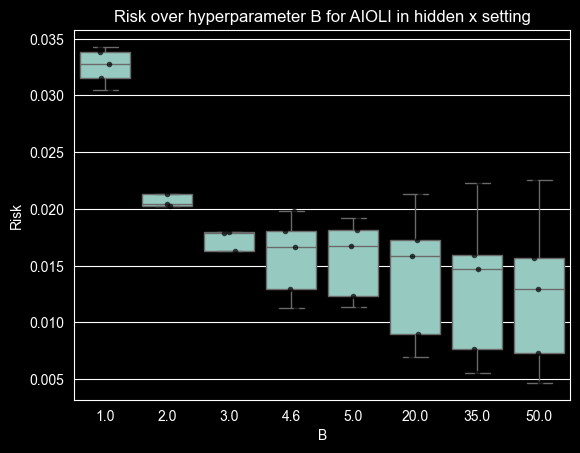

100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.005
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.01
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


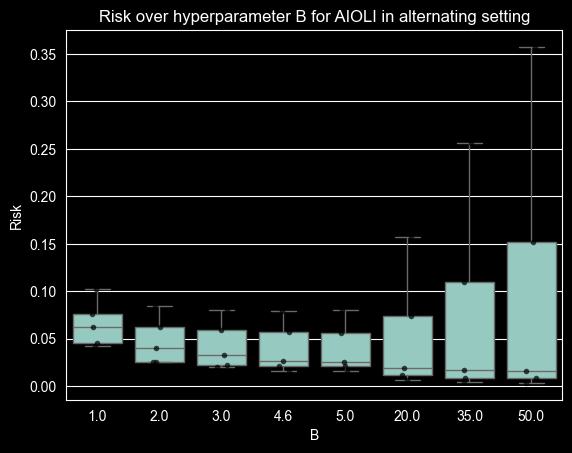

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665


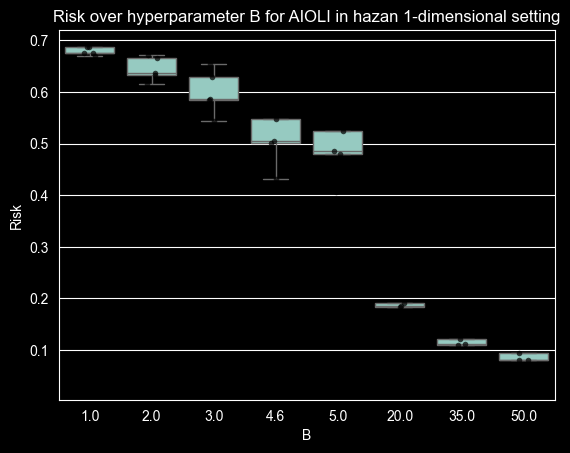

In [353]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, balanced = False, X_hazan = -1, n_runs=5)

### AIOLI "X"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.519.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.


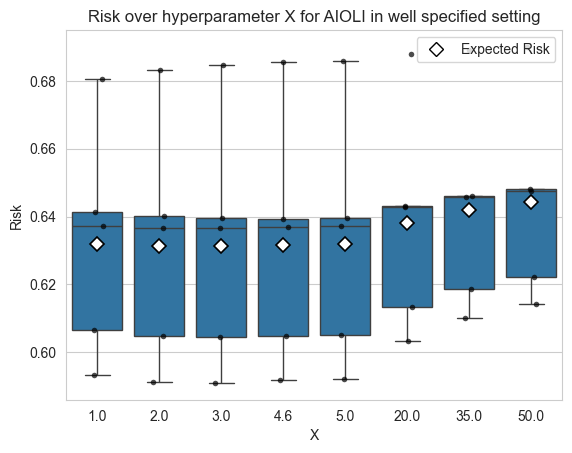

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49.


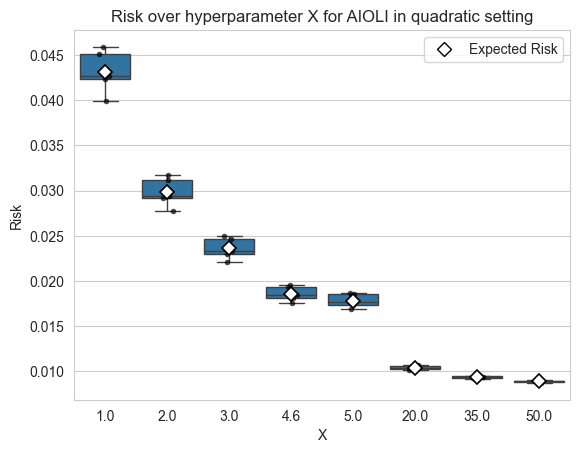

100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.


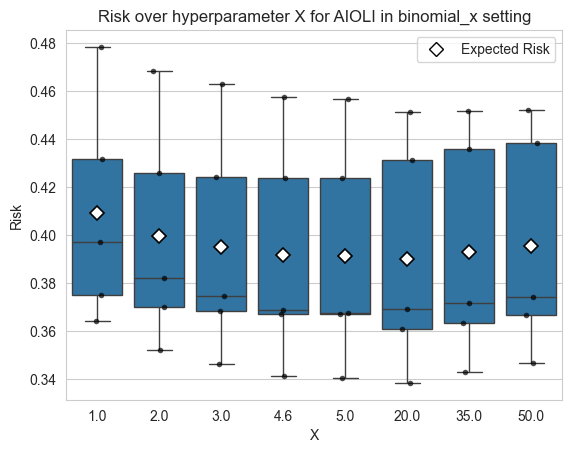

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.


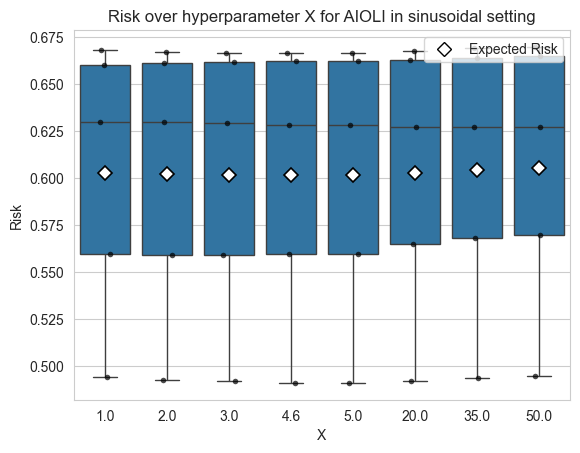

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.62
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.635
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.555
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.59


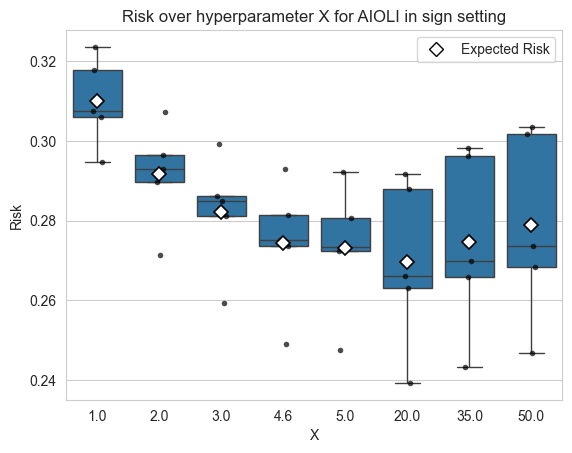

100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.522.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.534.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.492.


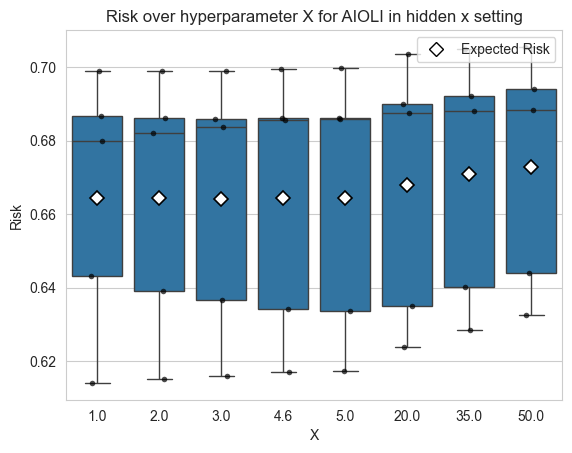

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.405
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53


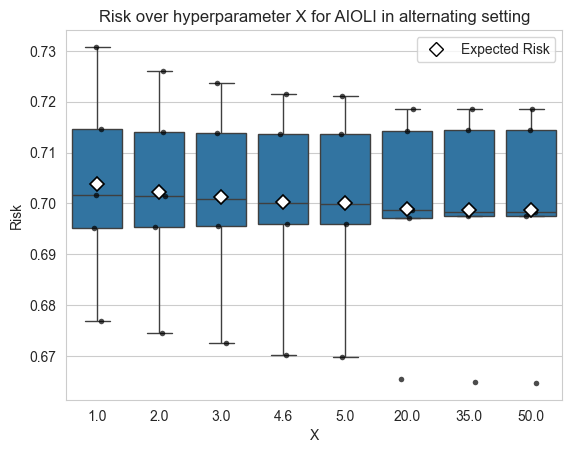

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


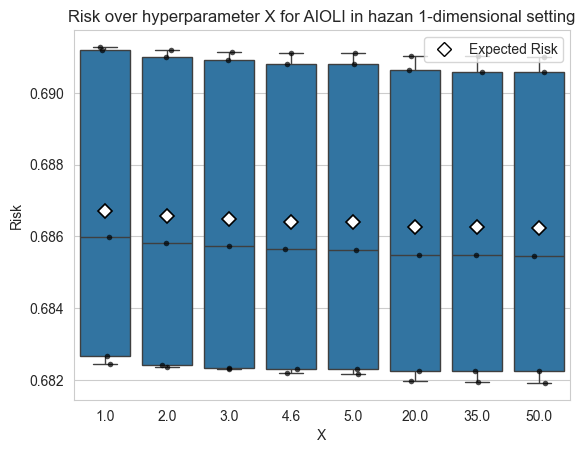

In [396]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100,n_runs = 5)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.99.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.


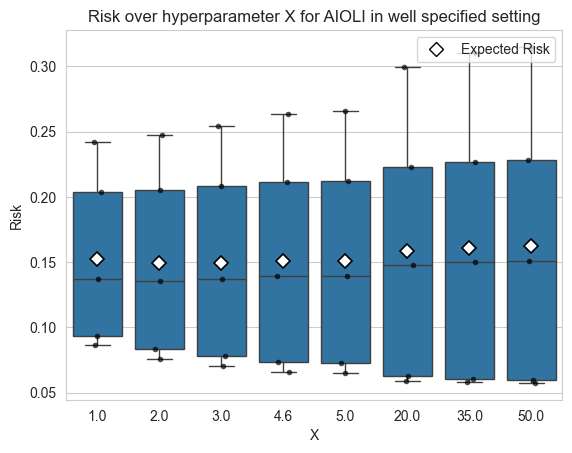

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.935.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.939.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.963.


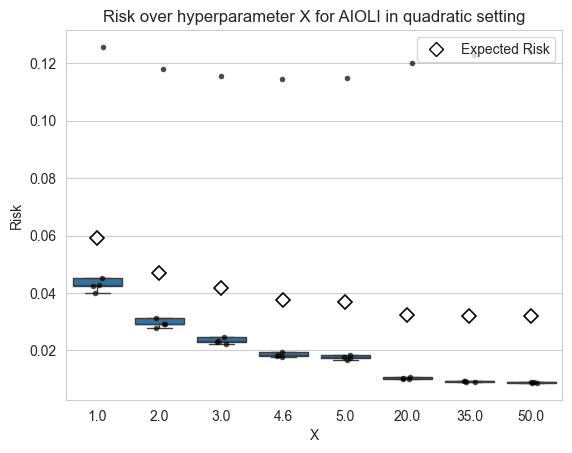

100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.1.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.09.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.096.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.103.


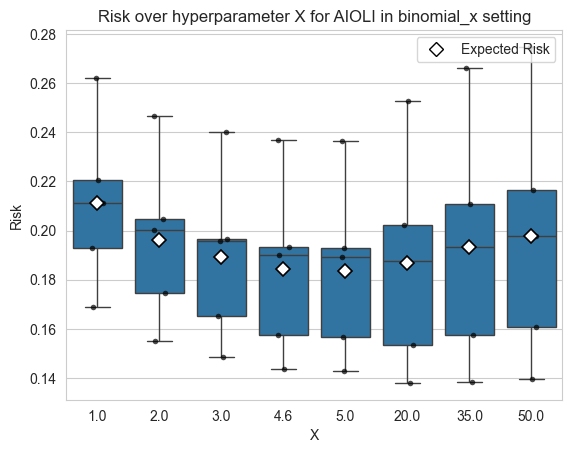

Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.


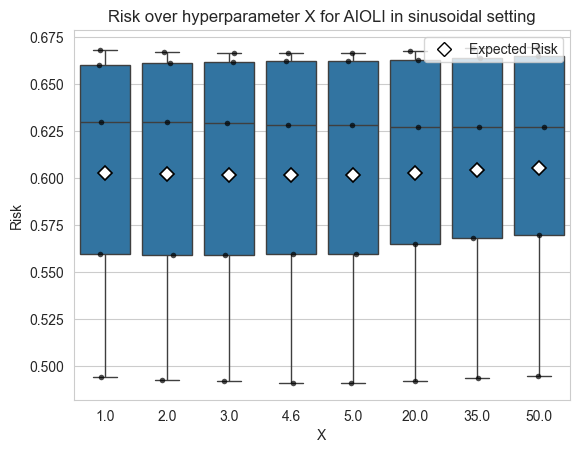

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.08
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04


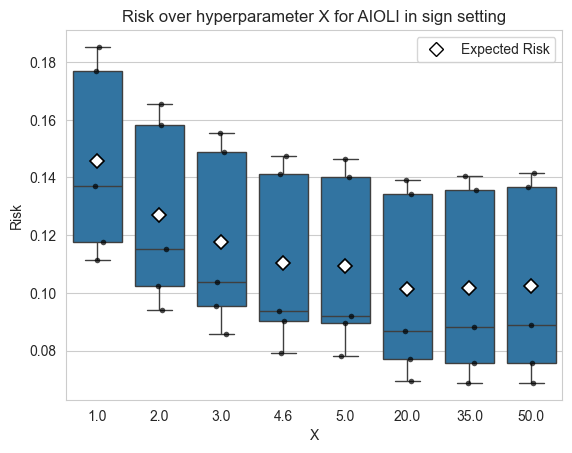

100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.


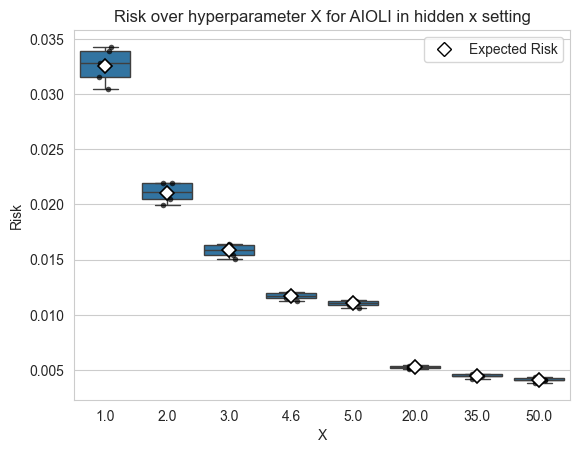

100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.005
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.01
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


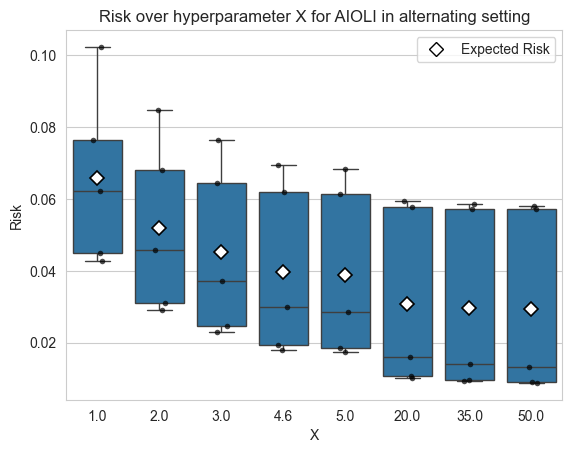

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665


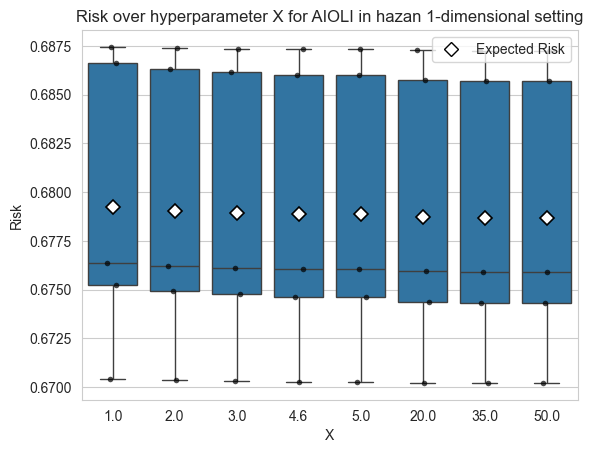

In [397]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, balanced = False, X_hazan = -1, n_runs = 5)

### Ada Grad "B"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.519.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.481.
100 (training) samples were generated in the well specified balanced setting

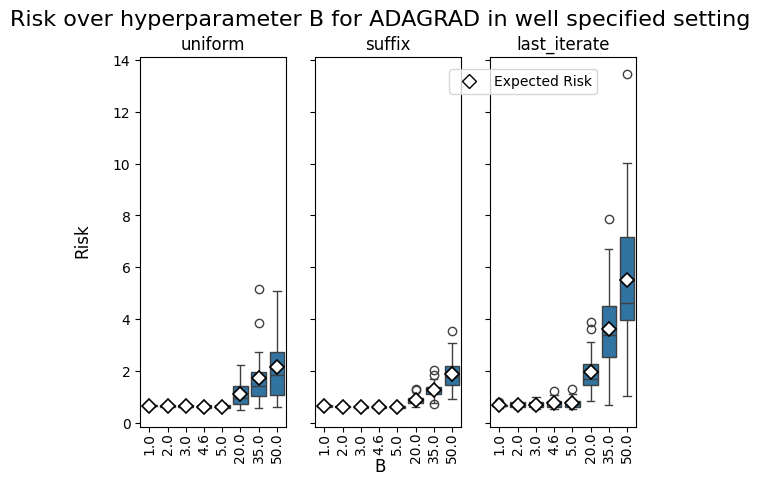

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(

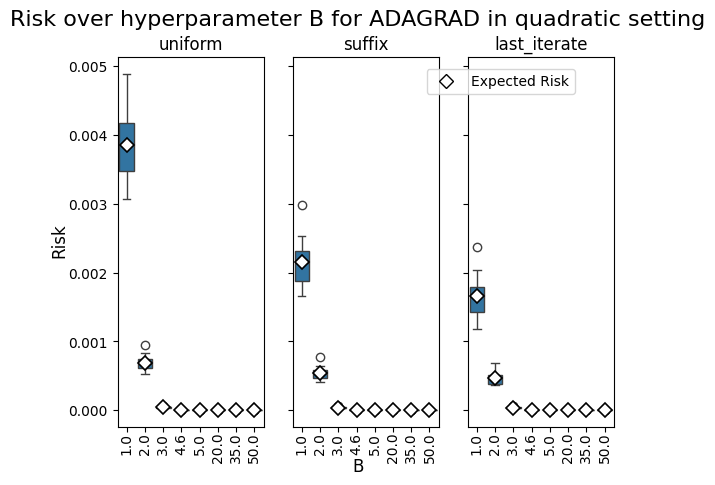

100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.492.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an av

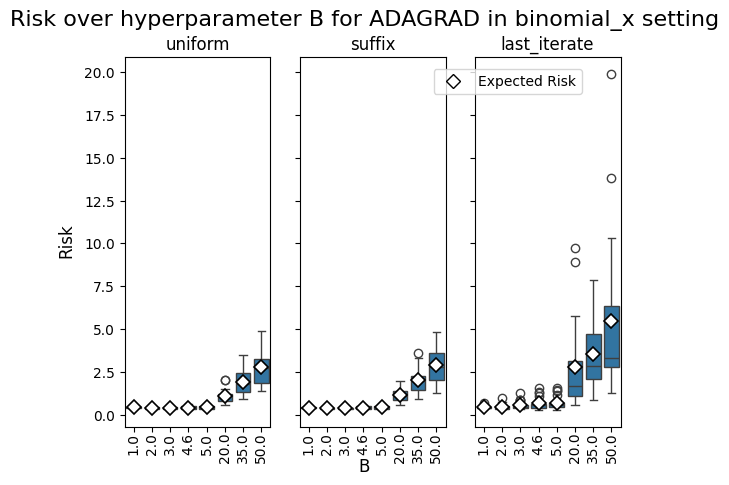

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an av

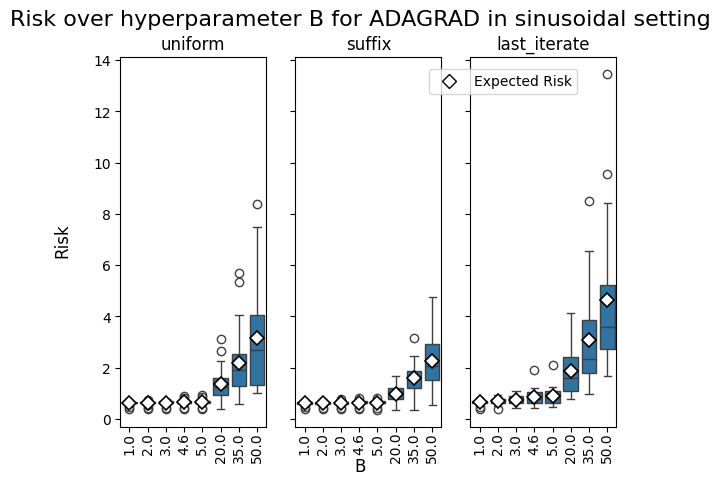

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.62
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.635
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.555
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.59
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.56
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.535
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.52
100 (training) samples were generated

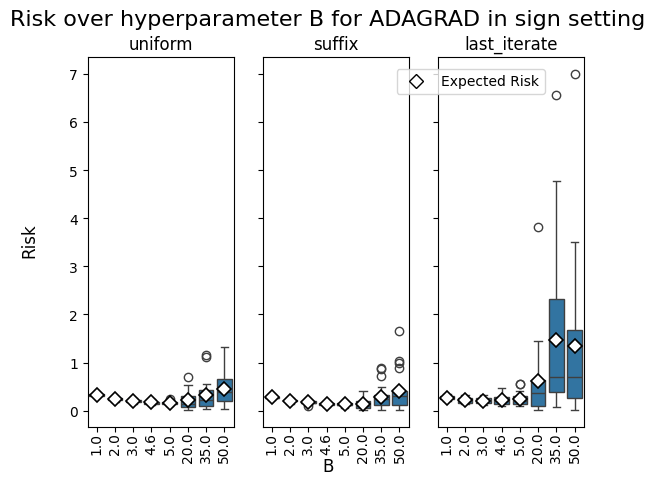

100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.522.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.534.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.492.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.515.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.475.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P

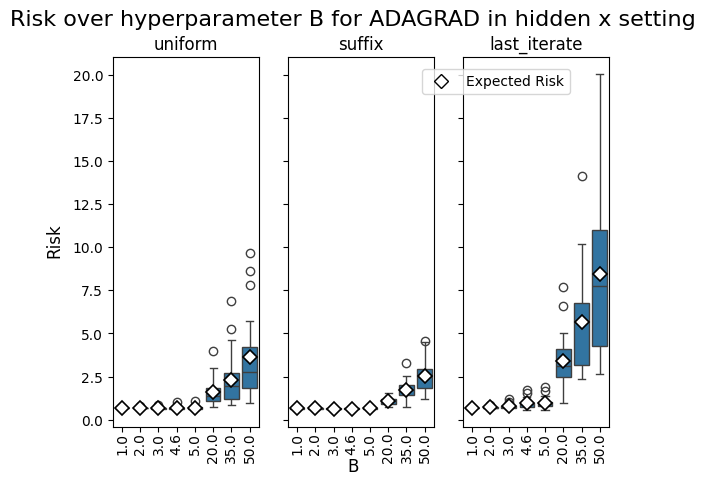

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.405
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.48
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an av

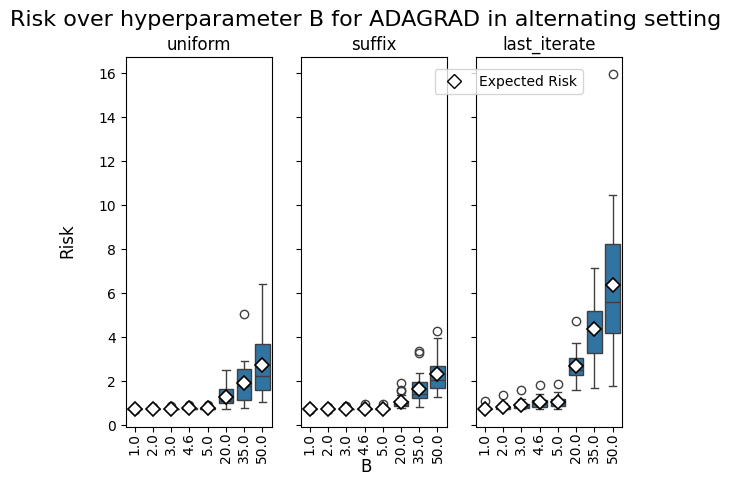

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimen

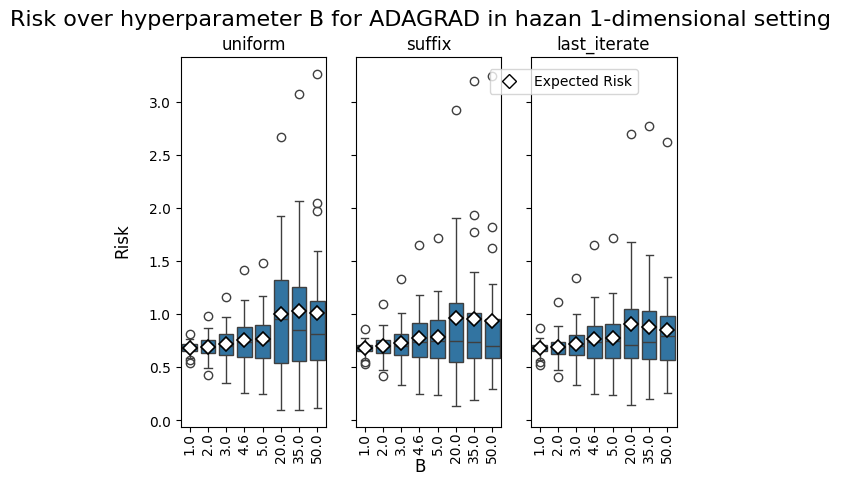

In [383]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.99.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.991.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.99.
100 (training) samples were generated in the well specified unba

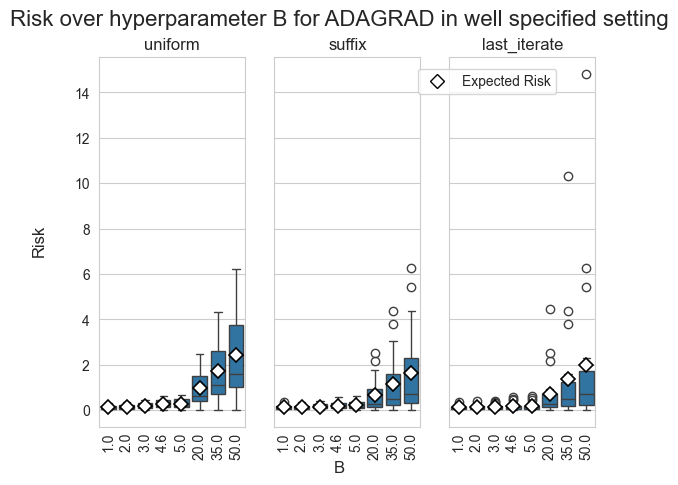

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.935.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.939.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.963.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.967.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), w

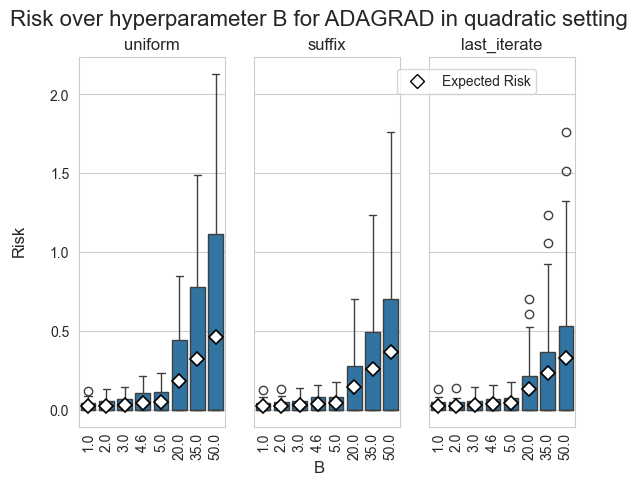

100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.1.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.09.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.096.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.103.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.106.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(

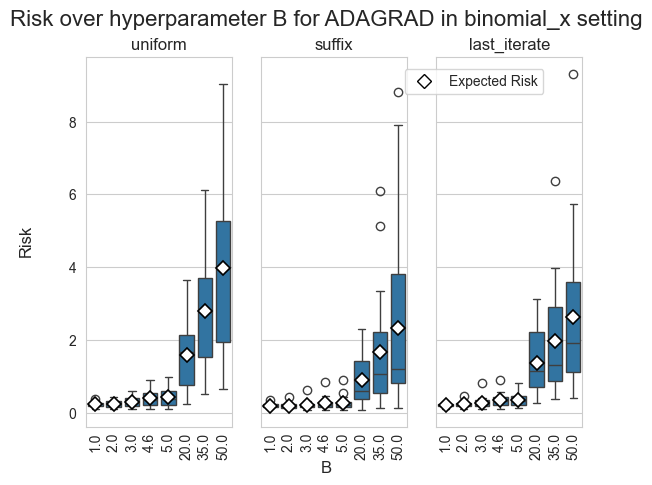

Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinuso

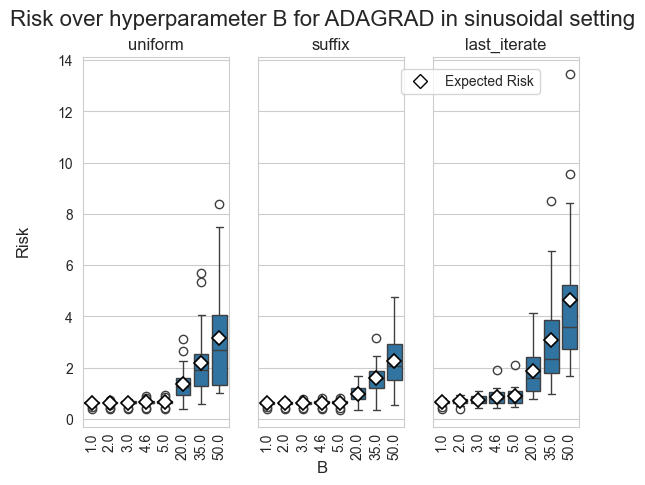

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.08
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04
100 (training) samp

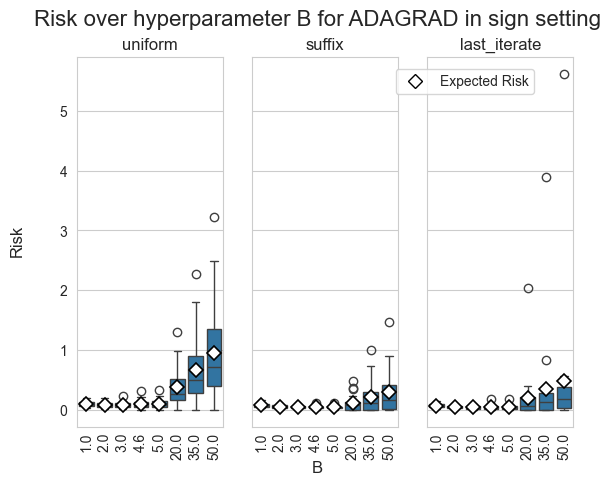

100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average

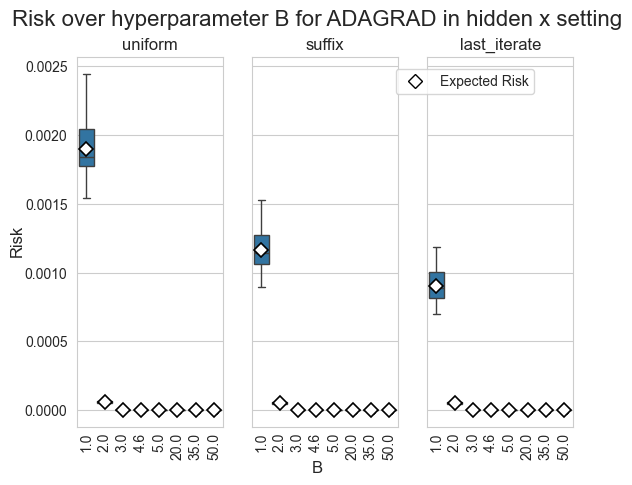

100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.005
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.01
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.005
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s

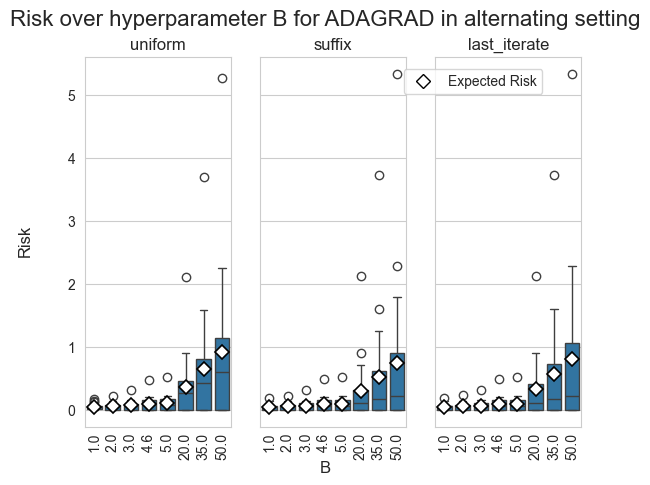

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al

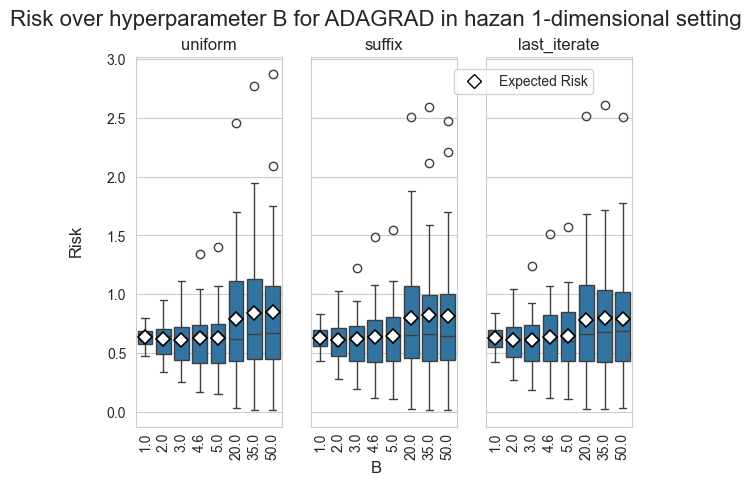

In [387]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100, balanced = False, X_hazan = -1)

### SMOTE "S"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467.
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.519.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.481.
100 (training) s

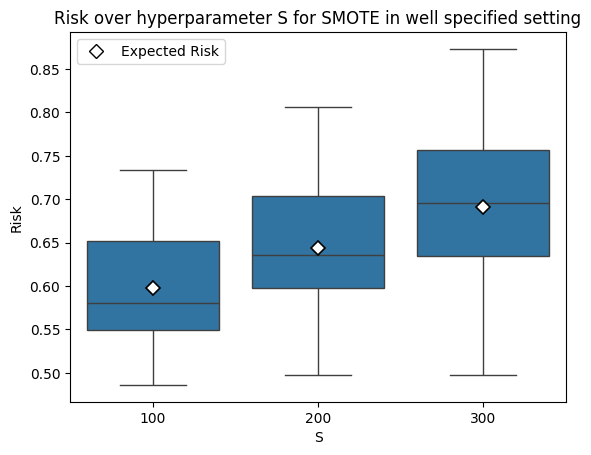

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in th

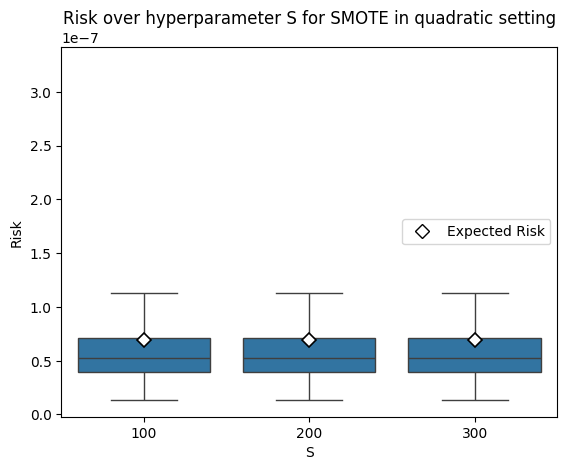

100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.492.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an av

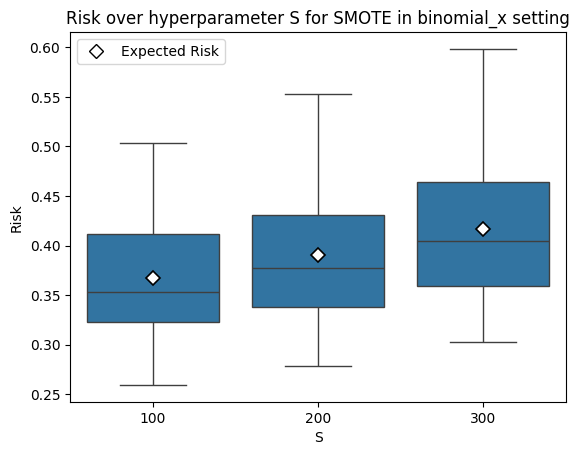

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an av

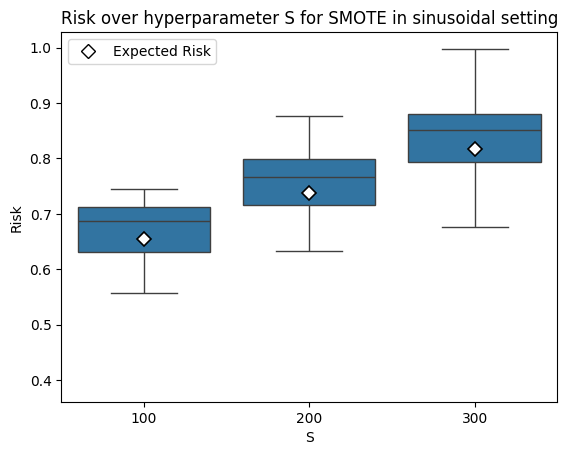

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.62
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.635
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.555
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.59
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.56
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.535
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an 

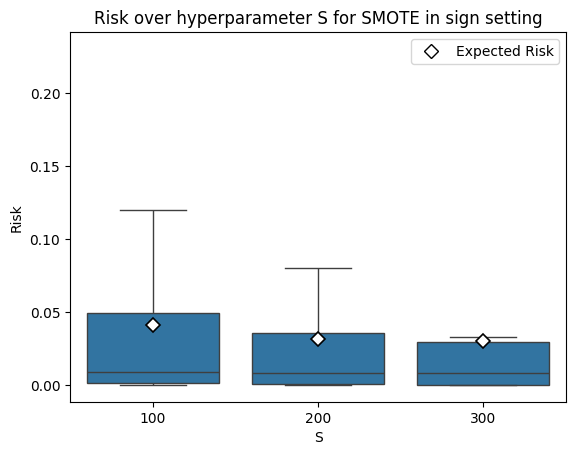

100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.522.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.534.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.492.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.515.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.475.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P

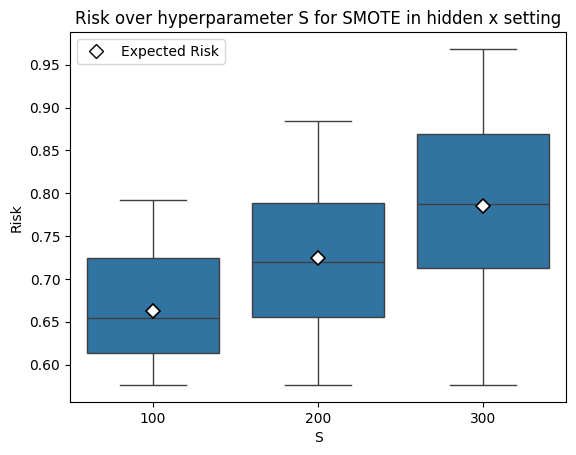

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.405
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.48
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an av

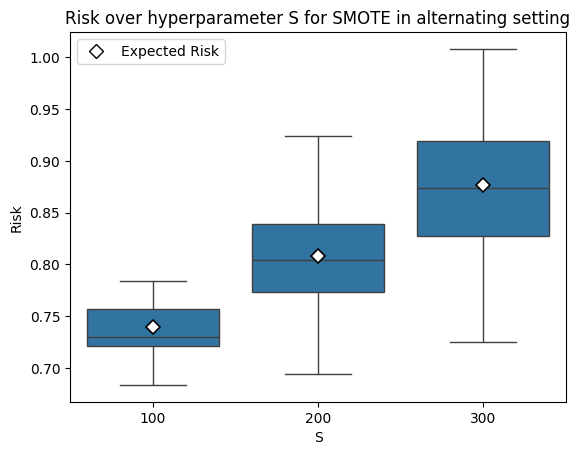

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimen

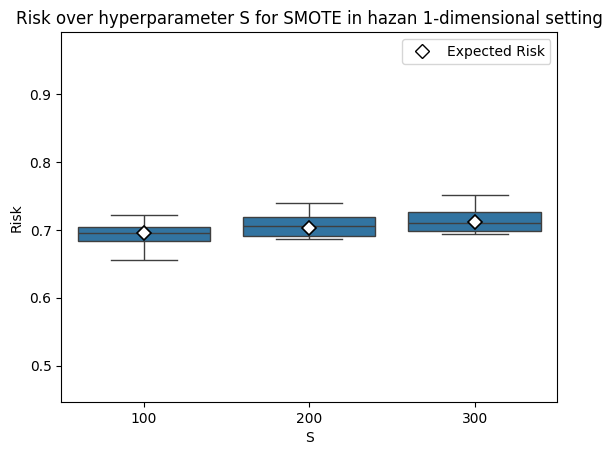

In [364]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.99.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.991.
Datas

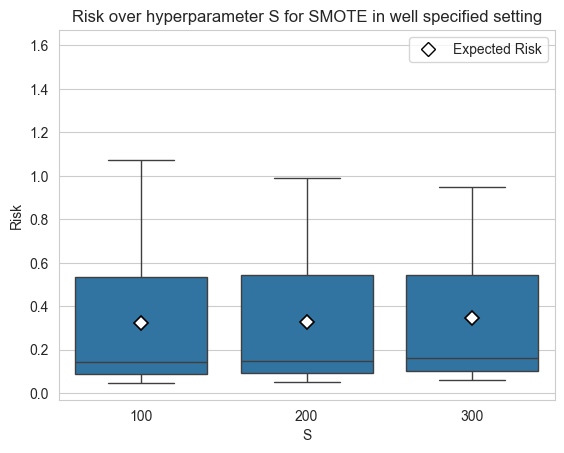

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.935.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.939.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic 

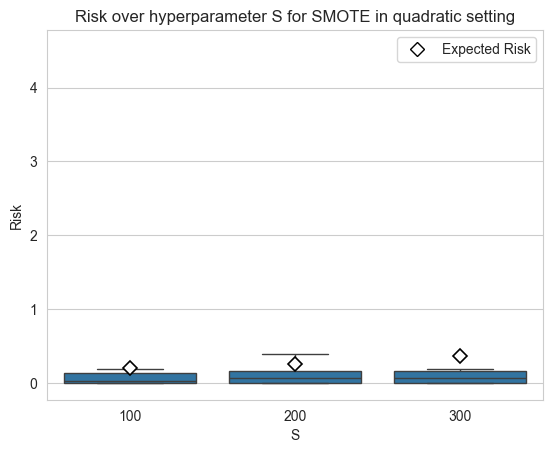

100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.1.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.09.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.096.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.103.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.106.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(

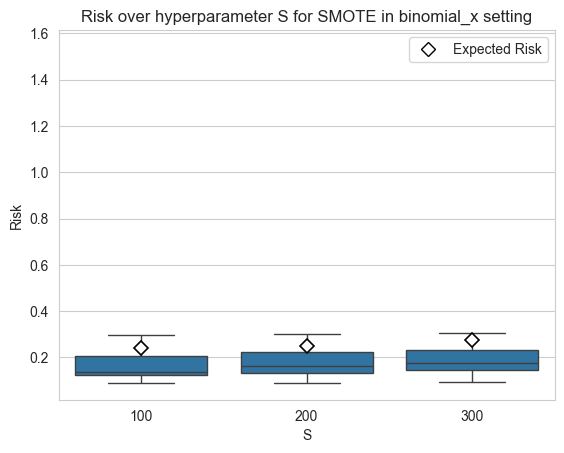

Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinuso

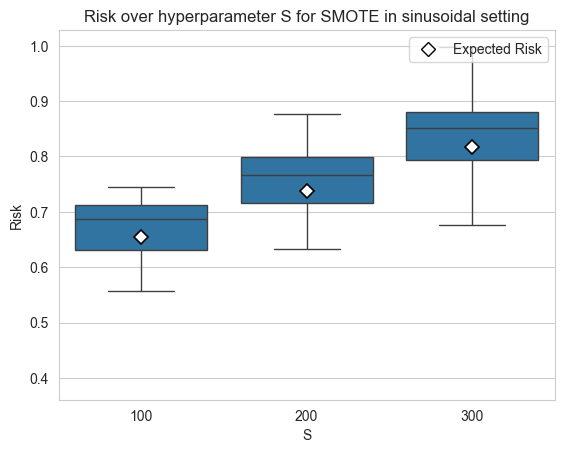

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.08
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04
100 (training) samp

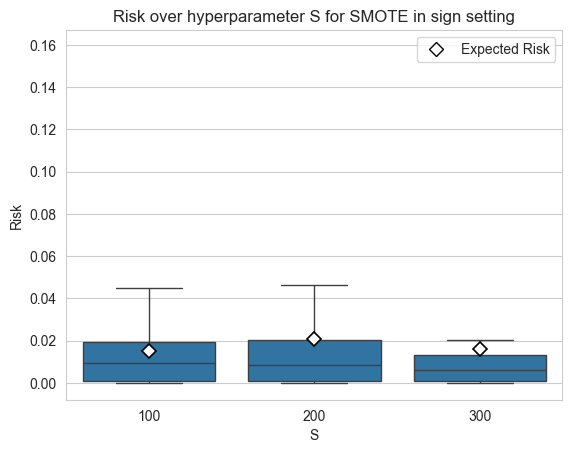

100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in th

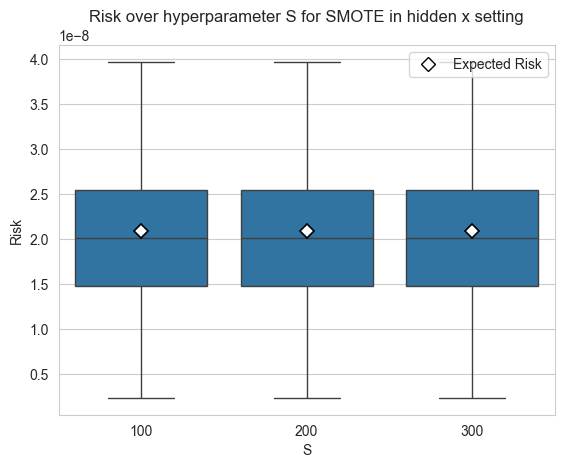

100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.005
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.01
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic

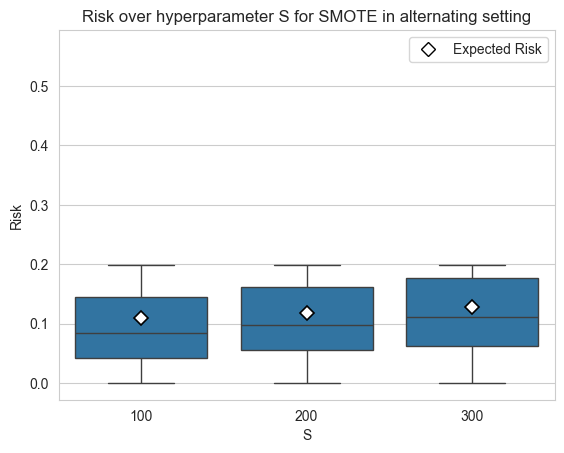

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al

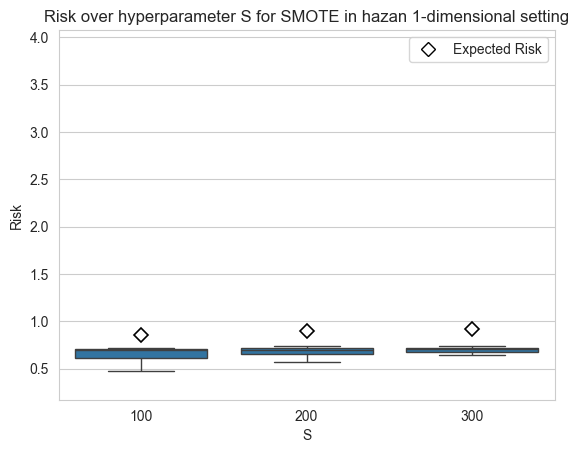

In [386]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, balanced = False, X_hazan = -1)

### SMOTE "k"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467.
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.519.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494.
100 (training) samples were 

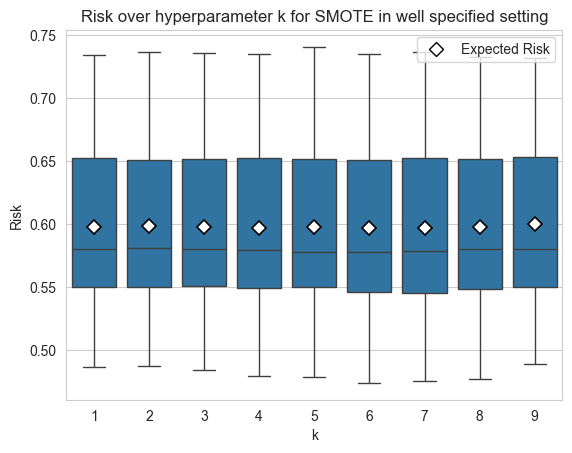

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regres

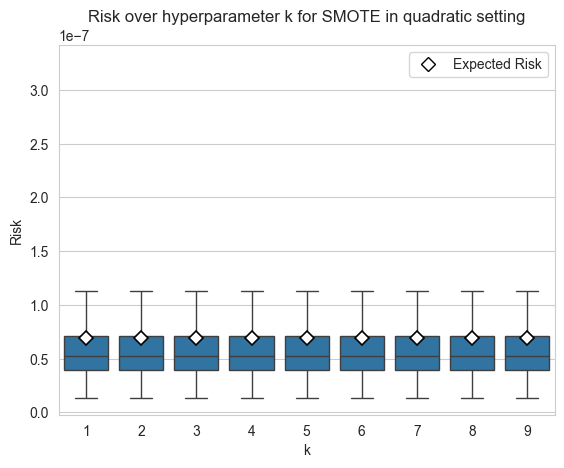

100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.492.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an av

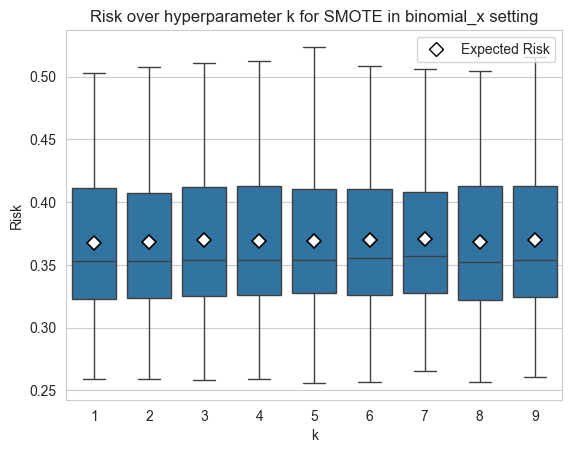

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an av

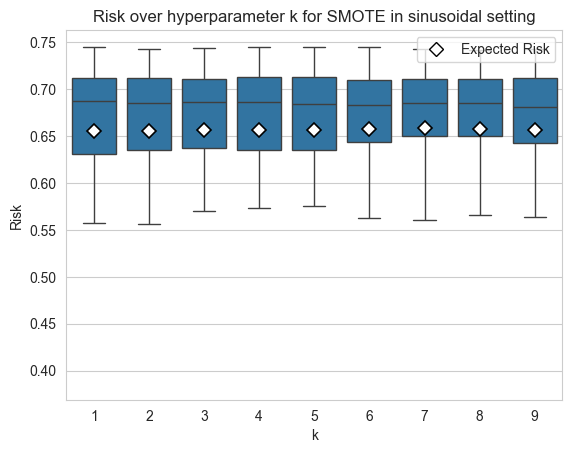

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.62
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.635
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.555
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.59
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.56
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an a

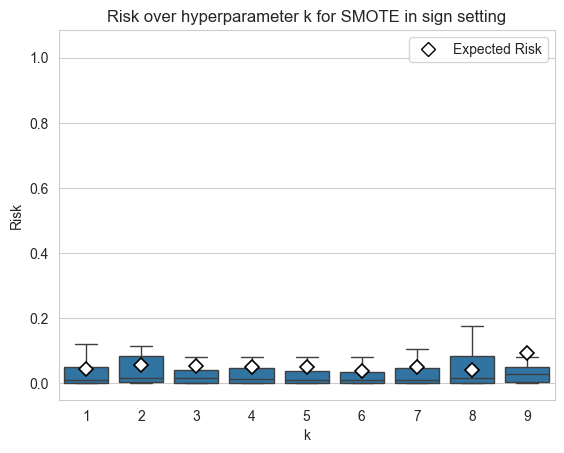

100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.522.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.534.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.492.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.515.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.475.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P

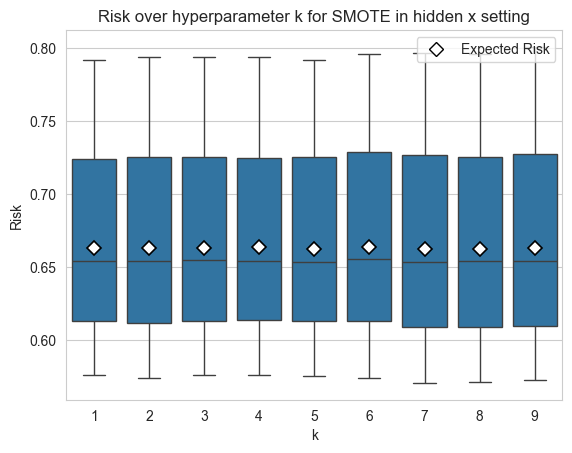

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.405
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.48
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an av

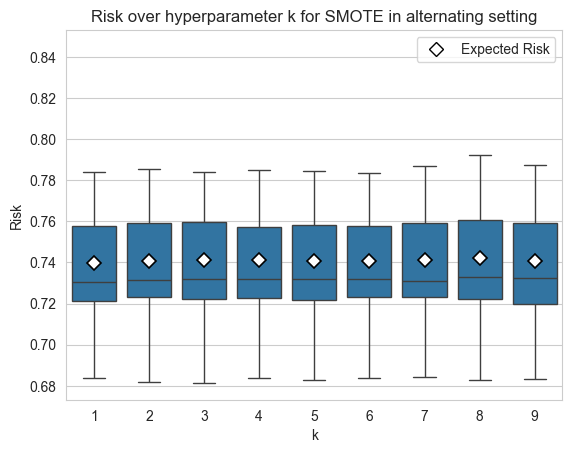

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by

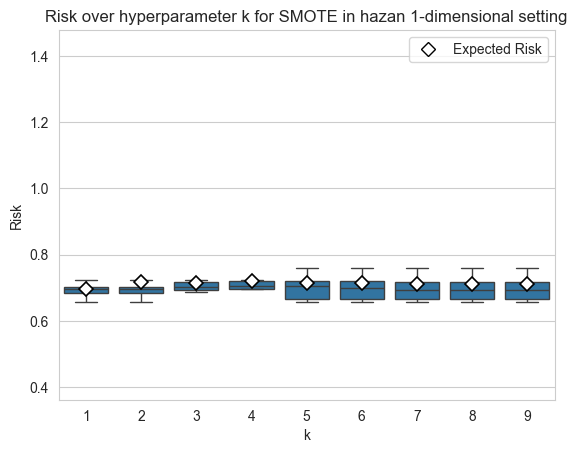

In [389]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the num

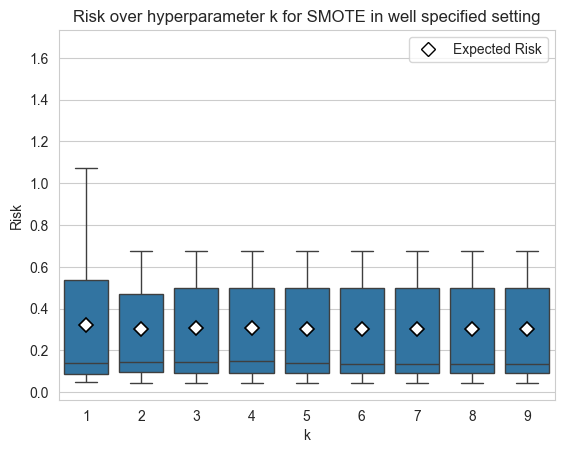

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.935.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic re

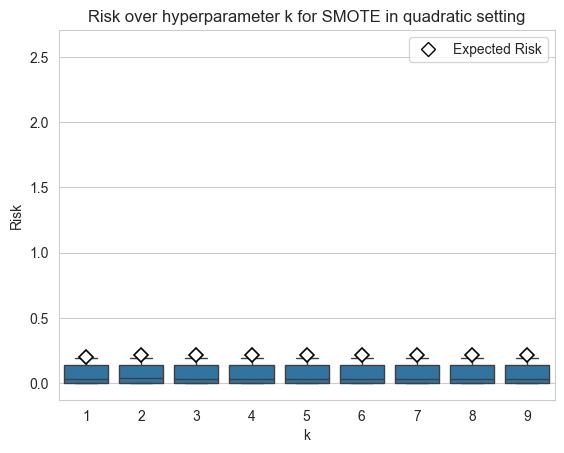

100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.1.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.09.
k must be smaller than the number of training samples
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.096.
k must be smaller than the number of training samples
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
k must be smaller than the number of training samples
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.103.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.106.
100 (training) samples were generated in the binomial_x unbal

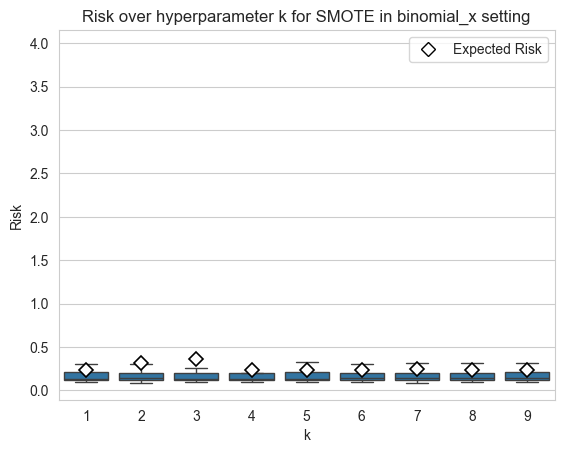

Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinuso

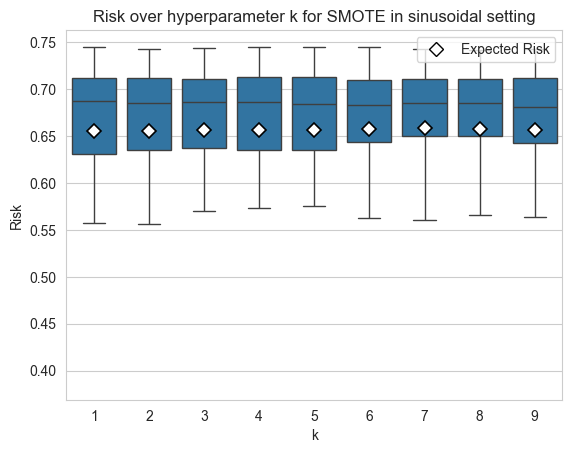

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
k must be smaller than the number of training samples
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated

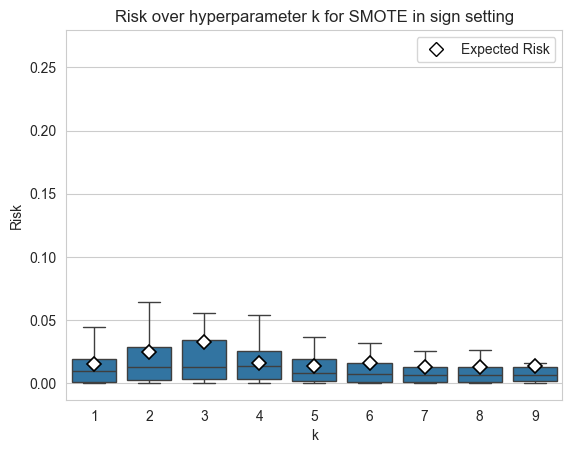

100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regres

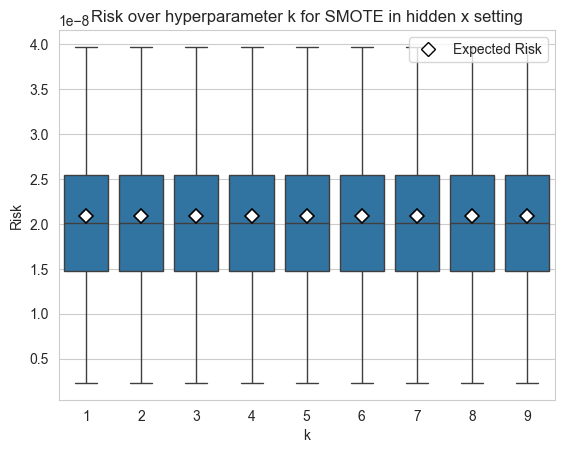

100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regressi

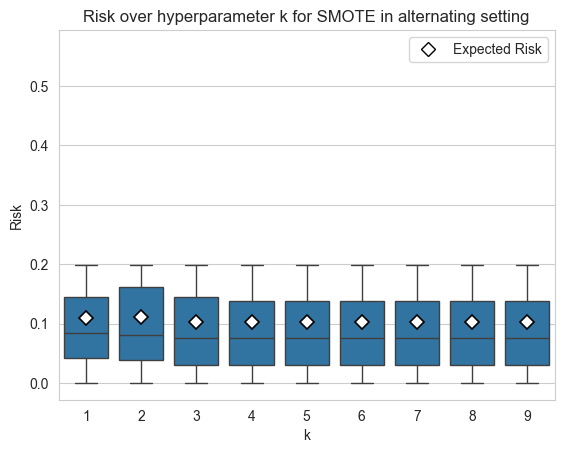

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samp

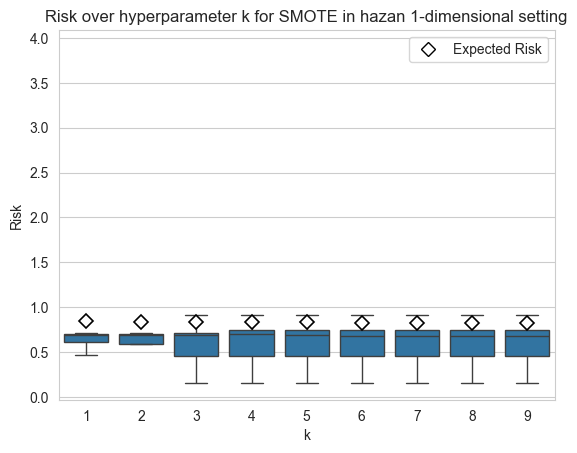

In [388]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, balanced = False, X_hazan = -1)

### Ridge LR "lambda"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.519.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.481.
100 (training) samples were generated in the well specified balanced setting

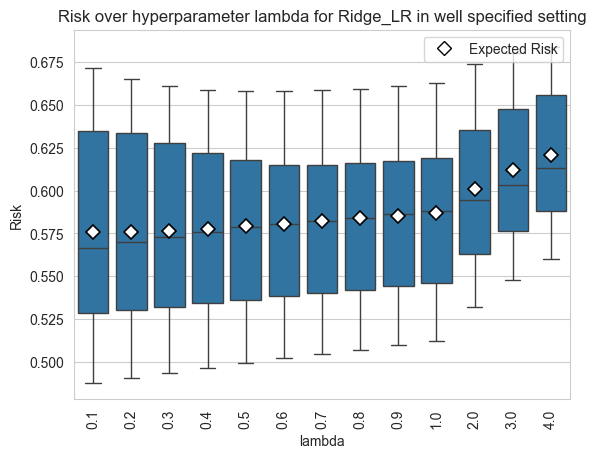

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489.
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
100 (training) samples were generated in the quadratic balanced settin

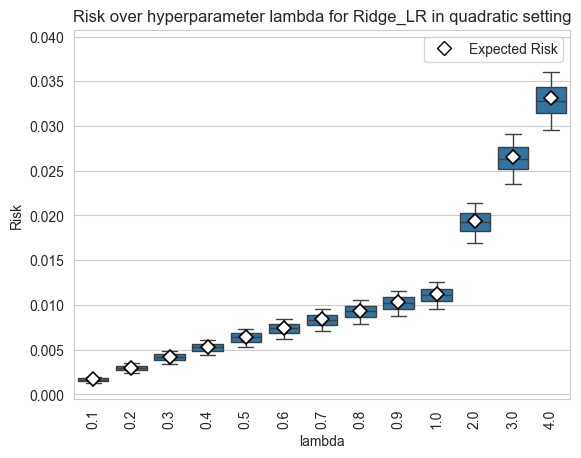

100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.492.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an av

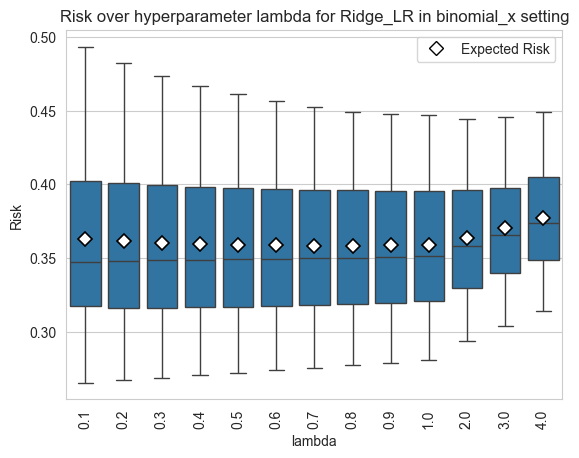

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an av

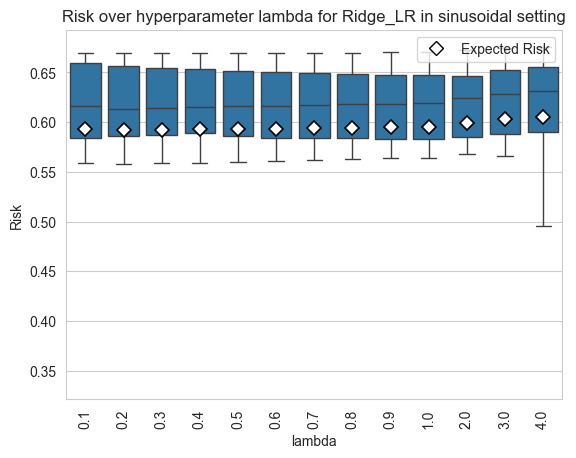

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.62
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.635
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.555
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.59
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.56
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.535
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.52
100 (training) samples were generated

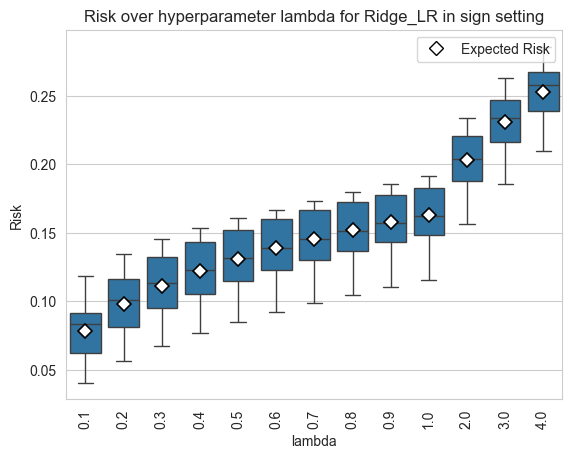

100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.522.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.534.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.492.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.515.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.475.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P

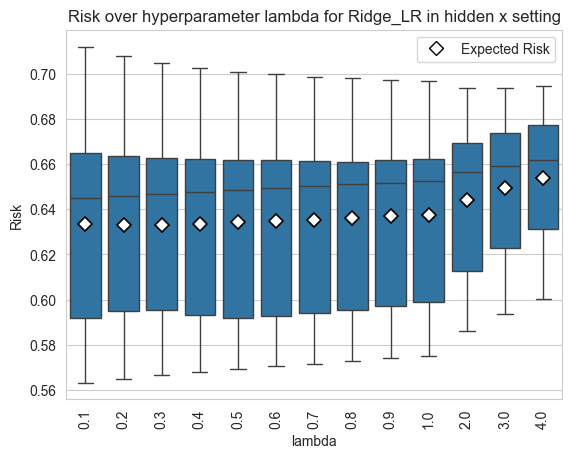

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.405
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.48
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an av

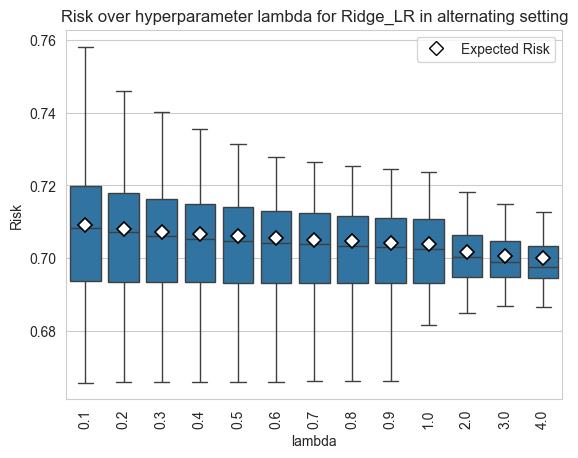

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimen

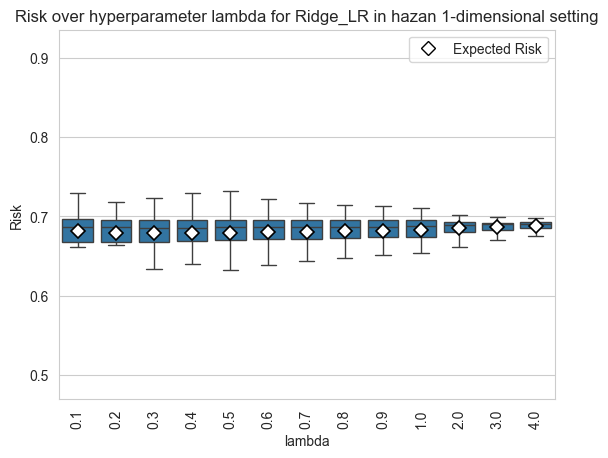

In [394]:
for setting in settings:
    hyperparameter_analysis(setting, "Ridge_LR", "lambda", n = 100)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.99.
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 

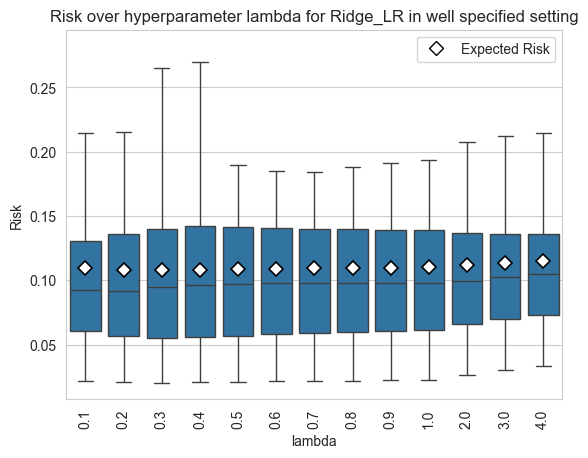

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.935.
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
100 (training) samples were generated in the quadratic unbalanced 

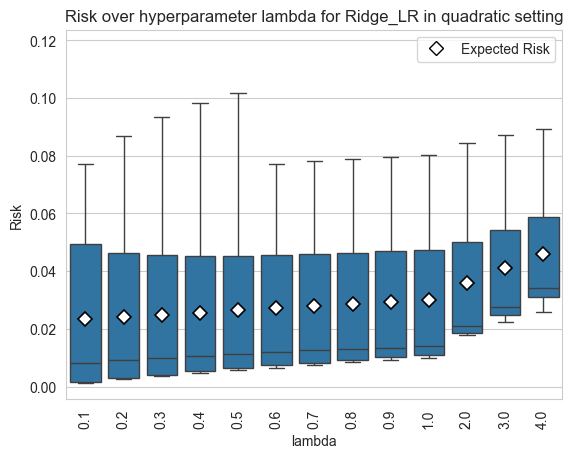

100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.1.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.09.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.096.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.103.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.106.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(

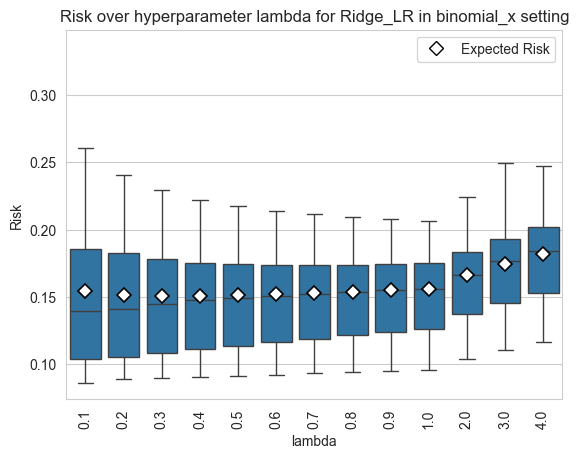

Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinuso

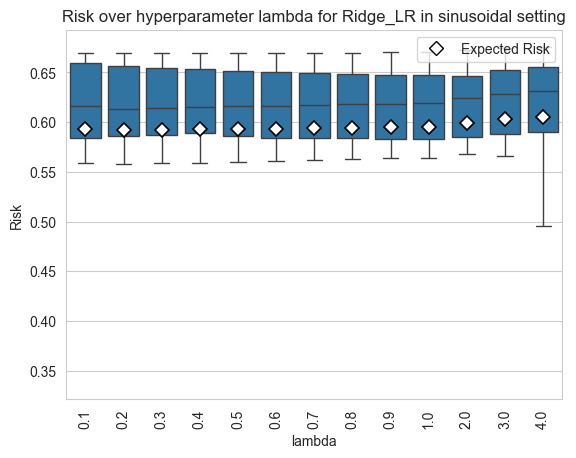

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.08
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04
100 (training) samp

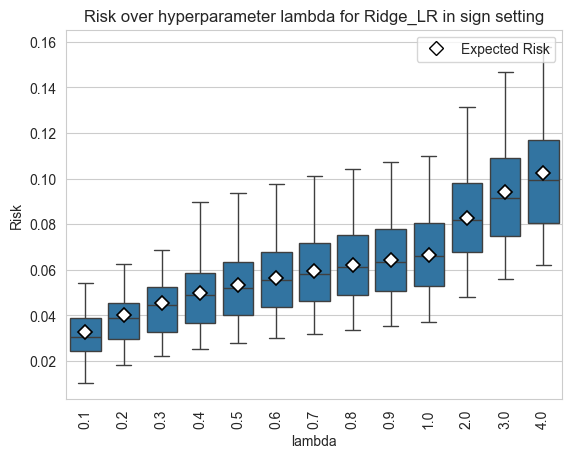

100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
100 (training) samples were generated in the hidden x unbalanced setti

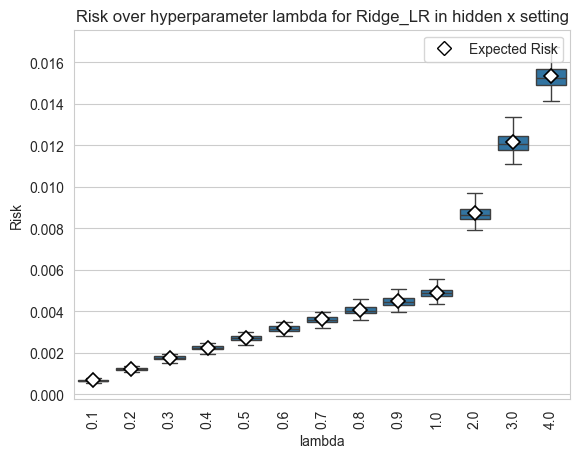

100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
Ridge LR was fit manually
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.005
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.01
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Ridge LR was fit 

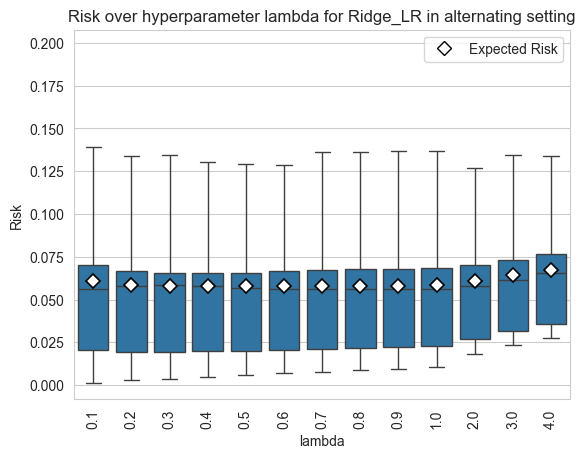

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al

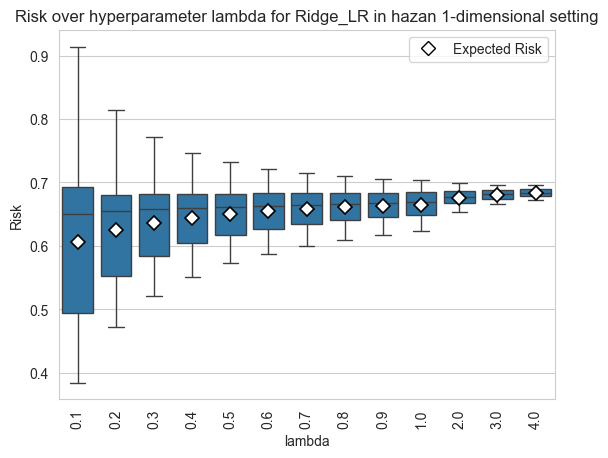

In [395]:
for setting in settings:
    hyperparameter_analysis(setting, "Ridge_LR", "lambda", n = 100, balanced = False, X_hazan = -1)

### Lasso LR "lambda"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the well specified 

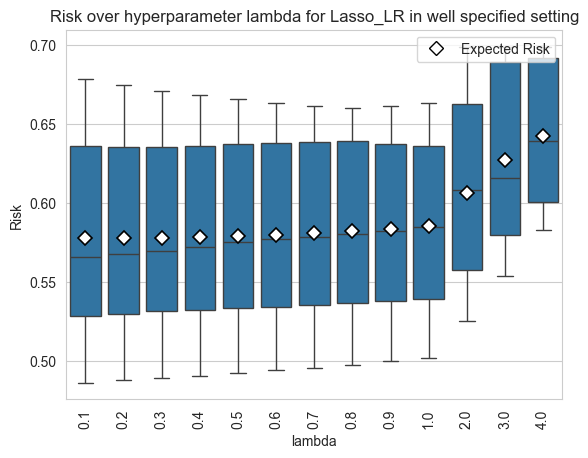

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the quadratic balanced settin

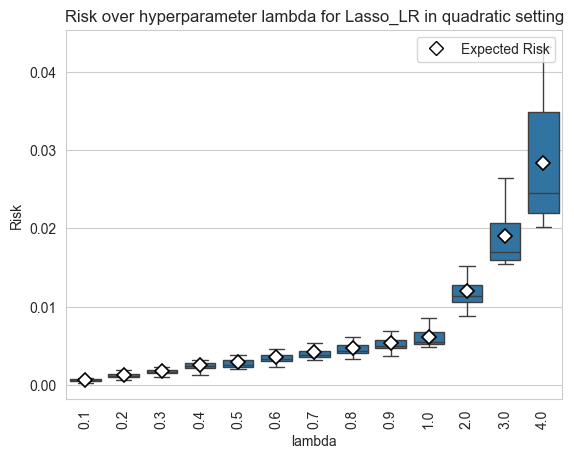

100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the binomial_x balanced set

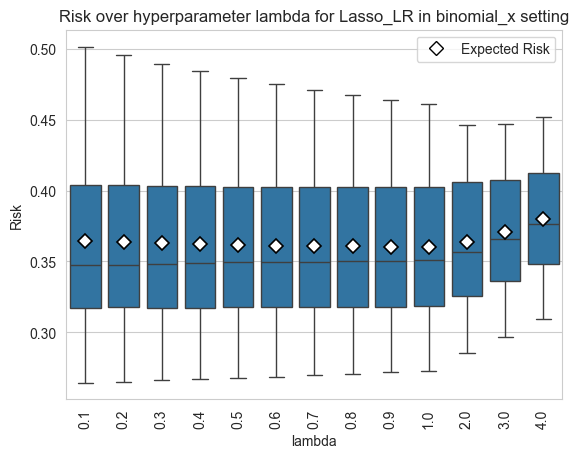

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the sinusoidal balanced set

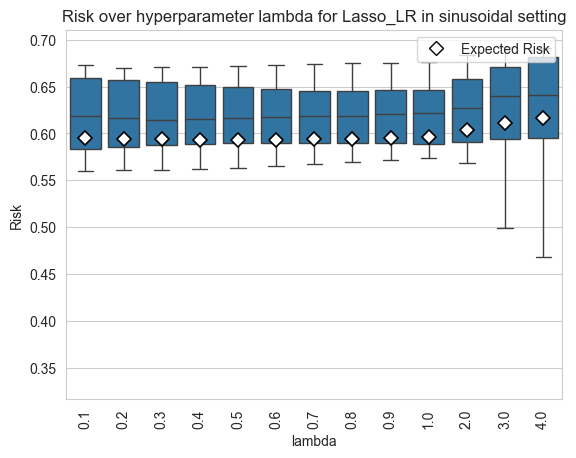

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.62
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the sign balanced setting. Using 3 variable

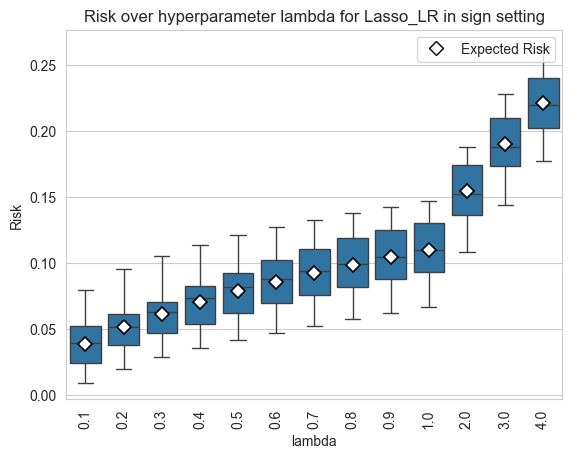

100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.522.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.487.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the hidden x balanced setting

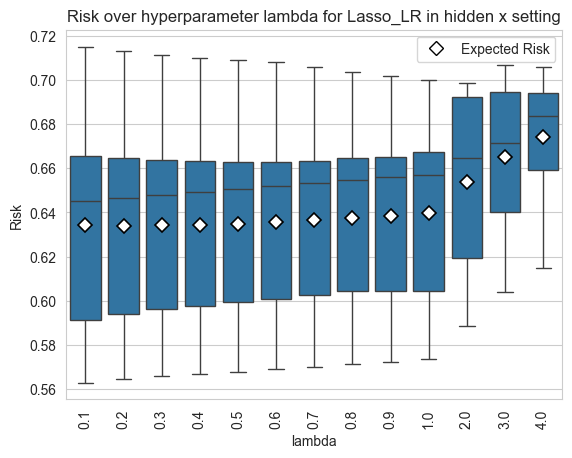

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.405
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the alternating balanced se

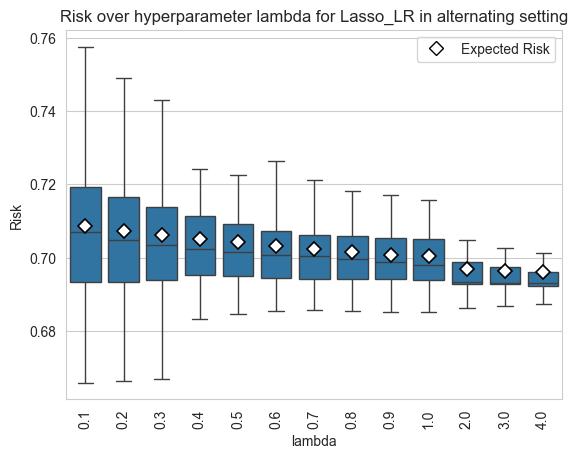

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated using the 1-dime

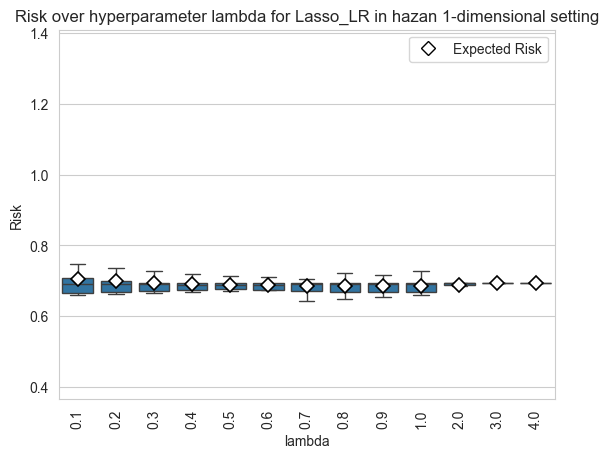

In [392]:
for setting in settings:
    hyperparameter_analysis(setting, "Lasso_LR", "lambda", n = 100)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the well specif

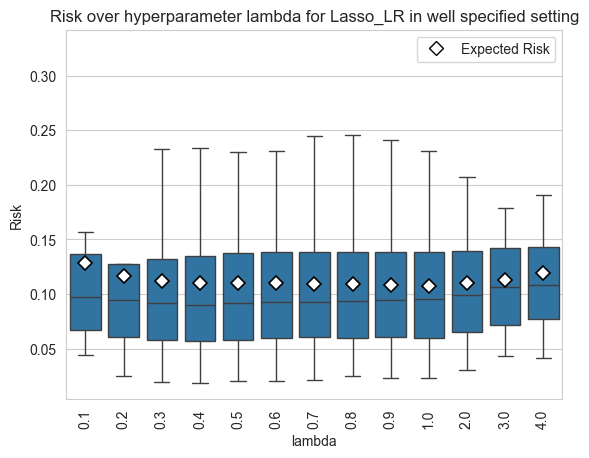

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.935.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the quadratic unbalanced 

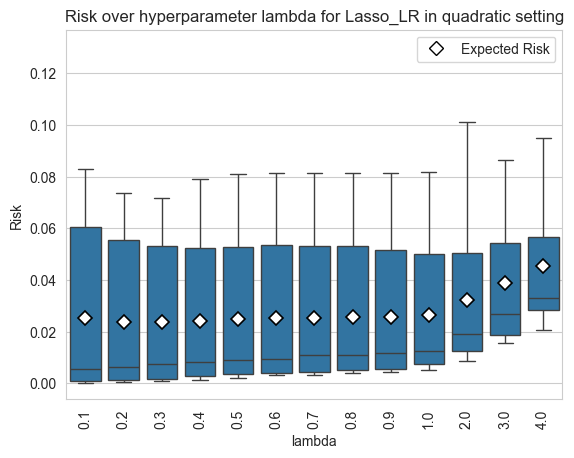

100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.1.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.09.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the binomial_x unbalanced 

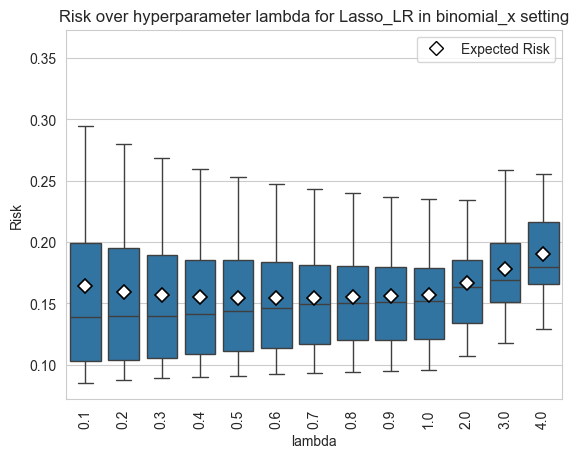

Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit

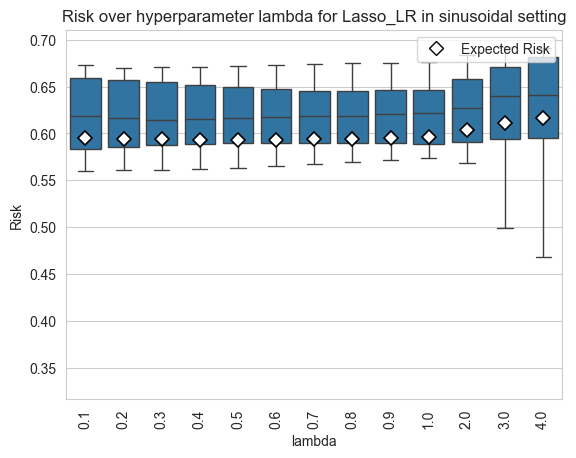

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the sign unbalanced setting. Using 3 

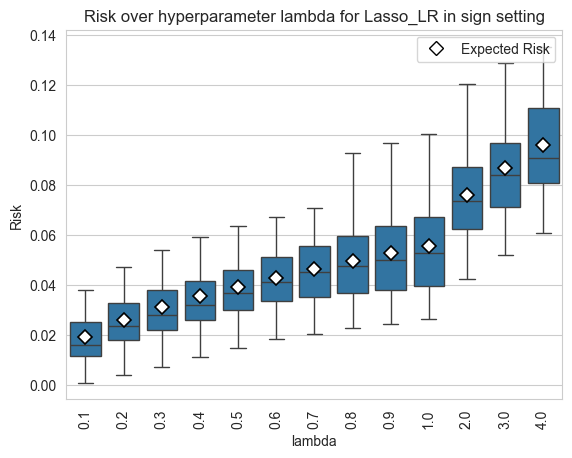

100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the hidden x unbalanced setti

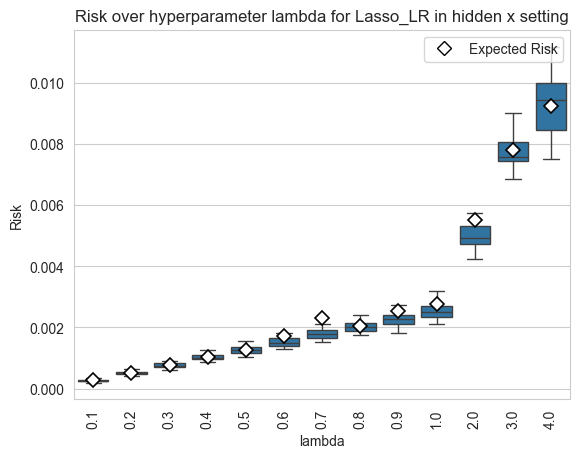

100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated in the alternating unbalance

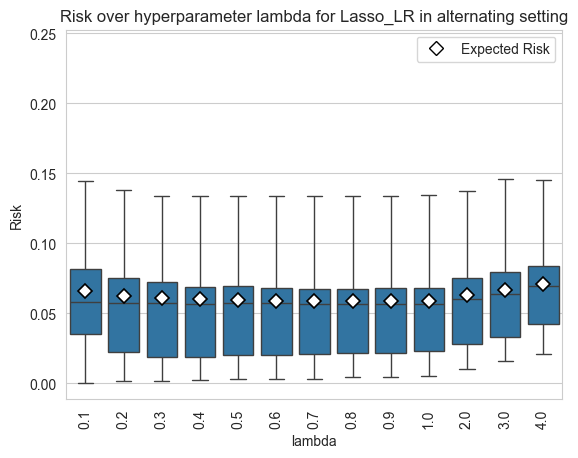

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
Lasso LR was fit manually
100 (training) samples

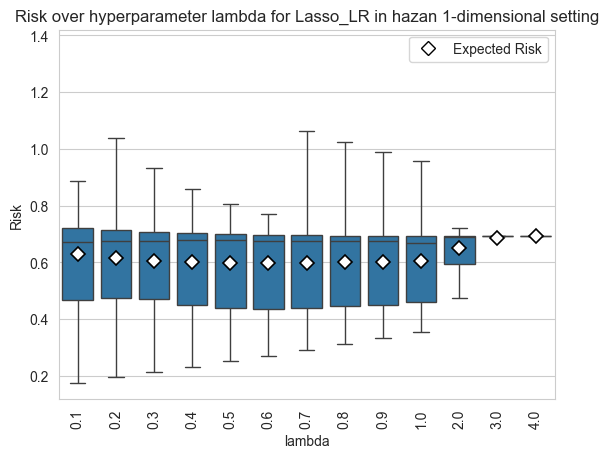

In [393]:
for setting in settings:
    hyperparameter_analysis(setting, "Lasso_LR", "lambda", n = 100, balanced = False, X_hazan = -1)

### Ridge SMP "lambda"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.519.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494.
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.481.
100 (training) samples were generated in the well specified balanced setting

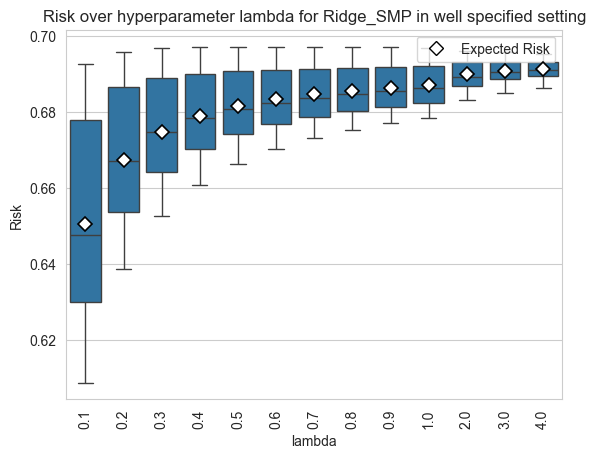

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(

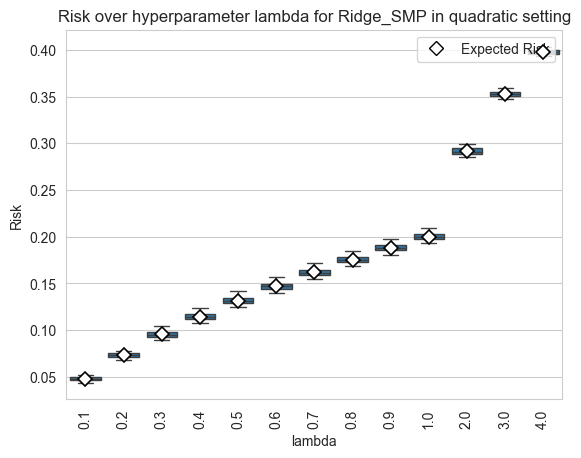

100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.492.
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an av

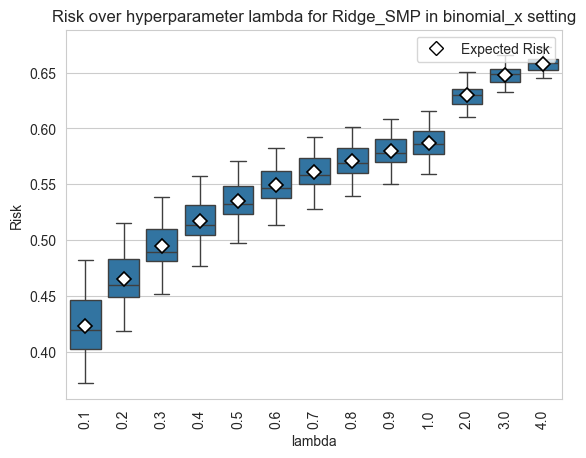

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504.
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an av

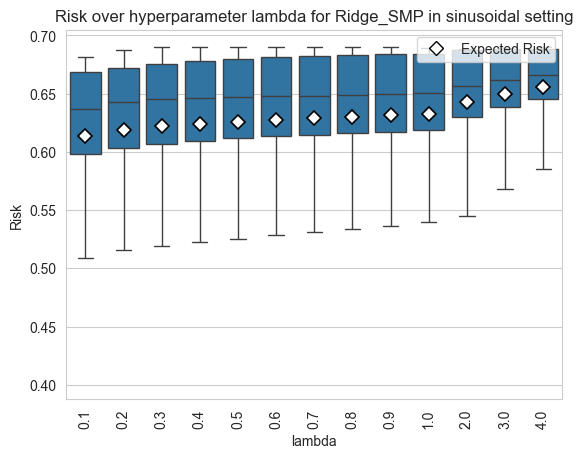

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.62
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.635
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.555
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.59
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.56
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.535
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.52
100 (training) samples were generated

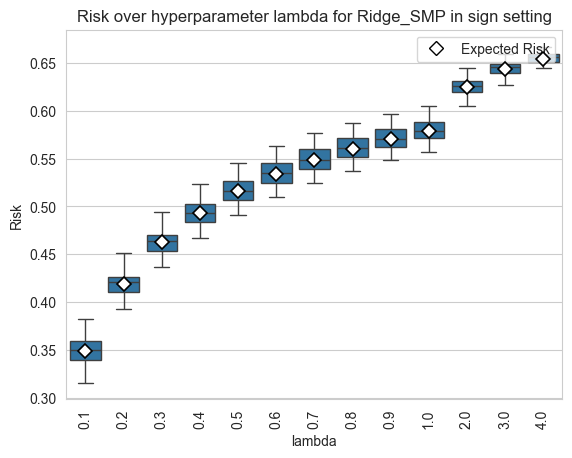

100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.522.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.487.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.531.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.534.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.492.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.515.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.475.
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P

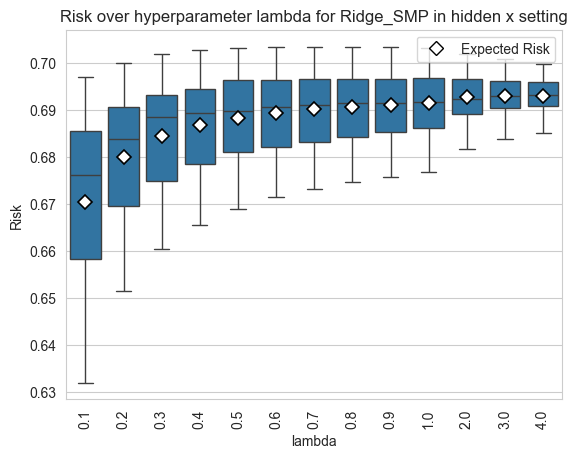

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.405
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.48
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an av

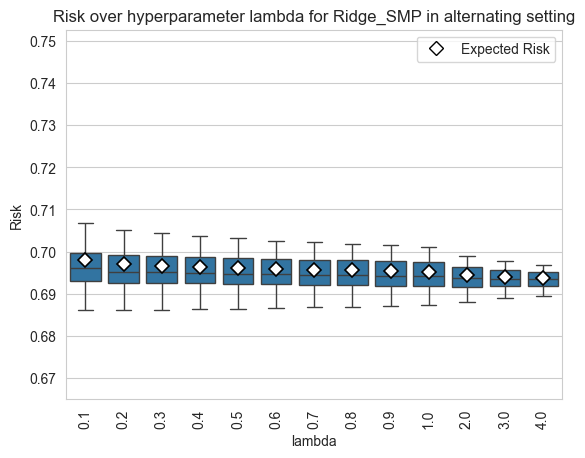

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimen

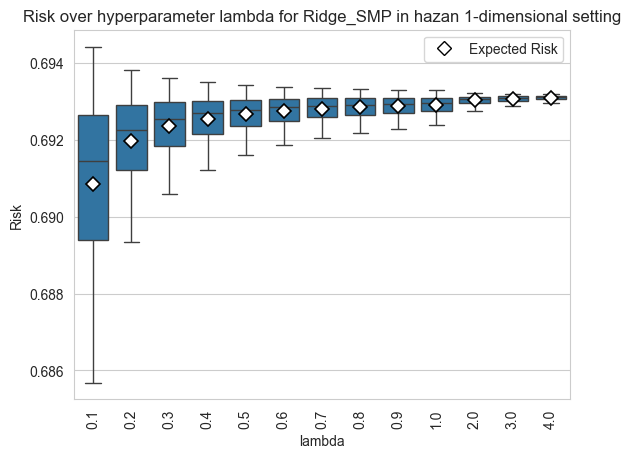

In [391]:
for setting in settings:
    hyperparameter_analysis(setting, "Ridge_SMP", "lambda", n = 100)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.99.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.991.
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.99.
100 (training) samples were generated in the well specified unba

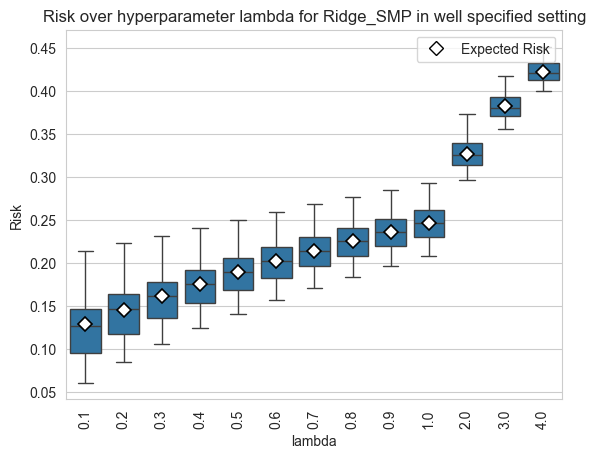

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.935.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.939.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.963.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.967.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.965.
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), w

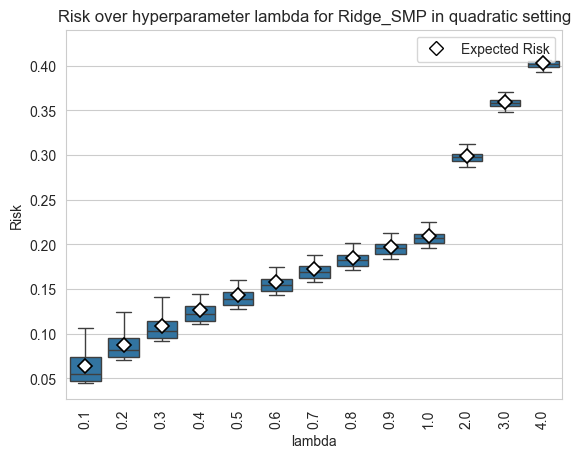

100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.1.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.09.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.096.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.103.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.106.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.094.
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(

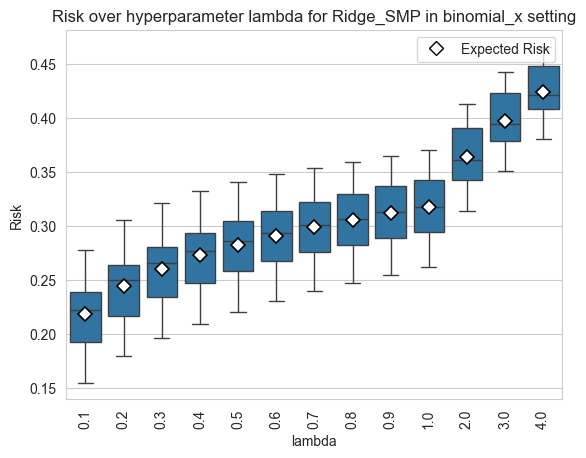

Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.464.
Sinusoidal will not be studied in unbalanced case
100 (training) samples were generated in the sinuso

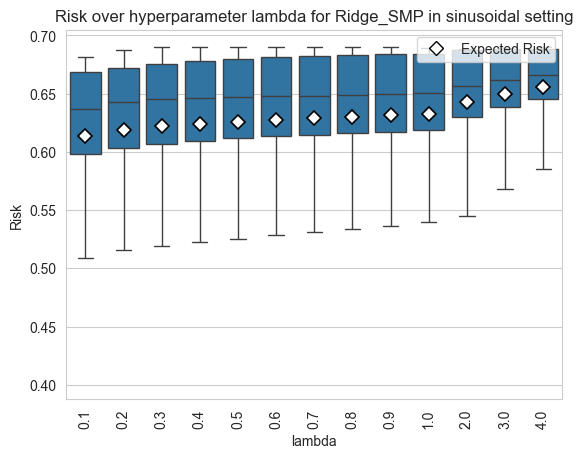

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.08
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.055
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04
100 (training) samp

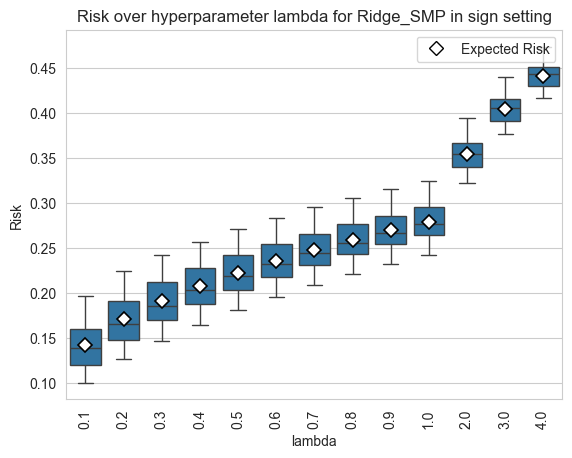

100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.0.
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average

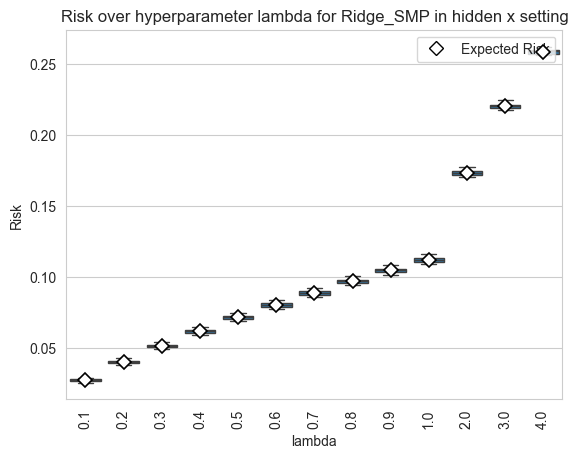

100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.005
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.01
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.005
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s

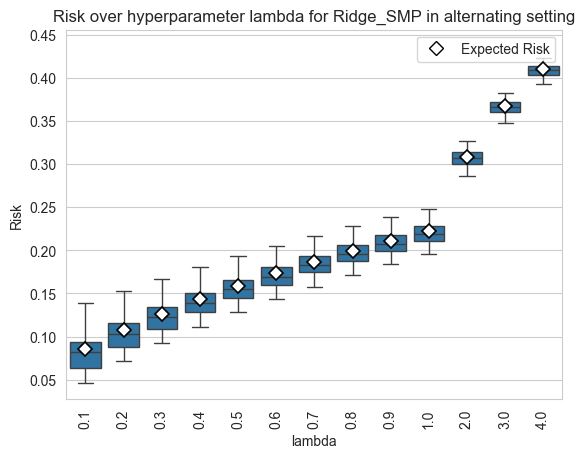

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.026666666666666665
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al

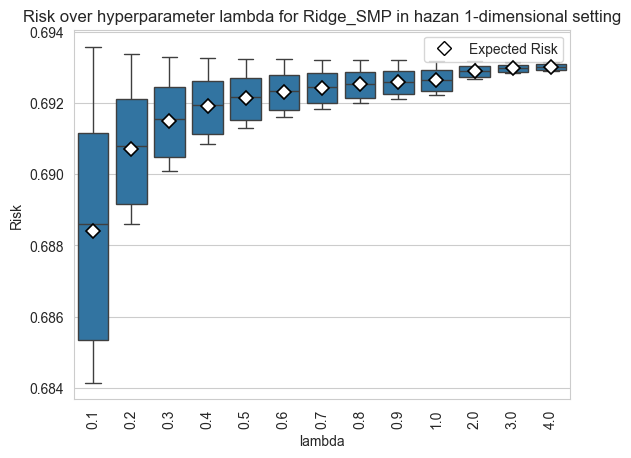

In [390]:
for setting in settings:
    hyperparameter_analysis(setting, "Ridge_SMP", "lambda", n = 100, balanced = False, X_hazan = -1)

# Functions for simulations

## Data class for specifying simulation configuration

In [118]:
default_X = 1
default_B_Adagrad = 3
@dataclass
class SimulationConfig:
    sim_betas: list =  None,
    # Default is well specified
    sim_setting: str =  "well specified"
    sim_balanced: bool = True
    runs: int = default_runs
    n: int = default_n
    d: int = 3
    data_seed: int = 40
    # betas: list = field(default_factory=lambda: [2,0.1,-4.2]) # This is to create a new list every time.
    # x_means: list = field(default_factory=lambda: [2,2,1])
    # These values of betas and x_means guarantee a P(Y=1) = 0.5, hence balanced classes.
    test_ratio: float = default_test_size
    minimize_method: str = "l-bfgs-b"
    y_method: str = "sigmoid"
    X_hazan: int = 1

In [119]:
# To record algorithm runtime
def time_it(fn):
            """Runs fn(), returns (result, elapsed_seconds)."""
            t0 = datetime.datetime.now()
            result = fn()
            return result, (datetime.datetime.now() - t0).total_seconds()

## Function to run simulations and get results

In [120]:
def run_simulation(cfg: SimulationConfig = None, B_hazan = None):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    minimize_method = cfg.minimize_method
    data_seed = cfg.data_seed
    sim_setting = cfg.sim_setting
    sim_balanced = cfg.sim_balanced
    X_hazan = cfg.X_hazan
    sim_betas = cfg.sim_betas

    test_set_results = []
    time_results = []
    y_counts = []
    start_time = datetime.datetime.now()

    all_y_trains = {}
    all_y_tests = {}

    for i in range(runs):
        x_train, y_train, x_test, y_test = generate_data(setting = sim_setting,
                                                             balanced = sim_balanced,
                                                             n = n,
                                                             seed = data_seed + i,
                                                             d = d,
                                                             X_hazan = X_hazan,
                                                             betas = sim_betas)

        y_counts.append({
            "count_1": int(np.sum(y_train == 1)),
            "count_minus1": int(np.sum(y_train == -1))
        })

        all_y_trains[f"run_{i+1}"] = y_train.copy()
        all_y_tests[f"run_{i+1}"] = y_test.copy()

        sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
        smote_x, smote_y = sm.apply_smote()


        # Fit
        ogd,           t_ogd_fit        = time_it(lambda: online_gd(data_y=y_train, data_x=x_train))
        adagrad,       t_adagrad_fit    = time_it(lambda: online_AdaGrad(data_y=y_train, data_x=x_train, B_vector=np.repeat(default_B_Adagrad, d)))
        aioli_model                     = AIOLI()
        ai,            t_aioli_fit      = time_it(lambda: aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=np.log(n), minimize_method=minimize_method))
        classic_LR,    t_clr_fit        = time_it(lambda: classic_logistic_regression(data_x=x_train, data_y=y_train))
        ridge_LR,      t_ridge_fit      = time_it(lambda: ridge_logistic_regression(data_x=x_train, data_y=y_train))
        lasso_LR,      t_lasso_fit      = time_it(lambda: lasso_logistic_regression(data_x=x_train, data_y=y_train))
        smp,           t_smp_fit        = time_it(lambda: sample_minmax_predictor(x_train, y_train))
        ridge_smp,     t_ridge_smp_fit  = time_it(lambda: ridge_sample_minmax_predictor(x_train, y_train))
        classic_LR_smote, t_smote_fit   = time_it(lambda: classic_logistic_regression(data_x=smote_x, data_y=smote_y))

        #  OTB averaging (counts toward OGD / AdaGrad time)
        OGD_OTB_uniform, t_ogd_u   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "uniform"))
        OGD_OTB_Suffix,  t_ogd_s   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "suffix_averaging"))
        OGD_OTB_lastit,  t_ogd_l   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "last_iterate"))

        adagrad_OTB_uniform, t_ada_u = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "uniform"))
        adagrad_OTB_Suffix,  t_ada_s = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "suffix_averaging"))
        adagrad_OTB_lastit,  t_ada_l = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "last_iterate"))

        #  Loss on test set
        loss_OGD_uniform_test,  t_ogd_u_loss  = time_it(lambda: log_loss(OGD_OTB_uniform, x_test, y_test))
        loss_OGD_Suffix_test,   t_ogd_s_loss  = time_it(lambda: log_loss(OGD_OTB_Suffix,  x_test, y_test))
        loss_OGD_lastit_test,   t_ogd_l_loss  = time_it(lambda: log_loss(OGD_OTB_lastit,  x_test, y_test))

        loss_adagrad_uniform_test, t_ada_u_loss = time_it(lambda: log_loss(adagrad_OTB_uniform, x_test, y_test))
        loss_adagrad_Suffix_test,  t_ada_s_loss = time_it(lambda: log_loss(adagrad_OTB_Suffix,  x_test, y_test))
        loss_adagrad_lastit_test,  t_ada_l_loss = time_it(lambda: log_loss(adagrad_OTB_lastit,  x_test, y_test))

        loss_AIOLI_uniform_test, t_aioli_u_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"])
        loss_AIOLI_Suffix_test,  t_aioli_s_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"])
        loss_AIOLI_lastit_test,  t_aioli_l_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"])

        loss_LR_test,       t_clr_loss       = time_it(lambda: log_loss(classic_LR["Batch_estimate"],       x_test, y_test))
        loss_LR_smote_test, t_smote_loss     = time_it(lambda: log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test))
        loss_LR_Ridge_test, t_ridge_loss     = time_it(lambda: log_loss(ridge_LR["Batch_estimate"],         x_test, y_test))
        loss_LR_Lasso_test, t_lasso_loss     = time_it(lambda: log_loss(lasso_LR["Batch_estimate"],         x_test, y_test))

        smp_result,       t_smp_loss      = time_it(lambda: smp.get_new_loss(x_test, y_test))
        ridge_smp_result, t_ridge_smp_loss = time_it(lambda: ridge_smp.get_new_loss(x_test, y_test))

        #  Collate results
        algorithms_test = {
            "Classical_LR":         {"loss": loss_LR_test,              "time_fit": t_clr_fit,       "time_loss": t_clr_loss},
            "Classical_LR_SMOTE":   {"loss": loss_LR_smote_test,        "time_fit": t_smote_fit,     "time_loss": t_smote_loss},
            "Ridge_LR":             {"loss": loss_LR_Ridge_test,         "time_fit": t_ridge_fit,     "time_loss": t_ridge_loss},
            "Lasso_LR":             {"loss": loss_LR_Lasso_test,         "time_fit": t_lasso_fit,     "time_loss": t_lasso_loss},
            "OGD_uniform":          {"loss": loss_OGD_uniform_test,      "time_fit": t_ogd_fit,       "time_loss": t_ogd_u + t_ogd_u_loss},
            "OGD_Suffix":           {"loss": loss_OGD_Suffix_test,       "time_fit": t_ogd_fit,       "time_loss": t_ogd_s + t_ogd_s_loss},
            "OGD_Last_iterate":     {"loss": loss_OGD_lastit_test,       "time_fit": t_ogd_fit,       "time_loss": t_ogd_l + t_ogd_l_loss},
            "AdaGrad_uniform":      {"loss": loss_adagrad_uniform_test,  "time_fit": t_adagrad_fit,   "time_loss": t_ada_u + t_ada_u_loss},
            "AdaGrad_Suffix":       {"loss": loss_adagrad_Suffix_test,   "time_fit": t_adagrad_fit,   "time_loss": t_ada_s + t_ada_s_loss},
            "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test,   "time_fit": t_adagrad_fit,   "time_loss": t_ada_l + t_ada_l_loss},
            "AIOLI_uniform":        {"loss": loss_AIOLI_uniform_test,    "time_fit": t_aioli_fit,     "time_loss": t_aioli_u_loss},
            "AIOLI_Suffix":         {"loss": loss_AIOLI_Suffix_test,     "time_fit": t_aioli_fit,     "time_loss": t_aioli_s_loss},
            "AIOLI_lastit":         {"loss": loss_AIOLI_lastit_test,     "time_fit": t_aioli_fit,     "time_loss": t_aioli_l_loss},
            "SMP":                  {"loss": smp_result["loss"],         "time_fit": t_smp_fit,       "time_loss": t_smp_loss},
            "Ridge_SMP":            {"loss": ridge_smp_result["loss"],   "time_fit": t_ridge_smp_fit, "time_loss": t_ridge_smp_loss},
        }

        for name, metrics in algorithms_test.items():
            row = {"run": i + 1, "algorithm": name, **metrics}
            row["time_total"] = row["time_fit"] + row["time_loss"]
            test_set_results.append(row)

        print(f"Run {i+1} finished")

    endtime = datetime.datetime.now()
    total_time = (endtime - start_time).total_seconds()

    results_df = pd.DataFrame(test_set_results)

    return {
        "test_results":    results_df[["run", "algorithm", "loss"]],
        "time_results":    results_df[["run", "algorithm", "time_fit", "time_loss", "time_total"]],
        "y_counts_train":  pd.DataFrame(y_counts),
        "y_train_df":      pd.DataFrame(all_y_trains),
        "y_test_df":       pd.DataFrame(all_y_tests),
        "total_time":      total_time,
    }

## High dimensional simulations for selected algorithms

In [121]:
def HD_run_simulation(cfg: SimulationConfig = None):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    minimize_method = cfg.minimize_method
    data_seed = cfg.data_seed
    sim_setting = cfg.sim_setting
    sim_balanced = cfg.sim_balanced
    sim_betas = cfg.sim_betas

    test_set_results = []
    time_results = []
    y_counts = []
    start_time = datetime.datetime.now()

    all_y_trains = {}
    all_y_tests = {}

    for i in range(runs):
        x_train, y_train, x_test, y_test = generate_data(setting = sim_setting,
                                                             balanced = sim_balanced,
                                                             n = n,
                                                             seed = data_seed + i,
                                                             d = d,
                                                             betas = sim_betas)

        y_counts.append({
            "count_1": int(np.sum(y_train == 1)),
            "count_minus1": int(np.sum(y_train == -1))
        })

        all_y_trains[f"run_{i+1}"] = y_train.copy()
        all_y_tests[f"run_{i+1}"] = y_test.copy()

        sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
        smote_x, smote_y = sm.apply_smote()

        # Fit

        aioli_model                     = AIOLI()
        ai,            t_aioli_fit      = time_it(lambda: aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=np.log(n), minimize_method=minimize_method))
        classic_LR,    t_clr_fit        = time_it(lambda: classic_logistic_regression(data_x=x_train, data_y=y_train))
        ridge_LR,      t_ridge_fit      = time_it(lambda: ridge_logistic_regression(data_x=x_train, data_y=y_train))
        lasso_LR,      t_lasso_fit      = time_it(lambda: lasso_logistic_regression(data_x=x_train, data_y=y_train))
        smp,           t_smp_fit        = time_it(lambda: sample_minmax_predictor(x_train, y_train))
        ridge_smp,     t_ridge_smp_fit  = time_it(lambda: ridge_sample_minmax_predictor(x_train, y_train))
        classic_LR_smote, t_smote_fit   = time_it(lambda: classic_logistic_regression(data_x=smote_x, data_y=smote_y))



        loss_AIOLI_uniform_test, t_aioli_u_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"])

        loss_LR_test,       t_clr_loss       = time_it(lambda: log_loss(classic_LR["Batch_estimate"],       x_test, y_test))
        loss_LR_smote_test, t_smote_loss     = time_it(lambda: log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test))
        loss_LR_Ridge_test, t_ridge_loss     = time_it(lambda: log_loss(ridge_LR["Batch_estimate"],         x_test, y_test))
        loss_LR_Lasso_test, t_lasso_loss     = time_it(lambda: log_loss(lasso_LR["Batch_estimate"],         x_test, y_test))

        smp_result,       t_smp_loss      = time_it(lambda: smp.get_new_loss(x_test, y_test))
        ridge_smp_result, t_ridge_smp_loss = time_it(lambda: ridge_smp.get_new_loss(x_test, y_test))

        #  Collate results
        algorithms_test = {
            "Classical_LR":         {"loss": loss_LR_test,              "time_fit": t_clr_fit,       "time_loss": t_clr_loss},
            "Classical_LR_SMOTE":   {"loss": loss_LR_smote_test,        "time_fit": t_smote_fit,     "time_loss": t_smote_loss},
            "Ridge_LR":             {"loss": loss_LR_Ridge_test,         "time_fit": t_ridge_fit,     "time_loss": t_ridge_loss},
            "Lasso_LR":             {"loss": loss_LR_Lasso_test,         "time_fit": t_lasso_fit,     "time_loss": t_lasso_loss},
            "AIOLI_uniform":        {"loss": loss_AIOLI_uniform_test,    "time_fit": t_aioli_fit,     "time_loss": t_aioli_u_loss},
            "SMP":                  {"loss": smp_result["loss"],         "time_fit": t_smp_fit,       "time_loss": t_smp_loss},
            "Ridge_SMP":            {"loss": ridge_smp_result["loss"],   "time_fit": t_ridge_smp_fit, "time_loss": t_ridge_smp_loss},
        }

        for name, metrics in algorithms_test.items():
            row = {"run": i + 1, "algorithm": name, **metrics}
            row["time_total"] = row["time_fit"] + row["time_loss"]
            test_set_results.append(row)

        print(f"Run {i+1} finished")

    endtime = datetime.datetime.now()
    total_time = (endtime - start_time).total_seconds()

    results_df = pd.DataFrame(test_set_results)

    return {
        "test_results":    results_df[["run", "algorithm", "loss"]],
        "time_results":    results_df[["run", "algorithm", "time_fit", "time_loss", "time_total"]],
        "y_counts_train":  pd.DataFrame(y_counts),
        "y_train_df":      pd.DataFrame(all_y_trains),
        "y_test_df":       pd.DataFrame(all_y_tests),
        "total_time":      total_time,
    }

## Simulations changing n

In [122]:
def simulations_changing_n(n_values: list, base_config: SimulationConfig, filename, B_hazan = None, high_dimensional_analysis = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run simulations for multiple sample sizes and aggregate results.

    Args:
        n_values: List of sample sizes to simulate
        base_config: Base SimulationConfig object (will copy and modify n for each run)

    Returns:
        summary_df: DataFrame with columns: n, algorithm, avg_loss, std_loss, num_runs
        raw_df: DataFrame with columns: n, algorithm, loss (one row per run)
    """
    all_summaries = []
    all_raw = []
    total_time = 0
    results_dict = None

    for n in n_values:
        print(f"="*50)
        print(f"Running simulations for n = {n}\n")
        print(f"="*50)
        # Create a copy of the config with the new n value
        config = base_config
        config.n = n  # Modify n in place

        # Run the simulation
        if high_dimensional_analysis:
            results_dict = HD_run_simulation(config)
        else:
            results_dict = run_simulation(config)

        # Extract test results
        test_results_df = results_dict["test_results"]
        total_time += results_dict["total_time"]

        # Add n column to raw data
        raw_with_n = test_results_df.copy()
        raw_with_n['n'] = n
        all_raw.append(raw_with_n)

        # Calculate average loss and standard deviation for each algorithm
        summary = test_results_df.groupby('algorithm').agg({
            'loss': ['mean', 'std', 'count']
        }).reset_index()


        # Flatten column names
        summary.columns = ['algorithm', 'avg_loss', 'std_loss', 'num_runs']

        summary['se_loss'] = summary['std_loss'] / np.sqrt(summary['num_runs'])
        summary = summary.drop(columns=["std_loss"])

        # Add n value
        summary['n'] = n

        # Reorder columns
        summary = summary[['n', 'algorithm', 'avg_loss', 'se_loss', 'num_runs']]

        all_summaries.append(summary)

        print(f"Completed simulations for n = {n}")

        # Save to csv
        temp_summary_df = pd.concat(all_summaries, ignore_index=True)
        temp_summary_df.to_csv(f"{filename}.csv")

    # Combine all results
    summary_df = pd.concat(all_summaries, ignore_index=True)
    raw_df = pd.concat(all_raw, ignore_index=True)
    print(f"Total time: {total_time} seconds")
    return summary_df, raw_df

In [274]:
def plot_simulation_results(
    raw_data: pd.DataFrame,
    algorithms: list = None,
    figsize: tuple = (12, 8),
    title: str = 'Algorithm Performance vs Sample Size',
    xlabel: str = 'Sample Size (n)',
    ylabel: str = 'Risk',
    box_alpha: float = 0.6,
    show_plot: bool = True
) -> plt.Figure:
    """
    Plot box plots of loss distributions per algorithm across different sample sizes.

    Args:
        raw_data: DataFrame with columns: algorithm, n, loss (one row per run)
        algorithms: List of algorithm names to plot (None = all)
        figsize: Figure size (width, height)
        title: Plot title
        xlabel: X-axis label
        ylabel: Y-axis label
        box_alpha: Transparency of box fill (0 = transparent, 1 = opaque)
        show_plot: Whether to display the plot

    Returns:
        None
    """
    # Filter algorithms if specified
    raw_plot = raw_data.copy()
    if algorithms is not None:
        raw_plot = raw_plot[raw_plot['algorithm'].isin(algorithms)]

    if raw_plot.empty:
        print("No data to plot.")
        return None

    # Ensure n is treated as a categorical axis so boxes are evenly spaced
    raw_plot["n"] = raw_plot["n"].astype(str)

    fig, ax = plt.subplots(figsize=figsize)
    sns.set_style("whitegrid")

    sns.boxplot(
        data=raw_plot,
        x="n",
        y="loss",
        hue="algorithm",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
        showmeans = True,
        meanprops=dict(
        marker="D",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.2,
        zorder=10,
        ),
        ax=ax
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Formatting
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.legend(title="Algorithm", loc='best', prop={'size': 10})
    ax.grid(True, alpha=0.3)


    mean_handle = Line2D([], [], marker='D', markerfacecolor='white', markeredgecolor='black',
                          markersize=7, linestyle='none', label='Expected Risk')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [mean_handle], labels=labels + ['Expected Risk'],
              title="Algorithm", loc="best", prop={'size': 10})

    plt.tight_layout()

    if show_plot:
        plt.show()

    return None

## Function for printing results

In [124]:
def get_variable_name(var, namespace=None):
    if namespace is None:
        namespace = globals()
    for name, value in namespace.items():
        if value is var:
            return name
    return None

In [125]:
def print_results(results, n=default_n, plot=False, selected_algorithms=None, runs=default_runs, box_alpha=0.6, summary_object = False):
    # Save to csv
    df_name = get_variable_name(results)
    results["test_results"].to_csv(f"{df_name}.csv")

    #  Loss summary 
    summary_test_average = results["test_results"].groupby("algorithm")[["loss"]].mean()
    summary_test_se      = results["test_results"].groupby("algorithm")[["loss"]].std(ddof=1) / np.sqrt(runs)

    summary = pd.concat([summary_test_average, summary_test_se], axis=1)
    summary.columns = ["Average_Loss", "SE_Loss"]

    #  Time summary 
    time_avg = results["time_results"].groupby("algorithm")[["time_fit", "time_loss", "time_total"]].mean()
    time_se  = results["time_results"].groupby("algorithm")[["time_total"]].std(ddof=1) / np.sqrt(runs)

    time_summary = pd.concat([time_avg, time_se], axis=1)
    time_summary.columns = [
        "Avg_Time_Fit", "Avg_Time_Loss", "Avg_Time_Total", "SE_Time_Total"
    ]

    #  Print 
    print(f"Total time: {str(datetime.timedelta(seconds=results['total_time']))}")

    print("\n Loss Results ")
    display(summary)

    print("\n Time Results (seconds) ")
    display(time_summary)

    if not summary_object:
        return
    else:
        return summary

    #  Boxplot 
    if not plot:
        return

    raw_data = results["test_results"].copy()
    if selected_algorithms is not None:
        raw_data = raw_data[raw_data["algorithm"].isin(selected_algorithms)]

    if raw_data.empty:
        print("No data to plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.set_style("whitegrid")

    sns.boxplot(
        data=raw_data,
        x="algorithm",
        y="loss",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
        ax=ax
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Aesthetics
    ax.set_xlabel("Algorithm", fontsize=12, fontweight="bold")
    ax.set_ylabel("Risk", fontsize=12, fontweight="bold")
    ax.set_title("Risk distribution across runs", fontsize=14, fontweight="bold")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Plot results (Function for graphing loss and Y=1 counts over runs)

In [126]:
def plot_results(results, n = default_n, plot = False):
    test_results = results["test_results"]

    # Boxplots of y counts
    if plot:
        sns.boxplot(data=results["y_counts_train"][["count_1", "count_minus1"]])
        plt.title("Distribution of Y counts across runs")
        plt.ylim(-10, n)
        plt.show()
        # Line plot of Loss over rounds
        sns.lineplot(x = test_results["run"], y = test_results["loss"], hue = test_results["algorithm"]).set_title("Loss over rounds")
        plt.show()
    else:
        pass

    # Distribution of y values
    print("Train set")
    print(results["y_train_df"].apply(pd.Series.value_counts))
    print("Test set")
    print(results["y_test_df"].apply(pd.Series.value_counts))


## Compare settings

In [273]:
def compare_settings(
    settings_dict: dict,
    selected_algorithms: list = None,
    x_labels: dict = None,
    figsize: tuple = (12, 6),
    title: str = 'Algorithm Performance Across Balanced Settings',
    xlabel: str = 'Setting',
    ylabel: str = 'Risk',
    box_alpha: float = 0.6,
    show_plot: bool = True,
    return_data: bool = False
):
    """
    Combine results from multiple settings and create a box plot of loss
    per algorithm across runs.

    Parameters:
        settings_dict : dict
            Keys are setting names (str), values are results dictionaries from run_simulation.
        selected_algorithms : list, optional
            List of algorithm names to include. If None, all are plotted.
        x_labels : dict, optional
            Mapping from setting key to display label on the x-axis.
            e.g. {"s1": "Well Specified", "s2": "High Dimensional"}
            If None, the setting keys are used as-is.
        figsize : tuple
            Figure size.
        title, xlabel, ylabel : str
            Plot labels.
        box_alpha : float
            Transparency of the box fill (0 = transparent, 1 = opaque).
        show_plot : bool
            Whether to display the plot.
        return_data : bool
            If True, return the combined raw DataFrame.

    Returns:
        raw_df : pd.DataFrame (optional)
            Combined raw data with columns: setting, algorithm, loss.
    """
    # Collect raw data from all settings
    all_raw = []
    for setting, res in settings_dict.items():
        df = res["test_results"].copy()
        df["setting"] = setting
        all_raw.append(df)
    combined_raw = pd.concat(all_raw, ignore_index=True)

    # Remap setting keys to display labels if provided
    if x_labels is not None:
        combined_raw["setting"] = combined_raw["setting"].map(x_labels).fillna(combined_raw["setting"])

    # Filter algorithms if needed
    if selected_algorithms is not None:
        combined_raw = combined_raw[combined_raw["algorithm"].isin(selected_algorithms)]

    if combined_raw.empty:
        print("No data to plot.")
        return

    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    ax = sns.boxplot(
        data=combined_raw,
        x="setting",
        y="loss",
        hue="algorithm",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
        showmeans=True,
        meanprops=dict(
            marker='D',
            markerfacecolor='white',
            markeredgecolor='black',
            markersize=7,
            markeredgewidth=1.2,
            zorder=10,
        ),
    )

    # Apply alpha to box fills after
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Formatting
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")

    # Legend: algorithm colors + a manual "ER" entry explaining the  marker

    mean_handle = Line2D([], [], marker='D', markerfacecolor='white', markeredgecolor='black',
                          markersize=7, linestyle='none', label='Expected Risk')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [mean_handle], labels=labels + ['Expected Risk'],
              title="Algorithm", loc="best", prop={'size': 10})

    plt.xticks(rotation=0)
    plt.tight_layout()

    if show_plot:
        plt.show()

    if return_data:
        return combined_raw
    else:
        return None

# Experiments

## Hazan setting

In [131]:
hazan = SimulationConfig(
    sim_setting = "hazan 1-dimensional"
)

hazan_result = run_simulation(hazan)
print_results(hazan_result)

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated us

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.5964771036,0.0225941708
AIOLI_lastit,0.5906071409,0.0210860819
AIOLI_uniform,0.5718082808,0.0229947635
AdaGrad_Last_iterate,0.8694388271,0.0611361903
AdaGrad_Suffix,0.8862223145,0.0679694505
AdaGrad_uniform,0.8445574482,0.0517803041
Classical_LR,0.7834200539,0.0530786716
Classical_LR_SMOTE,0.7117610531,0.0202761150
Lasso_LR,0.7174021322,0.0227219837



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.0511636000,3.8347123000,3.8858759000,0.2298509001
AIOLI_lastit,0.0511636000,3.8523584000,3.9035220000,0.2526464031
AIOLI_uniform,0.0511636000,4.2414399000,4.2926035000,0.3711274034
AdaGrad_Last_iterate,0.0009804000,0.0000117000,0.0009921000,0.0002683680
AdaGrad_Suffix,0.0009804000,0.0000145000,0.0009949000,0.0002698524
AdaGrad_uniform,0.0009804000,0.0000217000,0.0010021000,0.0002691117
Classical_LR,0.0010512000,0.0000120000,0.0010632000,0.0000674499
Classical_LR_SMOTE,0.0008681000,0.0000259000,0.0008940000,0.0002144371
Lasso_LR,0.0013751000,0.0000073000,0.0013824000,0.0003459488


In [132]:
plot_results(hazan_result)

Train set
               run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
-1.0000000000     99     98     95     96     95     98     94     96     95   
1.0000000000       1      2      5      4      5      2      6      4      5   

               run_10  
-1.0000000000      93  
1.0000000000        7  
Test set
               run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
-1.0000000000     95     96     95     93     96     94     94     93     93   
1.0000000000       5      4      5      7      4      6      6      7      7   

               run_10  
-1.0000000000      93  
1.0000000000        7  


In [133]:
hazan_Xminus1 = SimulationConfig(
    sim_setting = "hazan 1-dimensional",
    n = 100,
    runs = 10,
    X_hazan = -1
)

hazan_Xminus1_result = run_simulation(hazan_Xminus1)
print_results(hazan_Xminus1_result)

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average 

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.4755984881,0.0337782751
AIOLI_lastit,0.4658019609,0.0292914546
AIOLI_uniform,0.4750523647,0.0283514632
AdaGrad_Last_iterate,0.5905012862,0.0628395619
AdaGrad_Suffix,0.5929266222,0.0638817847
AdaGrad_uniform,0.5792576322,0.0562574980
Classical_LR,0.5897954270,0.0532790941
Classical_LR_SMOTE,0.6112524301,0.0333833104
Lasso_LR,0.5885597051,0.0370993051



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.0440884000,3.9410754000,3.9851638000,0.2230742026
AIOLI_lastit,0.0440884000,3.9452124000,3.9893008000,0.2342834958
AIOLI_uniform,0.0440884000,4.0458764000,4.0899648000,0.2166219398
AdaGrad_Last_iterate,0.0008191000,0.0000072000,0.0008263000,0.0001119170
AdaGrad_Suffix,0.0008191000,0.0000111000,0.0008302000,0.0001117788
AdaGrad_uniform,0.0008191000,0.0000118000,0.0008309000,0.0001119893
Classical_LR,0.0010419000,0.0000123000,0.0010542000,0.0000541021
Classical_LR_SMOTE,0.0009017000,0.0000076000,0.0009093000,0.0001162379
Lasso_LR,0.0012818000,0.0000066000,0.0012884000,0.0001182529


In [134]:
settings_results_hazan = {
    "Hazan": hazan_result,
    "Hazan_Xminus1": hazan_Xminus1_result
}

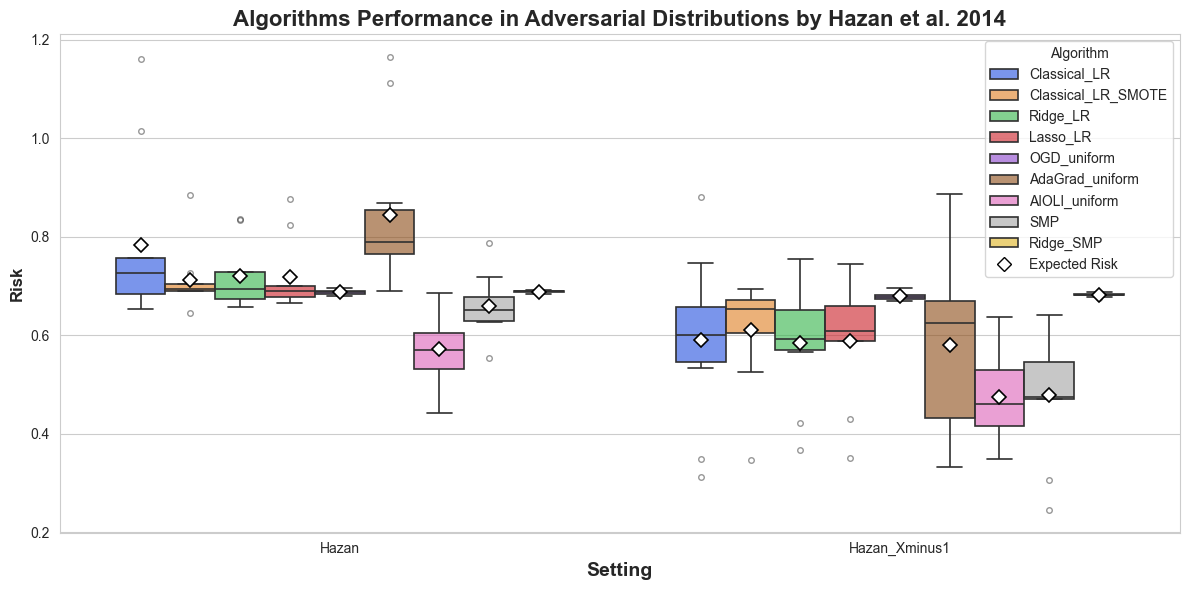

In [398]:
compare_settings(settings_results_hazan, title = "Algorithms Performance in Adversarial Distributions by Hazan et al. 2014", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"])

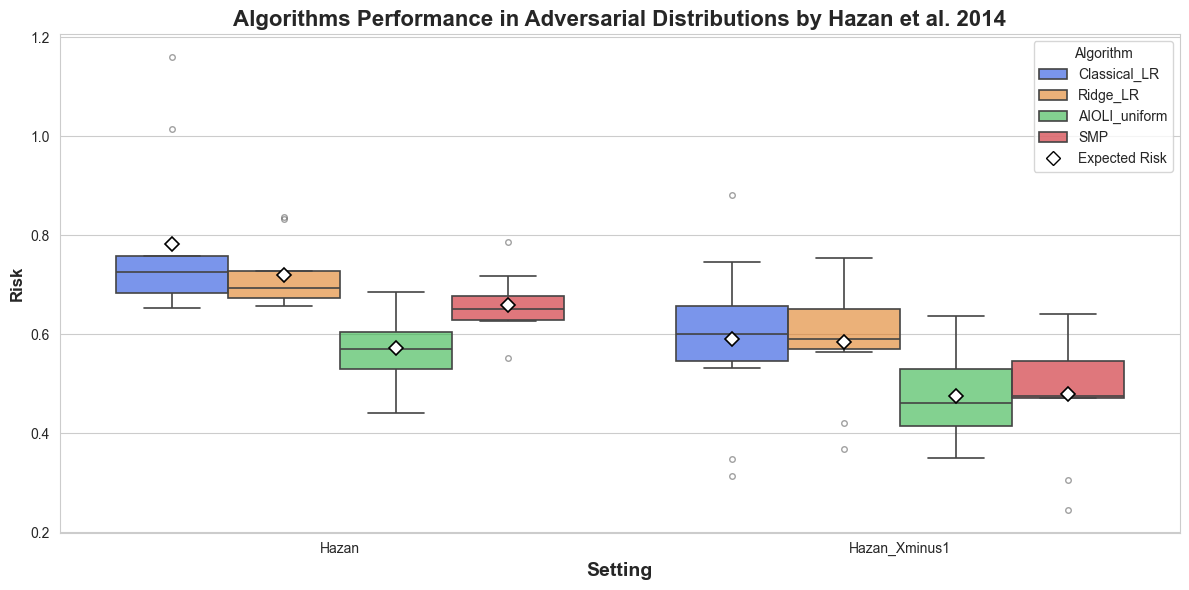

In [399]:

compare_settings(
    settings_results_hazan,
    selected_algorithms=["Classical_LR", "SMP", "AIOLI_uniform", "Ridge_LR"], title = "Algorithms Performance in Adversarial Distributions by Hazan et al. 2014"
)

## Balanced

In [137]:
#Binomial
binomial = SimulationConfig(
    sim_setting = "binomial_x",
    n = 100
)

binomial_result = run_simulation(binomial)
print_results(binomial_result)

100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.578.
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.565.
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.616.
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.576.
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.624.
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.582.
Lasso LR was fit manually
R

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.4906103049,0.0186821587
AIOLI_lastit,0.5180825594,0.0211229819
AIOLI_uniform,0.4839545404,0.0149870006
AdaGrad_Last_iterate,0.6601494643,0.0840148968
AdaGrad_Suffix,0.5351192014,0.0198682330
AdaGrad_uniform,0.5428697996,0.0422586544
Classical_LR,0.4807241714,0.0153503639
Classical_LR_SMOTE,0.5295037994,0.0167374236
Lasso_LR,0.4798619448,0.0144646357



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.1968348000,19.2062579000,19.4030927000,0.3254390732
AIOLI_lastit,0.1968348000,19.2915224000,19.4883572000,0.2992790881
AIOLI_uniform,0.1968348000,19.3840583000,19.5808931000,0.3761038277
AdaGrad_Last_iterate,0.0009401000,0.0000112000,0.0009513000,0.0000127096
AdaGrad_Suffix,0.0009401000,0.0000168000,0.0009569000,0.0000129103
AdaGrad_uniform,0.0009401000,0.0000185000,0.0009586000,0.0000126888
Classical_LR,0.0015158000,0.0000243000,0.0015401000,0.0001218933
Classical_LR_SMOTE,0.0017664000,0.0000150000,0.0017814000,0.0001900440
Lasso_LR,0.0026489000,0.0000125000,0.0026614000,0.0001353104


In [138]:
plot_results(binomial_result)

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
 1     54     58     67     55     63     56     57     58     54      65
-1     46     42     33     45     37     44     43     42     46      35
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     42     50     35     42     41     43     38     39     37      34
 1     58     50     65     58     59     57     62     61     63      66


In [139]:
# Well Specified
well_specified = SimulationConfig(
    sim_setting = "well specified",
    d = 3
)

well_specified_result = run_simulation(well_specified)
print_results(well_specified_result)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.508.
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505.
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499.
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498.
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5.
Dataset is balanced
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6966828027,0.0161585573
AIOLI_lastit,0.7169512368,0.0240517513
AIOLI_uniform,0.6890127583,0.0093574560
AdaGrad_Last_iterate,0.8554260629,0.0779983389
AdaGrad_Suffix,0.7032366432,0.0142004929
AdaGrad_uniform,0.6884155938,0.0058443888
Classical_LR,0.6895696220,0.0124809952
Classical_LR_SMOTE,0.7232430684,0.0121094913
Lasso_LR,0.6891699589,0.0070396458



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.1629564000,14.8359382000,14.9988946000,0.2607394006
AIOLI_lastit,0.1629564000,14.8866461000,15.0496025000,0.3031409557
AIOLI_uniform,0.1629564000,15.0145622000,15.1775186000,0.2900383694
AdaGrad_Last_iterate,0.0009055000,0.0000098000,0.0009153000,0.0000184029
AdaGrad_Suffix,0.0009055000,0.0000149000,0.0009204000,0.0000181336
AdaGrad_uniform,0.0009055000,0.0000163000,0.0009218000,0.0000182018
Classical_LR,0.0014582000,0.0000162000,0.0014744000,0.0001408742
Classical_LR_SMOTE,0.0015373000,0.0000105000,0.0015478000,0.0001342618
Lasso_LR,0.0093764000,0.0000092000,0.0093856000,0.0012574154


In [140]:
plot_results(well_specified_result)

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     47     53     48     51     50     56     45     46     50      46
 1     53     47     52     49     50     44     55     54     50      54
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     45     55     48     51     53     53     50     55     46      53
 1     55     45     52     49     47     47     50     45     54      47


In [141]:
quadratic = SimulationConfig(
    sim_setting = "quadratic",
    d = 3
)

quadratic_result = run_simulation(quadratic)
print_results(quadratic_result)

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.051.
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.052.
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.054.
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.048.
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.045.
Dataset is balanced
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.047.
Lasso LR was 

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.5998395036,0.0138678476
AIOLI_lastit,0.6177084853,0.0126403412
AIOLI_uniform,0.5900692148,0.0138373402
AdaGrad_Last_iterate,0.7245042527,0.0608824737
AdaGrad_Suffix,0.6239459189,0.0163137454
AdaGrad_uniform,0.6330153938,0.0116562617
Classical_LR,0.5826225886,0.0127730806
Classical_LR_SMOTE,0.5977584484,0.0146489241
Lasso_LR,0.5905570360,0.0150308485



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2348655000,17.5735263000,17.8083918000,0.6849724847
AIOLI_lastit,0.2348655000,18.5473013000,18.7821668000,1.1516935848
AIOLI_uniform,0.2348655000,18.6296801000,18.8645456000,1.0575761716
AdaGrad_Last_iterate,0.0013122000,0.0000096000,0.0013218000,0.0003768112
AdaGrad_Suffix,0.0013122000,0.0000147000,0.0013269000,0.0003786676
AdaGrad_uniform,0.0013122000,0.0000150000,0.0013272000,0.0003785207
Classical_LR,0.0017256000,0.0000244000,0.0017500000,0.0002021021
Classical_LR_SMOTE,0.0016048000,0.0000129000,0.0016177000,0.0001724982
Lasso_LR,0.0058015000,0.0000098000,0.0058113000,0.0015797634


In [142]:
plot_results(quadratic_result)

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     54     54     54     57     50     59     43     49     55      50
 1     46     46     46     43     50     41     57     51     45      50
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     48     61     49     52     59     51     51     57     51      57
 1     52     39     51     48     41     49     49     43     49      43


In [143]:
# Sinusoidal
sinusoidal = SimulationConfig(
    sim_setting = "sinusoidal",
    n = 100
)

sinusoidal_result = run_simulation(sinusoidal)
print_results(sinusoidal_result)

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509.
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.452.
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.533.
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.473.
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.507.
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.539.
Lasso LR was fit manually
R

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6581136968,0.0178963154
AIOLI_lastit,0.6690431896,0.0226542712
AIOLI_uniform,0.6501836130,0.0165314314
AdaGrad_Last_iterate,0.7702969321,0.0238643625
AdaGrad_Suffix,0.6854510330,0.0113432716
AdaGrad_uniform,0.6813173187,0.0097904231
Classical_LR,0.6584923182,0.0154409620
Classical_LR_SMOTE,0.7056998088,0.0219590324
Lasso_LR,0.6571682207,0.0151055786



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.1548491000,14.8814851000,15.0363342000,0.5761254192
AIOLI_lastit,0.1548491000,14.8708874000,15.0257365000,0.5367994728
AIOLI_uniform,0.1548491000,14.9895421000,15.1443912000,0.5450521219
AdaGrad_Last_iterate,0.0010895000,0.0000074000,0.0010969000,0.0001596398
AdaGrad_Suffix,0.0010895000,0.0000114000,0.0011009000,0.0001595315
AdaGrad_uniform,0.0010895000,0.0000125000,0.0011020000,0.0001595741
Classical_LR,0.0015579000,0.0000147000,0.0015726000,0.0001231724
Classical_LR_SMOTE,0.0015784000,0.0000091000,0.0015875000,0.0001412768
Lasso_LR,0.0101895000,0.0000077000,0.0101972000,0.0019331437


In [144]:
# Sign
sign = SimulationConfig(
    sim_setting = "sign",
    n = 100,
    d = 3
)

sign_result = run_simulation(sign)
print_results(sign_result)

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.48
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
Lasso LR was fit manually
Run 6 finished
100 (training) samples were gen

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.1154084456,0.0038356623
AIOLI_lastit,0.0999358704,0.0031689566
AIOLI_uniform,0.1402210239,0.0038511061
AdaGrad_Last_iterate,0.1538795467,0.0211631769
AdaGrad_Suffix,0.1377343268,0.0079907838
AdaGrad_uniform,0.1676280660,0.0129702014
Classical_LR,0.0638942176,0.0312220150
Classical_LR_SMOTE,0.0812250824,0.0358645537
Lasso_LR,0.1084763977,0.0055294713



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.1569795000,13.9807437000,14.1377232000,0.1030390025
AIOLI_lastit,0.1569795000,14.0052407000,14.1622202000,0.1316970205
AIOLI_uniform,0.1569795000,14.2162337000,14.3732132000,0.1101540914
AdaGrad_Last_iterate,0.0011688000,0.0000096000,0.0011784000,0.0002743064
AdaGrad_Suffix,0.0011688000,0.0000154000,0.0011842000,0.0002739929
AdaGrad_uniform,0.0011688000,0.0000487000,0.0012175000,0.0002722095
Classical_LR,0.0023486000,0.0000136000,0.0023622000,0.0001680917
Classical_LR_SMOTE,0.0021069000,0.0000083000,0.0021152000,0.0001119526
Lasso_LR,0.0030986000,0.0000078000,0.0031064000,0.0001767472


In [145]:
# Hidden X
hidden_x = SimulationConfig(
    sim_setting = "hidden x",
    n = 100,
    d = 3
)

hidden_x_result = run_simulation(hidden_x)
print_results(hidden_x_result)

100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.481.
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.501.
Dataset is balanced
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.506.
Dataset is balanced
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.543.
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.544.
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the hidden x balanced setting. Using 25 variable(s), with an average P(Y=1) of 

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6552973326,0.0115094243
AIOLI_lastit,0.6575955334,0.0127731467
AIOLI_uniform,0.6506715172,0.0132035823
AdaGrad_Last_iterate,0.7156985885,0.0349965048
AdaGrad_Suffix,0.6702563897,0.0163362450
AdaGrad_uniform,0.6632961826,0.0145569247
Classical_LR,0.6441239065,0.0128827965
Classical_LR_SMOTE,0.6477642680,0.0171841137
Lasso_LR,0.6484249006,0.0129155338



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.1612046000,14.5721194000,14.7333240000,0.3275619201
AIOLI_lastit,0.1612046000,14.6495377000,14.8107423000,0.3035441147
AIOLI_uniform,0.1612046000,14.7819331000,14.9431377000,0.3214845957
AdaGrad_Last_iterate,0.0008865000,0.0000075000,0.0008940000,0.0000123360
AdaGrad_Suffix,0.0008865000,0.0000111000,0.0008976000,0.0000123812
AdaGrad_uniform,0.0008865000,0.0000112000,0.0008977000,0.0000124008
Classical_LR,0.0014693000,0.0000175000,0.0014868000,0.0001074542
Classical_LR_SMOTE,0.0012413000,0.0000100000,0.0012513000,0.0000957659
Lasso_LR,0.0059032000,0.0000088000,0.0059120000,0.0015177893


In [146]:
# Alternating
alternating = SimulationConfig(
    sim_setting = "alternating",
    n = 100,
    d = 3
)

alternating_result = run_simulation(alternating)
print_results(alternating_result)

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.45
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.52
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.485
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
Dataset is balanced
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.485
Lasso LR w

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.7130004180,0.0051045688
AIOLI_lastit,0.7447895609,0.0219146616
AIOLI_uniform,0.7022232774,0.0066511145
AdaGrad_Last_iterate,0.8820995820,0.0660172353
AdaGrad_Suffix,0.7242782964,0.0110634975
AdaGrad_uniform,0.7019374979,0.0037296578
Classical_LR,0.7056824324,0.0061718392
Classical_LR_SMOTE,0.7574317783,0.0156210173
Lasso_LR,0.6952545471,0.0018309552



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.1570976000,13.8628086000,14.0199062000,0.3116824962
AIOLI_lastit,0.1570976000,13.8642760000,14.0213736000,0.3838720180
AIOLI_uniform,0.1570976000,14.0200794000,14.1771770000,0.4193264935
AdaGrad_Last_iterate,0.0010582000,0.0000082000,0.0010664000,0.0001804766
AdaGrad_Suffix,0.0010582000,0.0000129000,0.0010711000,0.0001804200
AdaGrad_uniform,0.0010582000,0.0000114000,0.0010696000,0.0001806627
Classical_LR,0.0013568000,0.0000276000,0.0013844000,0.0001214826
Classical_LR_SMOTE,0.0013508000,0.0000074000,0.0013582000,0.0000743514
Lasso_LR,0.0083518000,0.0000065000,0.0083583000,0.0017769083


In [147]:
# High Dimensional
high_dimensional = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25
)

In [148]:
high_dimensional_result = run_simulation(high_dimensional)
print_results(high_dimensional_result)

20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.505.
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.507.
Lasso LR was fit manually
Run 2 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.517.
Lasso LR was fit manually
Run 3 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.572.
Dataset is balanced
Lasso LR was fit manually
Run 4 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.551.
Lasso LR was fit manually
Run 5 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.6535173456,0.0115709599
AIOLI_lastit,0.6346128716,0.0143011276
AIOLI_uniform,0.6632080271,0.0079492300
AdaGrad_Last_iterate,7.6475727960,1.7183196790
AdaGrad_Suffix,6.0612261488,1.4953656304
AdaGrad_uniform,6.2620966876,1.7347687267
Classical_LR,7.9199538214,2.7383673233
Classical_LR_SMOTE,4.3613438617,0.4817987004
Lasso_LR,0.7225748699,0.0335586159



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.3894845000,36.0770426000,36.4665271000,0.4592211349
AIOLI_lastit,0.3894845000,35.8696071000,36.2590916000,0.3578790456
AIOLI_uniform,0.3894845000,36.1282466000,36.5177311000,0.3999354549
AdaGrad_Last_iterate,0.0009503000,0.0000115000,0.0009618000,0.0001859944
AdaGrad_Suffix,0.0009503000,0.0000174000,0.0009677000,0.0001866320
AdaGrad_uniform,0.0009503000,0.0000211000,0.0009714000,0.0001864362
Classical_LR,0.0030327000,0.0000146000,0.0030473000,0.0003021988
Classical_LR_SMOTE,0.0039457000,0.0000077000,0.0039534000,0.0002576259
Lasso_LR,0.1053616000,0.0000068000,0.1053684000,0.0156868926


In [345]:
# Understanding Difference in risk of LR in balanced vs unbalanced high dimensional
a,b,c,d = generate_data("high dimensional", n =20, seed = 40, balanced=False)
LR = classic_logistic_regression(a,b)
log_loss(LR["Batch_estimate"], c,d)
LR["Batch_estimate"]

betas_n20 = LR["Batch_estimate"]

a_n50,b_n50,c_n50,d_n50 = generate_data("high dimensional", n =50, seed = 40, balanced = False)
LR_n50 = classic_logistic_regression(a_n50,b_n50)

betas_n50 = LR_n50["Batch_estimate"]

print(betas_n20)
print(betas_n50)

20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.902.
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.899.
[-5.0856  7.7971 -4.0908 -0.104  -4.0508  0.5167  2.1387  1.0679  2.5389
  5.7627  0.4776 -2.9029  0.9605  1.9255  4.5624  1.873  -1.3036  4.5493
 -3.9861  3.2763  1.9088  3.0335  5.7402 -1.1301 -2.5415]
[  20.1173    7.9234 -123.4061  -24.2941  -28.7562  -83.495   -45.8787
  -21.178    89.3911   43.0708  -27.9644    3.7367  -51.0026   93.854
   44.2801   57.4085  -40.9317   35.4706   34.859    -3.5755  -12.4372
   35.9199  105.8184  -34.2226    0.5919]


In [149]:
plot_results(high_dimensional_result, n = 20)

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     11      7     12     10      8      9      6     14      6      13
 1      9     13      8     10     12     11     14      6     14       7
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     48     51     47     44     49     54     56     55     56      46
 1     52     49     53     56     51     46     44     45     44      54


In [150]:
# High Dimensionality
high_dimensionality = SimulationConfig(
    sim_setting = "high dimensional",
    n = 50,
    d = 25
)

high_dimensionality_result = run_simulation(high_dimensionality)
print_results(high_dimensionality_result)

50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.485.
Lasso LR was fit manually
Run 1 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.512.
Lasso LR was fit manually
Run 2 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.52.
Lasso LR was fit manually
Run 3 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.568.
Lasso LR was fit manually
Run 4 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.551.
Lasso LR was fit manually
Run 5 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.5400186026,0.0112122790
AIOLI_lastit,0.5158575158,0.0128875715
AIOLI_uniform,0.5817330910,0.0091465575
AdaGrad_Last_iterate,6.6476853876,1.0826297839
AdaGrad_Suffix,3.7502290733,0.5904041741
AdaGrad_uniform,3.2063723429,0.8295530605
Classical_LR,20.8518652308,6.0816508373
Classical_LR_SMOTE,36.9109960728,12.7494638123
Lasso_LR,0.5472766942,0.0225344145



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,1.5330595000,146.9719950000,148.5050545000,1.6147390403
AIOLI_lastit,1.5330595000,147.7018979000,149.2349574000,1.6175348100
AIOLI_uniform,1.5330595000,147.7385856000,149.2716451000,1.7894074414
AdaGrad_Last_iterate,0.0019244000,0.0000091000,0.0019335000,0.0000711329
AdaGrad_Suffix,0.0019244000,0.0000139000,0.0019383000,0.0000722176
AdaGrad_uniform,0.0019244000,0.0000157000,0.0019401000,0.0000722264
Classical_LR,0.0035652000,0.0000144000,0.0035796000,0.0003851319
Classical_LR_SMOTE,0.0055953000,0.0000077000,0.0056030000,0.0005091780
Lasso_LR,0.1271739000,0.0000066000,0.1271805000,0.0130522672


In [151]:
plot_results(high_dimensionality_result, n = 50)

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     29     23     23     23     23     28     19     31     17      26
 1     21     27     27     27     27     22     31     19     33      24
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     48     51     47     44     49     54     56     55     56      46
 1     52     49     53     56     51     46     44     45     44      54


In [152]:
# Graph groups
settings_results_HD = {
    "High Dimensional": high_dimensional_result,
    "High Dimensionality": high_dimensionality_result

}

settings_results_misspecified = {
    "Sinusoidal" : sinusoidal_result,
    "Sign" : sign_result,
    "Hidden X" : hidden_x_result,
    "Alternating" : alternating_result,
}

settings_results_wellspecified = {
    "Well specified": well_specified_result,
    "Quadratic": quadratic_result,
    "Binomial X": binomial_result
}

### Plot results for Averaging Strategies

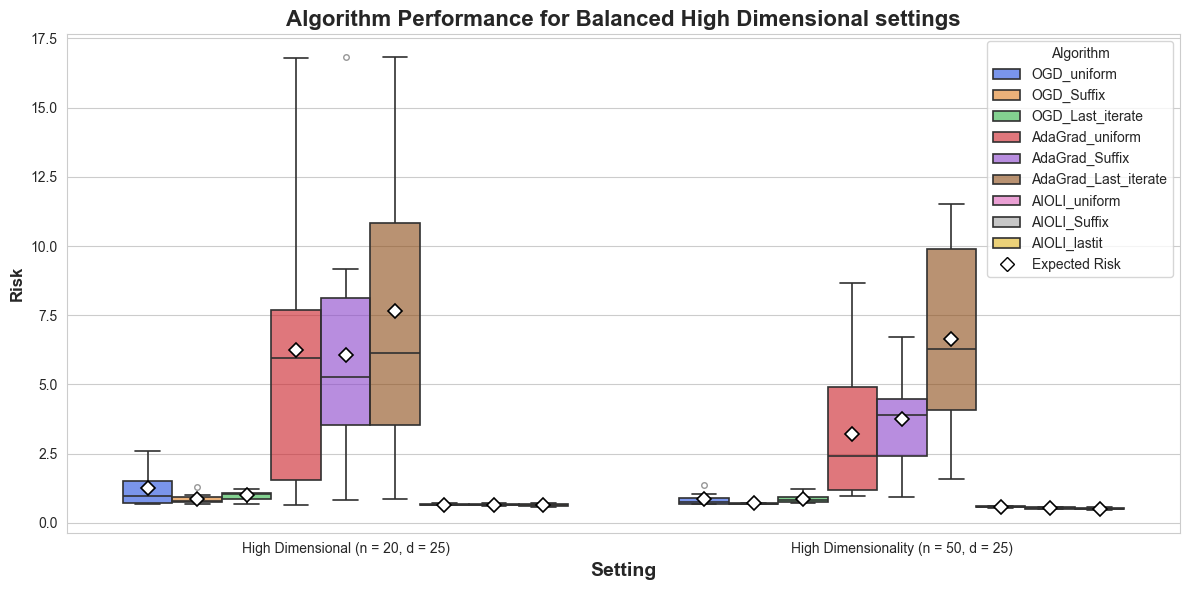

In [275]:
compare_settings(
    settings_results_HD,
    title = "Algorithm Performance for Balanced High Dimensional settings", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

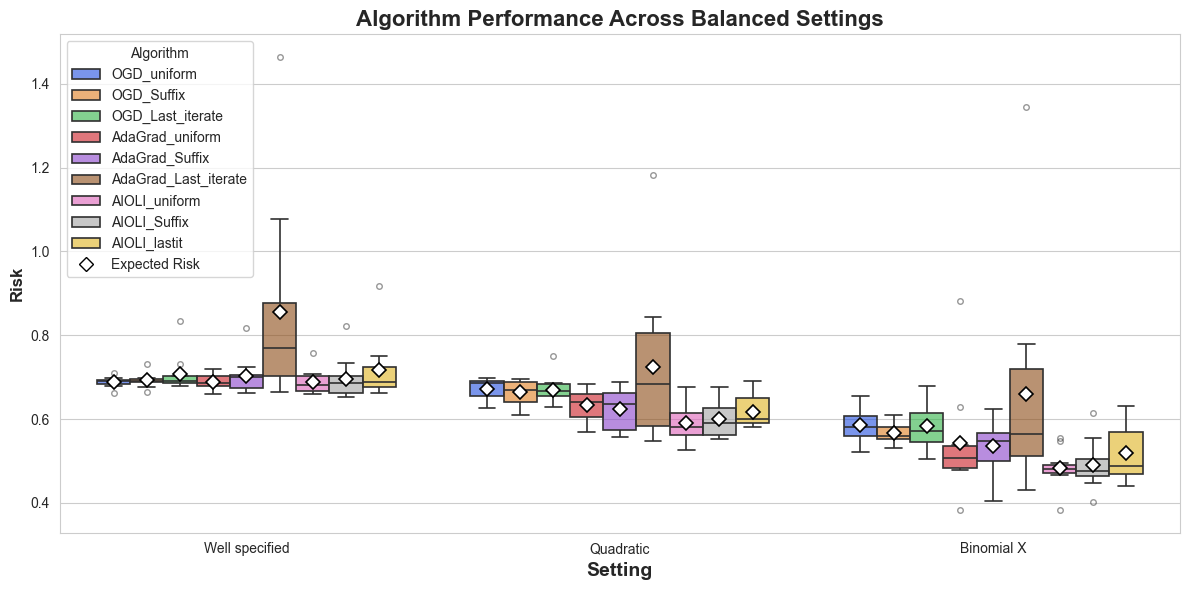

In [276]:
compare_settings(
    settings_results_wellspecified, selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"]
)

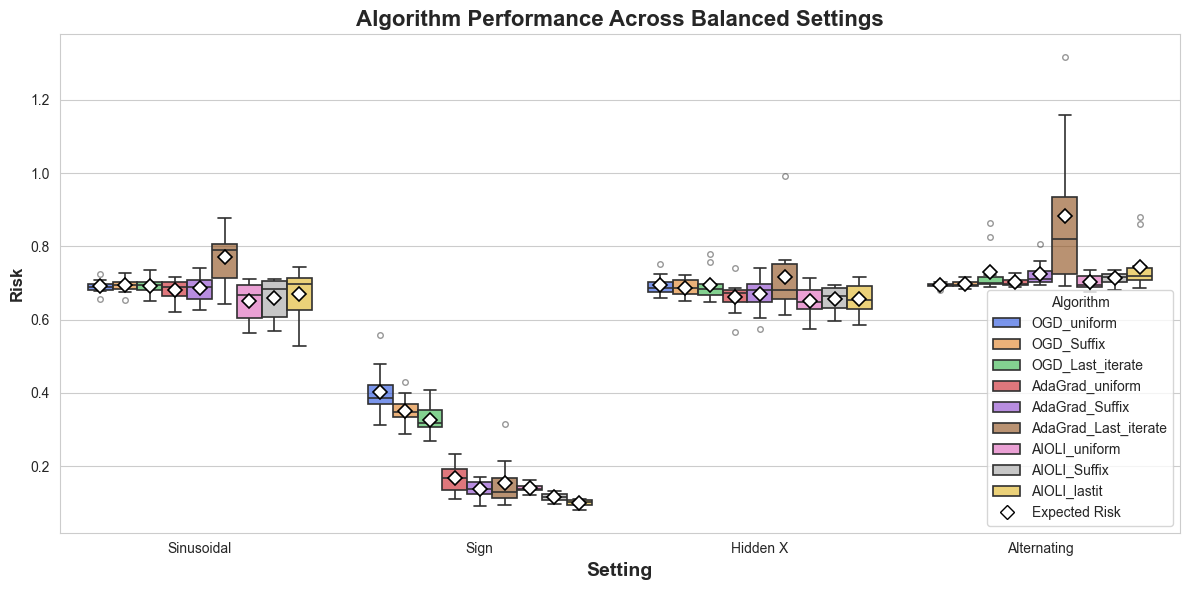

In [277]:
compare_settings(
    settings_results_misspecified, selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"]
)

### Plot risk results

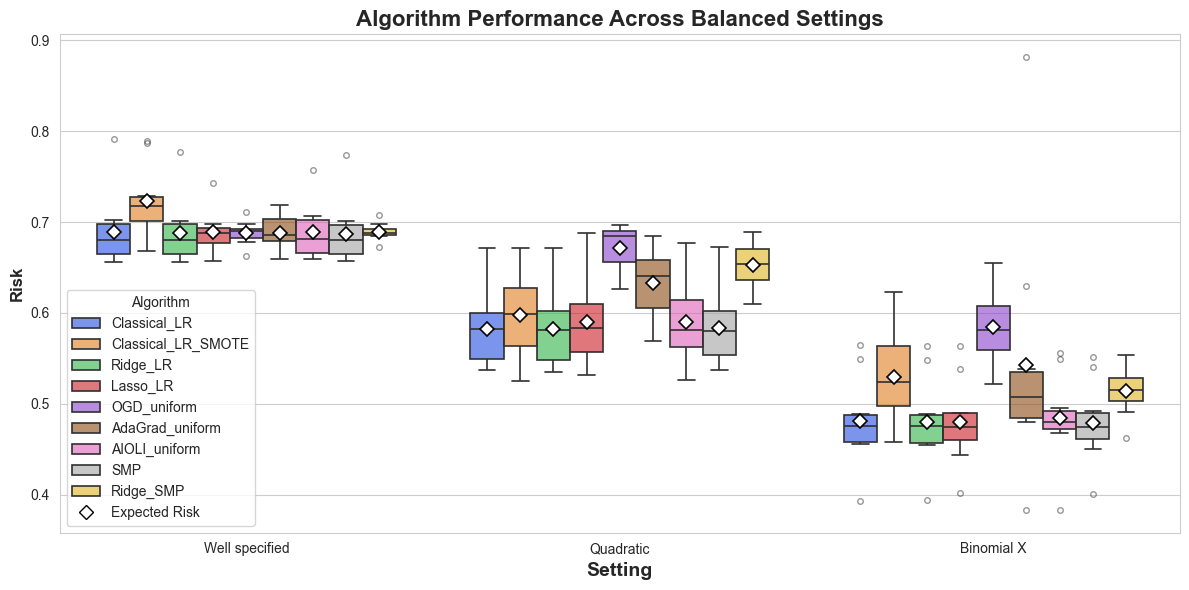

In [287]:
compare_settings(
    settings_results_wellspecified, selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP","Lasso_LR"]
)

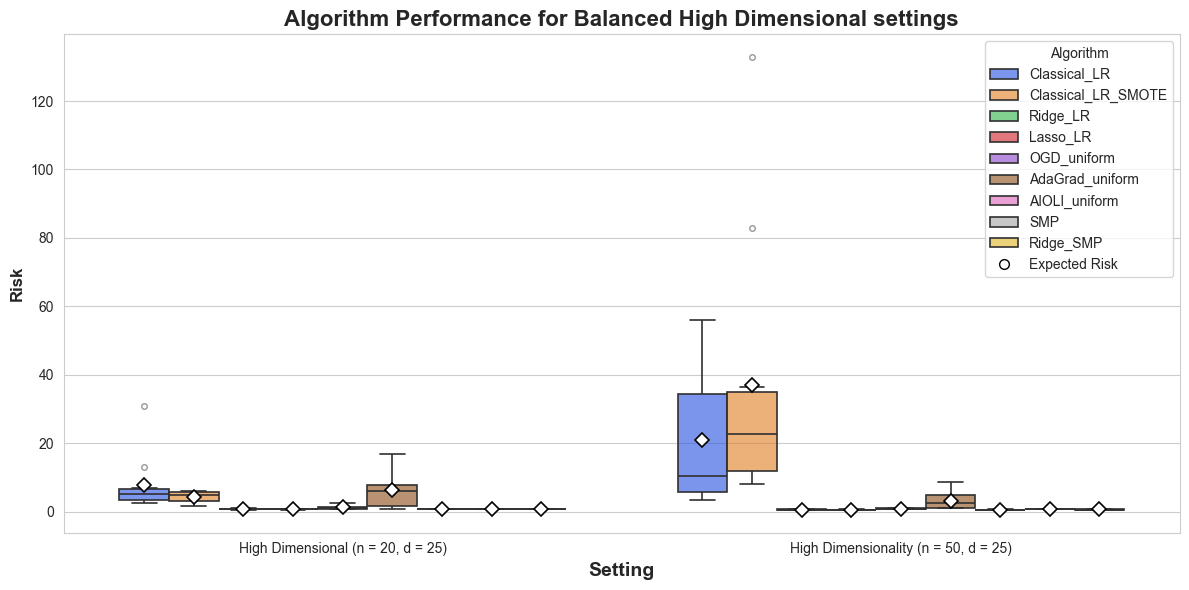

In [235]:
compare_settings(
    settings_results_HD,
    title = "Algorithm Performance for Balanced High Dimensional settings", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

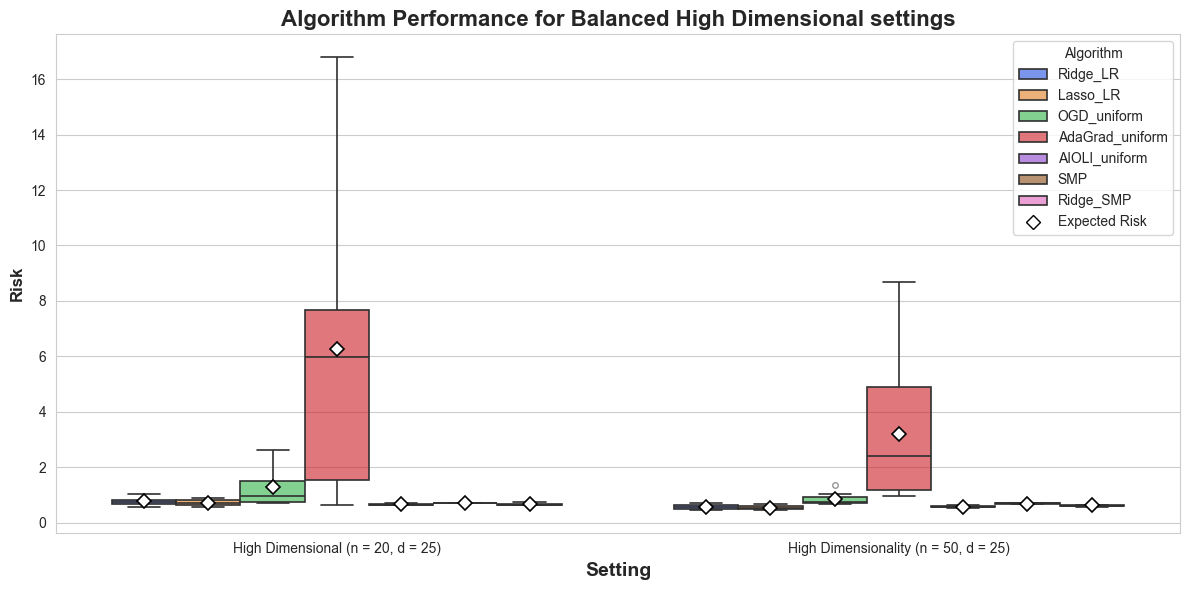

In [289]:
# All except LR
compare_settings(
    settings_results_HD,
    title="Algorithm Performance for Balanced High Dimensional settings",
    selected_algorithms=["Ridge_LR", "Lasso_LR", "OGD_uniform", "AdaGrad_uniform",
                         "AIOLI_uniform", "SMP", "Ridge_SMP"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)",
              "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

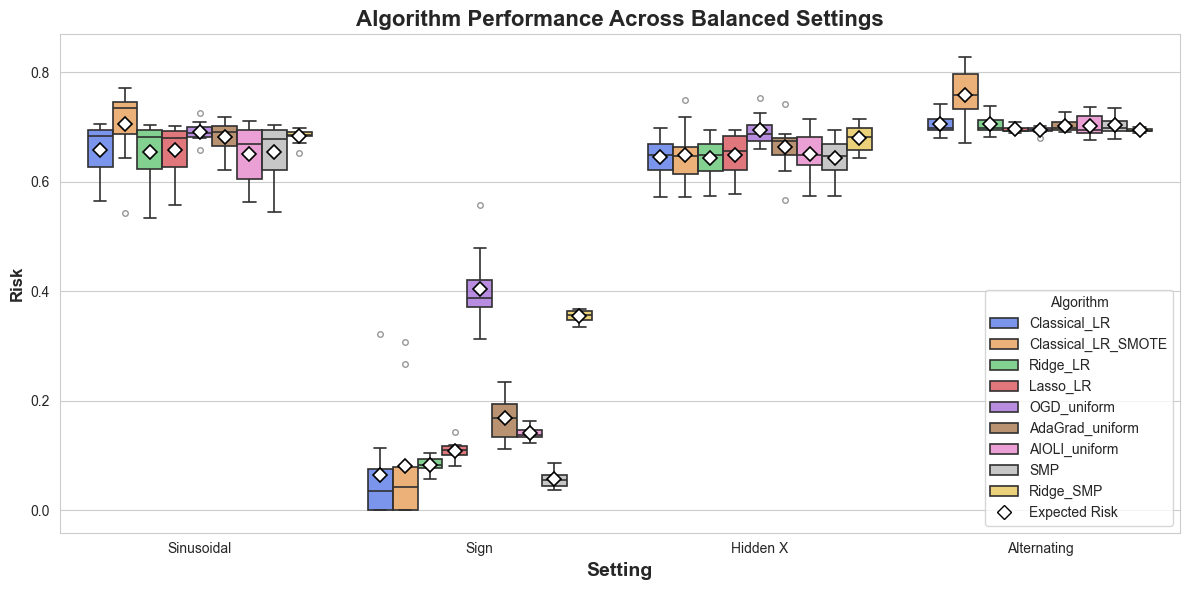

In [385]:
compare_settings(
    settings_results_misspecified, selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP","Lasso_LR"]
)

## Unbalanced

### Experiments

In [160]:
# Binomial
binomial_unbalanced = SimulationConfig(
    sim_setting = "binomial_x",
    n = 100,
    sim_balanced= False
)

binomial_unbalanced_result = run_simulation(binomial_unbalanced)
print_results(binomial_unbalanced_result)

100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.014.
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.016.
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.014.
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.013.
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025.
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.01.
Lasso LR was fit

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.0447052048,0.0085962880
AIOLI_lastit,0.0438083360,0.0115023879
AIOLI_uniform,0.0505730624,0.0079720872
AdaGrad_Last_iterate,0.0536393828,0.0179621363
AdaGrad_Suffix,0.0833119367,0.0373302084
AdaGrad_uniform,0.1135754631,0.0380193494
Classical_LR,0.0517350181,0.0168511111
Classical_LR_SMOTE,0.0474057820,0.0170203219
Lasso_LR,0.0360889437,0.0078440496



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2202914000,21.5829598000,21.8032512000,0.3813045608
AIOLI_lastit,0.2202914000,21.8500521000,22.0703435000,0.3494373927
AIOLI_uniform,0.2202914000,21.7560722000,21.9763636000,0.3851243103
AdaGrad_Last_iterate,0.0010272000,0.0000072000,0.0010344000,0.0000378501
AdaGrad_Suffix,0.0010272000,0.0000113000,0.0010385000,0.0000376723
AdaGrad_uniform,0.0010272000,0.0000192000,0.0010464000,0.0000371032
Classical_LR,0.0025341000,0.0000168000,0.0025509000,0.0003062339
Classical_LR_SMOTE,0.0023886000,0.0000092000,0.0023978000,0.0002067605
Lasso_LR,0.0068821000,0.0000080000,0.0068901000,0.0015866751


In [161]:
plot_results(binomial_unbalanced_result, n = 100)

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
-1     98     98     98     99     98     98     98     98     98   
 1      2      2      2      1      2      2      2      2      2   

           run_10  
-1 100.0000000000  
 1            NaN  
Test set
            run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
-1 100.0000000000     99     99     98     99     98     99     99     99   
 1            NaN      1      1      2      1      2      1      1      1   

           run_10  
-1 100.0000000000  
 1            NaN  


In [162]:
# Well specified
well_specified_unbalanced = SimulationConfig(
    sim_setting = "well specified",
    sim_balanced= False
)

well_specified_unbalanced_result = run_simulation(well_specified_unbalanced)
print_results(well_specified_unbalanced_result)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971.
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.984.
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.978.
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989.
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 4 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.986.
Lasso LR was fit manually
Run 5 finishe

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.0778745028,0.0096481768
AIOLI_lastit,0.0913966895,0.0150569310
AIOLI_uniform,0.0784823495,0.0086273263
AdaGrad_Last_iterate,0.1499247619,0.0553647134
AdaGrad_Suffix,0.0896330331,0.0155575490
AdaGrad_uniform,0.0977808237,0.0177130741
Classical_LR,0.1169532572,0.0305573171
Classical_LR_SMOTE,0.1356259599,0.0311252824
Lasso_LR,0.0792871729,0.0099473107



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2350092000,21.4757642000,21.7107734000,0.2459705097
AIOLI_lastit,0.2350092000,21.6181859000,21.8531951000,0.2138758267
AIOLI_uniform,0.2350092000,21.8101237000,22.0451329000,0.1943181214
AdaGrad_Last_iterate,0.0009619000,0.0000067000,0.0009686000,0.0000529281
AdaGrad_Suffix,0.0009619000,0.0000099000,0.0009718000,0.0000531135
AdaGrad_uniform,0.0009619000,0.0000106000,0.0009725000,0.0000530382
Classical_LR,0.0024523000,0.0000151000,0.0024674000,0.0002605387
Classical_LR_SMOTE,0.0023313000,0.0000094000,0.0023407000,0.0001588594
Lasso_LR,0.0131527000,0.0000079000,0.0131606000,0.0010099563


In [163]:
plot_results(well_specified_unbalanced_result)

Train set
    run_1  run_2  run_3          run_4  run_5  run_6  run_7  run_8  run_9  \
-1      5      1      4            NaN      2      3      2      2      3   
 1     95     99     96 100.0000000000     98     97     98     98     97   

    run_10  
-1       1  
 1      99  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6          run_7  run_8  run_9  \
-1      2      2      1      2      2      1            NaN      2      3   
 1     98     98     99     98     98     99 100.0000000000     98     97   

    run_10  
-1       1  
 1      99  


In [164]:
#Quadratic
quadratic_unbalanced = SimulationConfig(
    sim_setting = "quadratic",
    d = 3,
    sim_balanced= False
)

quadratic_unbalanced_result = run_simulation(quadratic_unbalanced)
print_results(quadratic_unbalanced_result)

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.876.
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.88.
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.872.
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.884.
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.884.
Lasso LR was fit manually
Run 5 finished
100 (training) samples w

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.1201348931,0.0176621415
AIOLI_lastit,0.1186001407,0.0167451347
AIOLI_uniform,0.1194863630,0.0170504974
AdaGrad_Last_iterate,0.1903417520,0.0500986102
AdaGrad_Suffix,0.1444369131,0.0296851693
AdaGrad_uniform,0.1615417816,0.0318727116
Classical_LR,0.2279782981,0.0792889810
Classical_LR_SMOTE,0.2547136716,0.0836874173
Lasso_LR,0.1139308258,0.0150451906



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2330228000,21.6332535000,21.8662763000,0.2961333669
AIOLI_lastit,0.2330228000,21.5892272000,21.8222500000,0.2750283339
AIOLI_uniform,0.2330228000,22.0919609000,22.3249837000,0.2801321321
AdaGrad_Last_iterate,0.0009906000,0.0000108000,0.0010014000,0.0000543959
AdaGrad_Suffix,0.0009906000,0.0000207000,0.0010113000,0.0000574135
AdaGrad_uniform,0.0009906000,0.0000175000,0.0010081000,0.0000551766
Classical_LR,0.0024966000,0.0000155000,0.0025121000,0.0002121345
Classical_LR_SMOTE,0.0033575000,0.0000092000,0.0033667000,0.0008656224
Lasso_LR,0.0170214000,0.0000161000,0.0170375000,0.0026555308


In [165]:
plot_results(quadratic_unbalanced_result)

Train set
            run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
-1 100.0000000000     92     99     98     97     98     99     96     94   
 1            NaN      8      1      2      3      2      1      4      6   

    run_10  
-1      96  
 1       4  
Test set
    run_1  run_2  run_3  run_4          run_5  run_6  run_7  run_8  run_9  \
-1     95     98     97     96 100.0000000000     98     99     98     95   
 1      5      2      3      4            NaN      2      1      2      5   

    run_10  
-1      97  
 1       3  


In [166]:
# High Dimensional
high_dimensional_unbalanced = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25,
    sim_balanced= False
)

high_dimensional_unbalanced_result = run_simulation(high_dimensional_unbalanced)
print_results(high_dimensional_unbalanced_result)


20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.902.
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.913.
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.866.
Lasso LR was fit manually
Run 3 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.912.
Lasso LR was fit manually
Run 4 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.931.
Lasso LR was fit manually
Run

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.3875794382,0.0193950260
AIOLI_lastit,0.3758780229,0.0217508768
AIOLI_uniform,0.4286917149,0.0168416026
AdaGrad_Last_iterate,3.5153679667,1.6783902012
AdaGrad_Suffix,4.8106044685,1.7699538771
AdaGrad_uniform,6.1387955711,1.6809469360
Classical_LR,0.9491646781,0.2254649658
Classical_LR_SMOTE,0.8877084542,0.2082382857
Lasso_LR,0.3185665482,0.0520502918



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.3787887000,35.1570145000,35.5358032000,0.8697542766
AIOLI_lastit,0.3787887000,35.2667035000,35.6454922000,0.9104303837
AIOLI_uniform,0.3787887000,35.3192546000,35.6980433000,0.8904749832
AdaGrad_Last_iterate,0.0009891000,0.0000117000,0.0010008000,0.0002252004
AdaGrad_Suffix,0.0009891000,0.0000181000,0.0010072000,0.0002251585
AdaGrad_uniform,0.0009891000,0.0000180000,0.0010071000,0.0002251556
Classical_LR,0.0022825000,0.0000149000,0.0022974000,0.0002329564
Classical_LR_SMOTE,0.0036708000,0.0000075000,0.0036783000,0.0005309617
Lasso_LR,0.1146278000,0.0000069000,0.1146347000,0.0080838429


In [167]:
plot_results(high_dimensional_unbalanced_result, n = 20)

Train set
    run_1         run_2  run_3  run_4  run_5  run_6         run_7  run_8  \
-1      1           NaN      1      3      1      1           NaN      4   
 1     19 20.0000000000     19     17     19     19 20.0000000000     16   

    run_9  run_10  
-1      1       2  
 1     19      18  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6          run_7  run_8  run_9  \
-1     12     12     14      9      6      8            NaN     10      8   
 1     88     88     86     91     94     92 100.0000000000     90     92   

    run_10  
-1       7  
 1      93  


In [168]:
# High dimensionality
high_dimensionality_unbalanced = SimulationConfig(
    sim_setting = "high dimensional",
    n = 50,
    d = 25,
    sim_balanced = False
)

high_dimensionality_unbalanced_result = run_simulation(high_dimensionality_unbalanced)
print_results(high_dimensionality_unbalanced_result)


50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.899.
Lasso LR was fit manually
Run 1 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.921.
Lasso LR was fit manually
Run 2 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.876.
Lasso LR was fit manually
Run 3 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.913.
Lasso LR was fit manually
Run 4 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.935.
Lasso LR was fit manually
Run 5 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an aver

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.3426943649,0.0220487457
AIOLI_lastit,0.3258013127,0.0224213329
AIOLI_uniform,0.3821415433,0.0186199939
AdaGrad_Last_iterate,3.2246511749,0.7947983637
AdaGrad_Suffix,2.3451500456,0.6359588146
AdaGrad_uniform,3.8635648751,0.9567739914
Classical_LR,2.5615144443,0.6048961895
Classical_LR_SMOTE,3.4876835744,0.9904816103
Lasso_LR,0.2819058630,0.0358122463



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,1.3845218000,130.6323967000,132.0169185000,3.8096992269
AIOLI_lastit,1.3845218000,130.5105466000,131.8950684000,3.8313550822
AIOLI_uniform,1.3845218000,130.6041099000,131.9886317000,3.9174173352
AdaGrad_Last_iterate,0.0020742000,0.0000066000,0.0020808000,0.0002051794
AdaGrad_Suffix,0.0020742000,0.0000102000,0.0020844000,0.0002051133
AdaGrad_uniform,0.0020742000,0.0000112000,0.0020854000,0.0002051213
Classical_LR,0.0030862000,0.0000138000,0.0031000000,0.0002639741
Classical_LR_SMOTE,0.0037743000,0.0000079000,0.0037822000,0.0002252456
Lasso_LR,0.1002439000,0.0000069000,0.1002508000,0.0083074265


In [169]:
plot_results(high_dimensionality_unbalanced_result, n =50)

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
 1     44     48     47     44     48     49     49     40     48      47
-1      6      2      3      6      2      1      1     10      2       3
Test set
    run_1  run_2  run_3  run_4  run_5  run_6          run_7  run_8  run_9  \
-1     12     12     14      9      6      8            NaN     10      8   
 1     88     88     86     91     94     92 100.0000000000     90     92   

    run_10  
-1       7  
 1      93  


In [170]:
# Sign
sign_unbalanced = SimulationConfig(
    sim_setting = "sign",
    n = 100,
    sim_balanced = False
)

sign_unbalanced_result = run_simulation(sign_unbalanced)
print_results(sign_unbalanced_result)

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.98
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 6 finished
100 (training) sa

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.0706693924,0.0090337555
AIOLI_lastit,0.0664280816,0.0086323792
AIOLI_uniform,0.0841250724,0.0092942622
AdaGrad_Last_iterate,0.0927351386,0.0198957229
AdaGrad_Suffix,0.1049743792,0.0224943565
AdaGrad_uniform,0.1143769040,0.0206543118
Classical_LR,0.1632169283,0.0974362682
Classical_LR_SMOTE,0.1395476636,0.0876451685
Lasso_LR,0.0690179516,0.0083010278



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.1645521000,15.0570900000,15.2216421000,0.2509644282
AIOLI_lastit,0.1645521000,15.0738183000,15.2383704000,0.2079360053
AIOLI_uniform,0.1645521000,15.1820235000,15.3465756000,0.2380881504
AdaGrad_Last_iterate,0.0011181000,0.0000064000,0.0011245000,0.0002054818
AdaGrad_Suffix,0.0011181000,0.0000100000,0.0011281000,0.0002055028
AdaGrad_uniform,0.0011181000,0.0000103000,0.0011284000,0.0002054930
Classical_LR,0.0021885000,0.0000133000,0.0022018000,0.0003032408
Classical_LR_SMOTE,0.0021431000,0.0000085000,0.0021516000,0.0002682511
Lasso_LR,0.0123736000,0.0000080000,0.0123816000,0.0017846178


In [171]:
plot_results(sign_unbalanced_result)

Train set
               run_1  run_2  run_3  run_4  run_5  run_6          run_7  run_8  \
-1.0000000000      2      2      1      1      2      2            NaN      4   
1.0000000000      98     98     99     99     98     98 100.0000000000     96   

               run_9  run_10  
-1.0000000000      1       2  
1.0000000000      99      98  
Test set
               run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  \
1.0000000000      97     98     96     96     97     97     92     97     97   
-1.0000000000      3      2      4      4      3      3      8      3      3   

               run_10  
1.0000000000       95  
-1.0000000000       5  


In [288]:
# Alternating
alternating_unbalanced = SimulationConfig(
    sim_setting = "alternating",
    n = 100,
    sim_balanced = False
)

alternating_unbalanced_result = run_simulation(alternating_unbalanced)
print_results(alternating_unbalanced_result)

100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.005
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
100 (training) samples were generated in the alternating unbalanced setting. Using 3 variable(s), with an aver

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.0680950434,0.0155859494
AIOLI_lastit,0.0649864285,0.0153948963
AIOLI_uniform,0.0695359574,0.0145998644
AdaGrad_Last_iterate,0.0673720124,0.0205165021
AdaGrad_Suffix,0.0713773092,0.0222284036
AdaGrad_uniform,0.0739866526,0.0236754579
Classical_LR,0.1041928956,0.0340645139
Classical_LR_SMOTE,0.1134715069,0.0332270246
Lasso_LR,0.0568579137,0.0141124431



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.4240036000,28.4952839000,28.9192875000,1.1215194891
AIOLI_lastit,0.4240036000,29.4874631000,29.9114667000,1.6622509283
AIOLI_uniform,0.4240036000,28.5283006000,28.9523042000,0.5875517408
AdaGrad_Last_iterate,0.0018329000,0.0000154000,0.0018483000,0.0005183574
AdaGrad_Suffix,0.0018329000,0.0000301000,0.0018630000,0.0005234595
AdaGrad_uniform,0.0018329000,0.0000263000,0.0018592000,0.0005195455
Classical_LR,0.0215680000,0.0007170000,0.0222850000,0.0144304601
Classical_LR_SMOTE,0.0059580000,0.0000125000,0.0059705000,0.0011304825
Lasso_LR,0.0486911000,0.0000375000,0.0487286000,0.0117813330


In [351]:
plot_results(alternating_unbalanced_result)

Train set
            run_1          run_2          run_3  run_4  run_5  run_6  \
-1 100.0000000000 100.0000000000 100.0000000000     98     99     99   
 1            NaN            NaN            NaN      2      1      1   

            run_7  run_8  run_9  run_10  
-1 100.0000000000     99     98      98  
 1            NaN      1      2       2  
Test set
            run_1          run_2  run_3  run_4          run_5  run_6  run_7  \
-1 100.0000000000 100.0000000000     99     97 100.0000000000     98     98   
 1            NaN            NaN      1      3            NaN      2      2   

            run_8  run_9  run_10  
-1 100.0000000000     99      99  
 1            NaN      1       1  


In [172]:
# Hidden X
hidden_x_unbalanced = SimulationConfig(
    sim_setting = "hidden x",
    n = 100,
    sim_balanced = False
)

hidden_x_unbalanced_result = run_simulation(hidden_x_unbalanced)
print_results(hidden_x_unbalanced_result)

100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.895.
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.919.
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.868.
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.911.
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.933.
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the hidden x unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.903.
Lasso LR was fit manu

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.2883353469,0.0289309168
AIOLI_lastit,0.2884984580,0.0319705927
AIOLI_uniform,0.2778265334,0.0288528048
AdaGrad_Last_iterate,0.3188141212,0.0416689914
AdaGrad_Suffix,0.3031056888,0.0375367041
AdaGrad_uniform,0.3344835394,0.0480463560
Classical_LR,0.2807583174,0.0306641303
Classical_LR_SMOTE,0.3000412757,0.0331170412
Lasso_LR,0.2778274161,0.0309967929



 Time Results (seconds) 


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.2375454000,23.7583979000,23.9959433000,0.5627661004
AIOLI_lastit,0.2375454000,23.4032341000,23.6407795000,0.4538572436
AIOLI_uniform,0.2375454000,23.9544448000,24.1919902000,0.5104250093
AdaGrad_Last_iterate,0.0009371000,0.0000089000,0.0009460000,0.0000386399
AdaGrad_Suffix,0.0009371000,0.0000136000,0.0009507000,0.0000386310
AdaGrad_uniform,0.0009371000,0.0000144000,0.0009515000,0.0000387672
Classical_LR,0.0024666000,0.0000162000,0.0024828000,0.0001834808
Classical_LR_SMOTE,0.0022341000,0.0000089000,0.0022430000,0.0002043703
Lasso_LR,0.0117490000,0.0000073000,0.0117563000,0.0019320626


In [173]:
plot_results(hidden_x_unbalanced_result)

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
 1     85     94     88     88     97     97     98     86     88      89
-1     15      6     12     12      3      3      2     14     12      11
Test set
    run_1  run_2  run_3  run_4  run_5  run_6          run_7  run_8  run_9  \
-1     12     12     14      9      6      8            NaN     10      8   
 1     88     88     86     91     94     92 100.0000000000     90     92   

    run_10  
-1       7  
 1      93  


In [349]:
#Graph groups
settings_unbalanced_results_wellspecified = {
    "Well specified": well_specified_unbalanced_result,
    "Quadratic": quadratic_unbalanced_result,
    "Binomial X": binomial_unbalanced_result
}

settings_unbalanced_results_misspecified = {
    "Sign" : sign_unbalanced_result,
    "Hidden X" : hidden_x_unbalanced_result,
    "Alternating":alternating_unbalanced_result
}

settings_unbalanced_results_HD = {
    "High Dimensional": high_dimensional_unbalanced_result,
    "High Dimensionality": high_dimensionality_unbalanced_result,
}

### Plots for averaging strategies

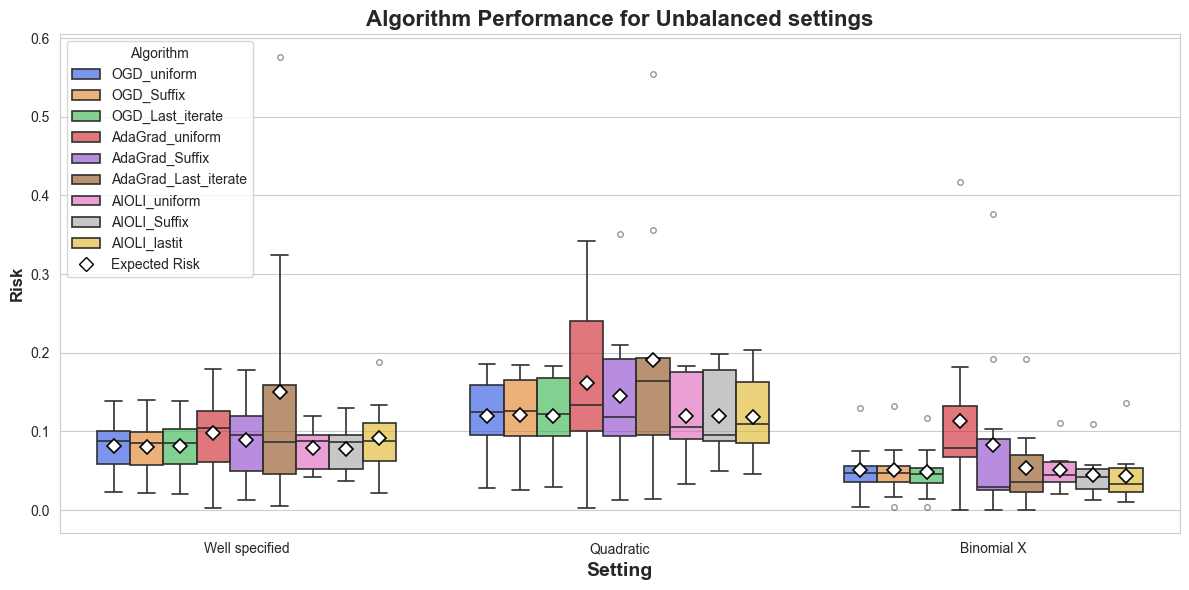

In [278]:

compare_settings(
    settings_unbalanced_results_wellspecified,
    title = "Algorithm Performance for Unbalanced settings", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"]
)

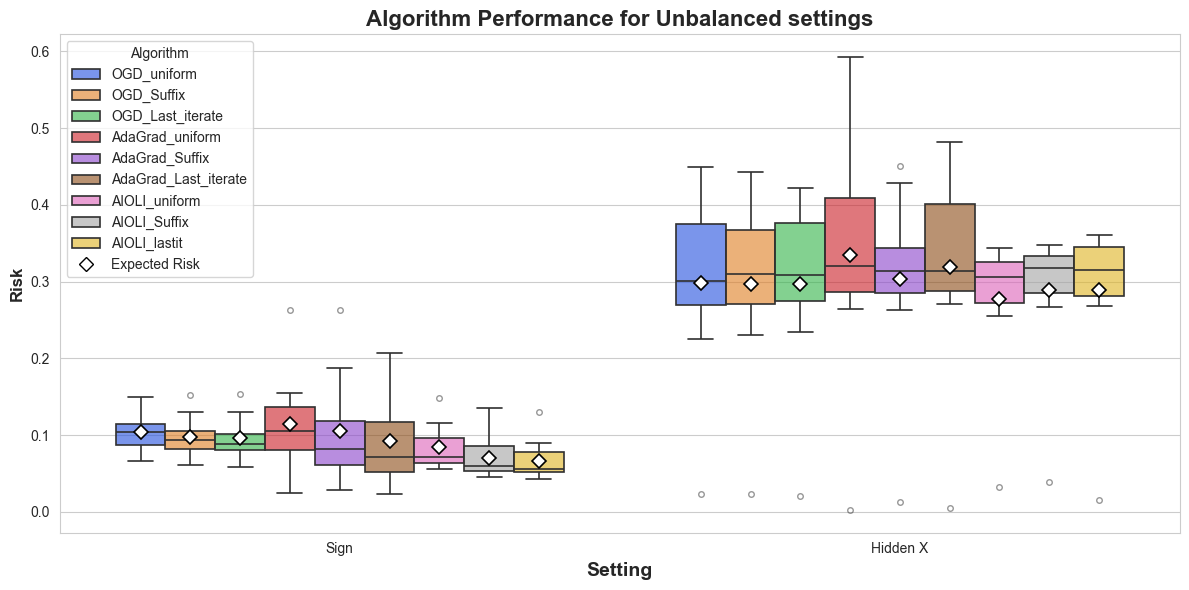

In [279]:

compare_settings(
    settings_unbalanced_results_misspecified,
    title = "Algorithm Performance for Unbalanced settings", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"]
)

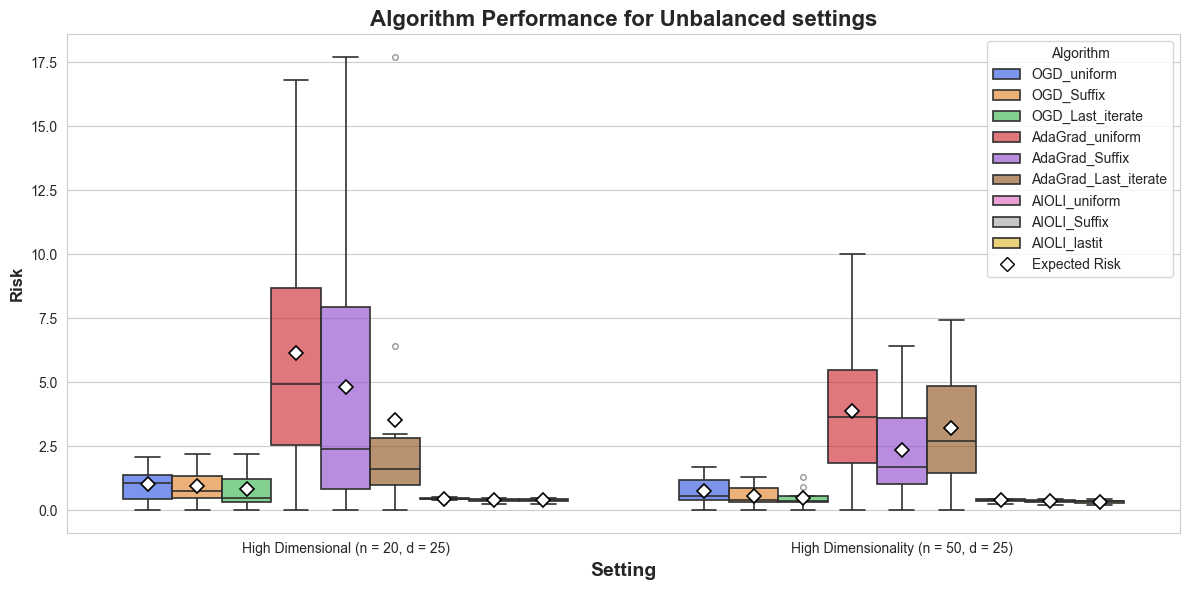

In [282]:

compare_settings(
    settings_unbalanced_results_HD,
    title = "Algorithm Performance for Unbalanced settings", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

### General Risk Results

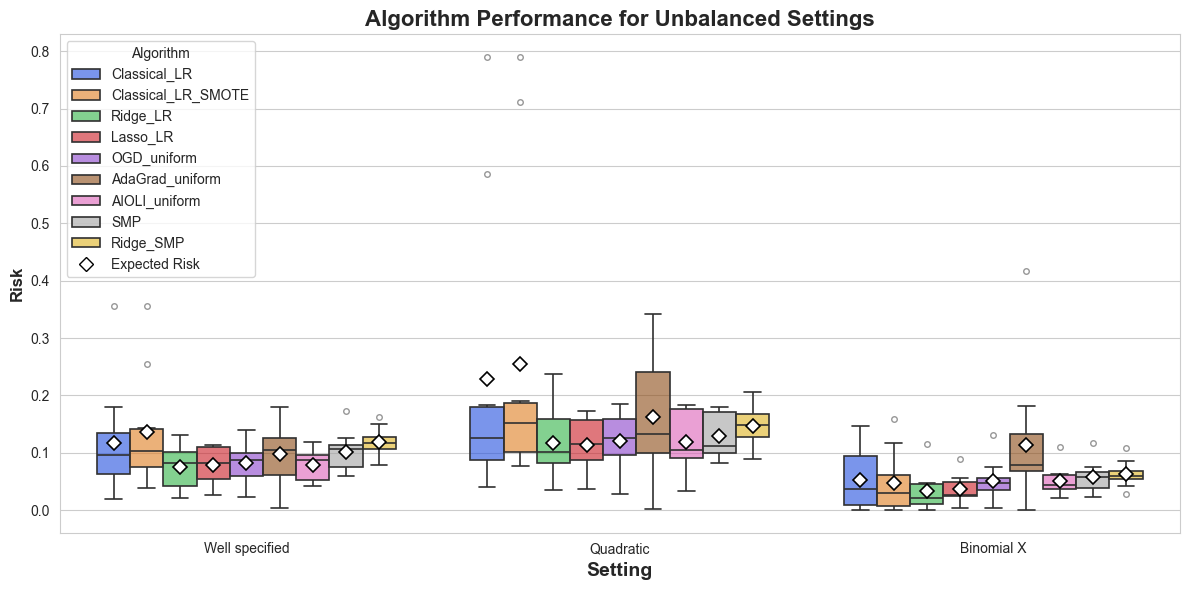

In [283]:
compare_settings(
    settings_unbalanced_results_wellspecified,
    title = "Algorithm Performance for Unbalanced Settings", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Lasso_LR","Ridge_LR","OGD_uniform","AIOLI_uniform","SMP","Ridge_SMP", "AdaGrad_uniform"]
)

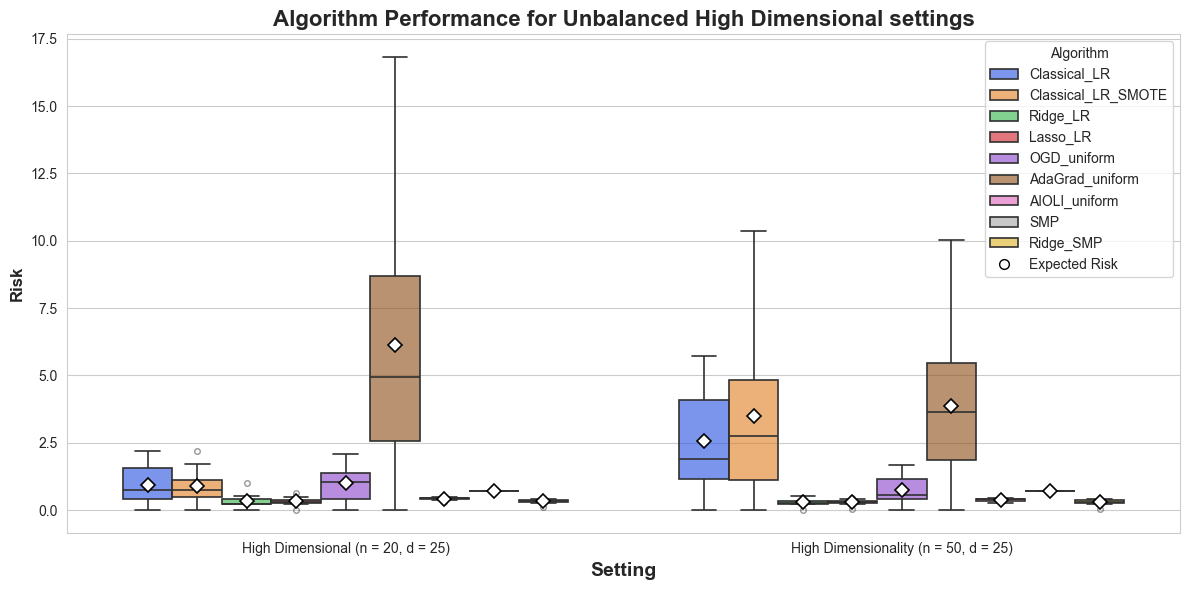

In [242]:
compare_settings(
    settings_unbalanced_results_HD,
    title = "Algorithm Performance for Unbalanced High Dimensional settings", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

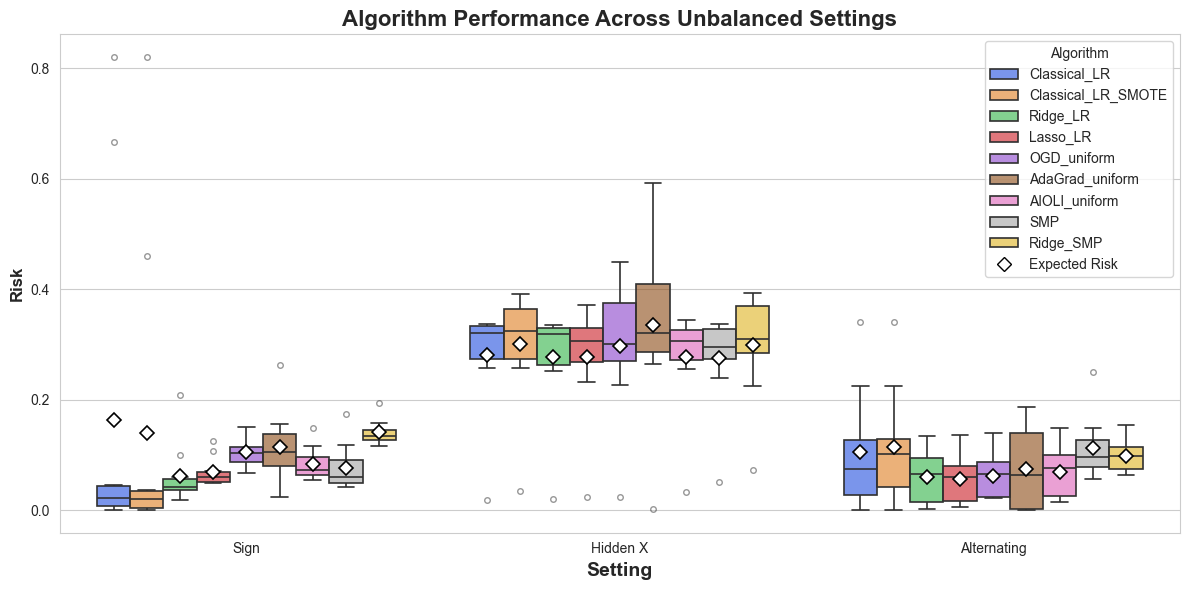

In [350]:
compare_settings(
    settings_unbalanced_results_misspecified,
    title = "Algorithm Performance Across Unbalanced Settings", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Lasso_LR","Ridge_LR","OGD_uniform","AIOLI_uniform","SMP","Ridge_SMP", "AdaGrad_uniform"]
)

## Changing n

In [181]:
hazan_changing_n = simulations_changing_n([20,50,100,200,300], hazan, filename = "hazan_changing_n")


Running simulations for n = 20

20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.0600000000

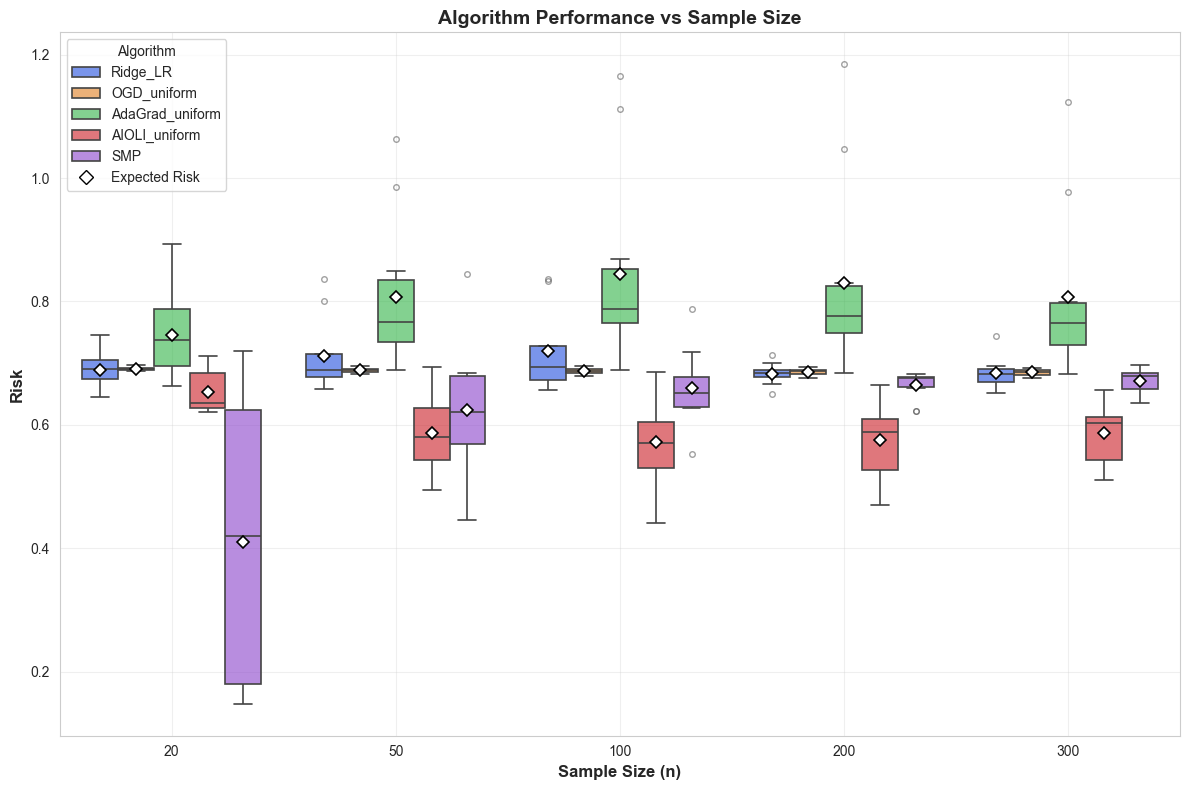

In [264]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform"] ,raw_data= hazan_changing_n[1])

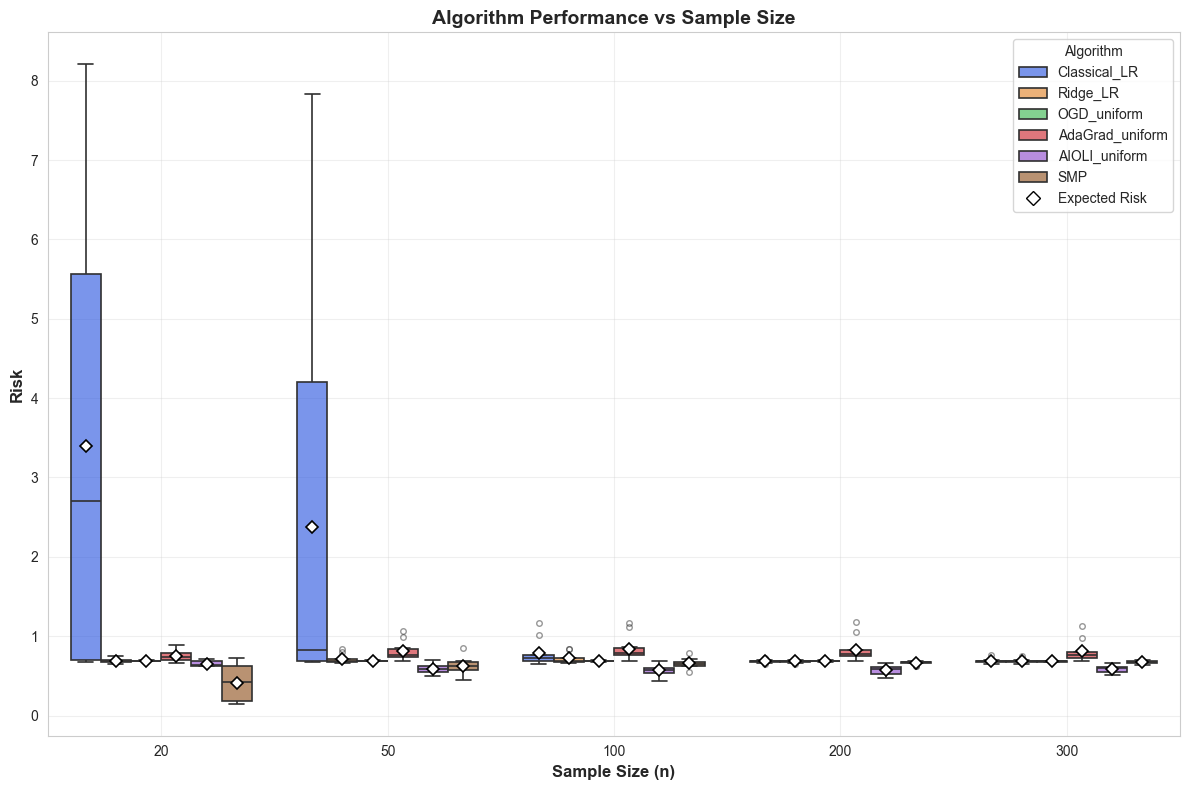

In [265]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform", "Classical_LR"] ,raw_data= hazan_changing_n[1])

In [184]:
hazanLR = hazan_changing_n[1]
hazanLR[hazanLR["algorithm"] == "Classical_LR"]

,run,algorithm,loss,n
0,1,Classical_LR,0.6700566728,20
15,2,Classical_LR,4.6900754552,20
30,3,Classical_LR,5.8625932282,20
45,4,Classical_LR,8.2076287742,20
60,5,Classical_LR,4.6900754552,20
75,6,Classical_LR,7.0351110012,20
90,7,Classical_LR,0.7141111534,20
105,8,Classical_LR,0.7023394768,20
120,9,Classical_LR,0.7023394768,20
135,10,Classical_LR,0.7023394768,20


In [185]:
# high_dimensional_changing_n = simulations_changing_n([10,75,100,125,150,175], high_dimensional, filename = "high_dimensional_changing_n", high_dimensional_analysis=True)

Running simulations for n = 10

10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.509.
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.494.
Lasso LR was fit manually
Run 2 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.504.
Lasso LR was fit manually
Run 3 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.569.
Dataset is balanced
Lasso LR was fit manually
Run 4 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.537.
Lasso LR was fit manually
Run 5 finished
10 (training) samples were generated in the high dime

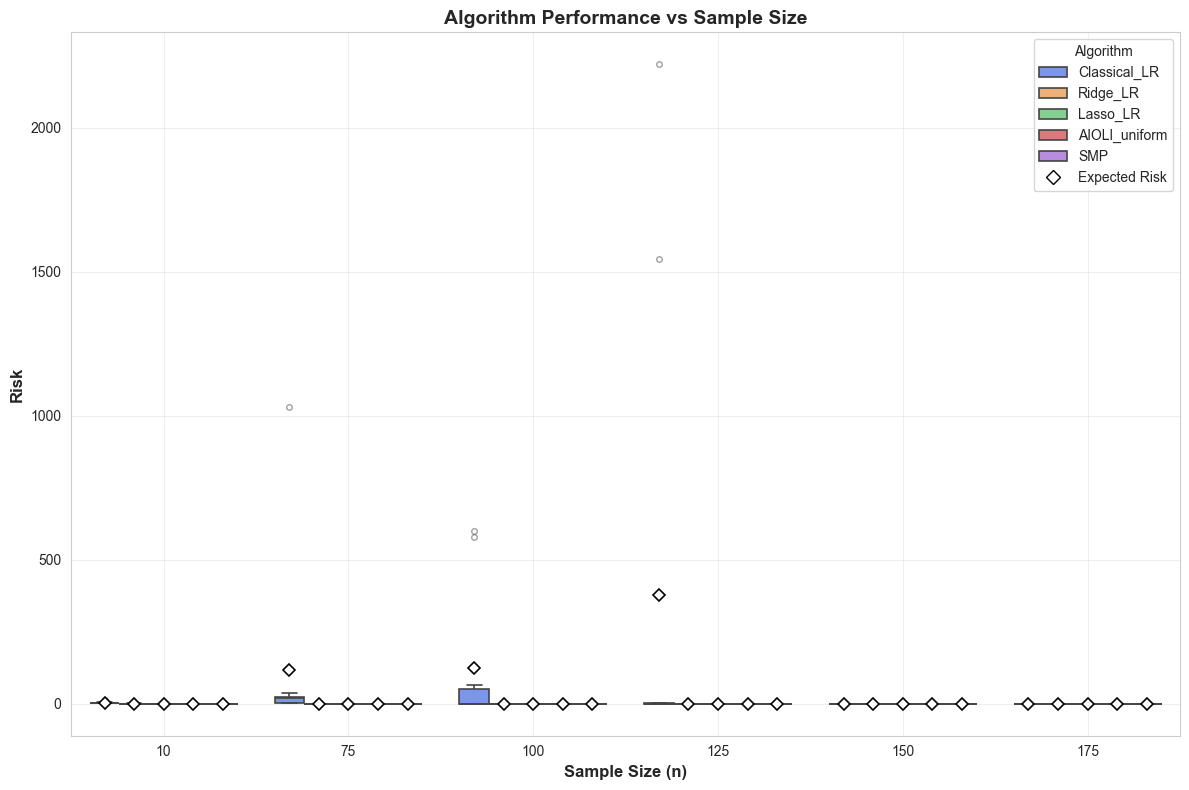

In [266]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR","AdaGrad_uniform","OGD_uniform", "Classical_LR"] ,raw_data= high_dimensional_changing_n[1])

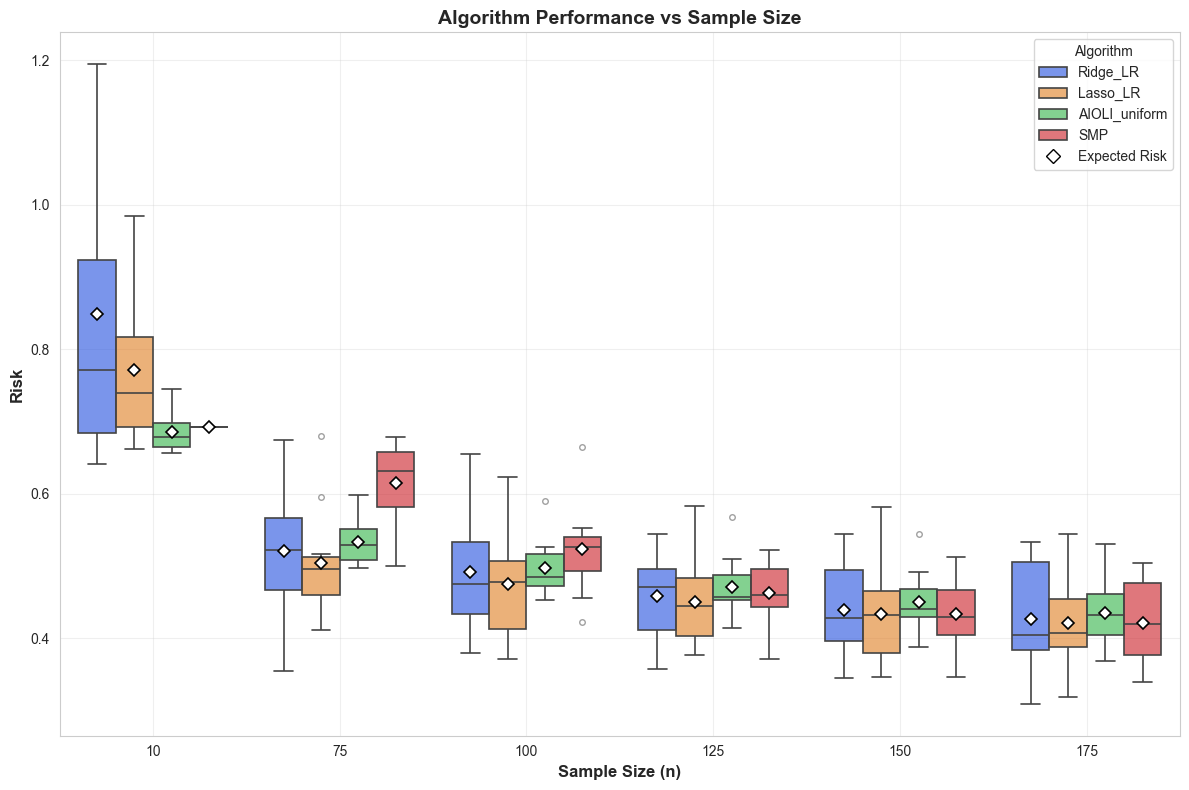

In [267]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR"] ,raw_data= high_dimensional_changing_n[1])

In [188]:
hd_n20 = high_dimensional_result["test_results"]
hd_n20["n"] = 20
hd_n50 = high_dimensionality_result["test_results"]
hd_n50["n"] = 50
hd_all_n =  pd.concat([high_dimensional_changing_n[1], hd_n20,hd_n50], ignore_index=True)
hd_all_n = hd_all_n.sort_values("n")

In [189]:
hd_all_n.to_csv("hd_all_n.csv")

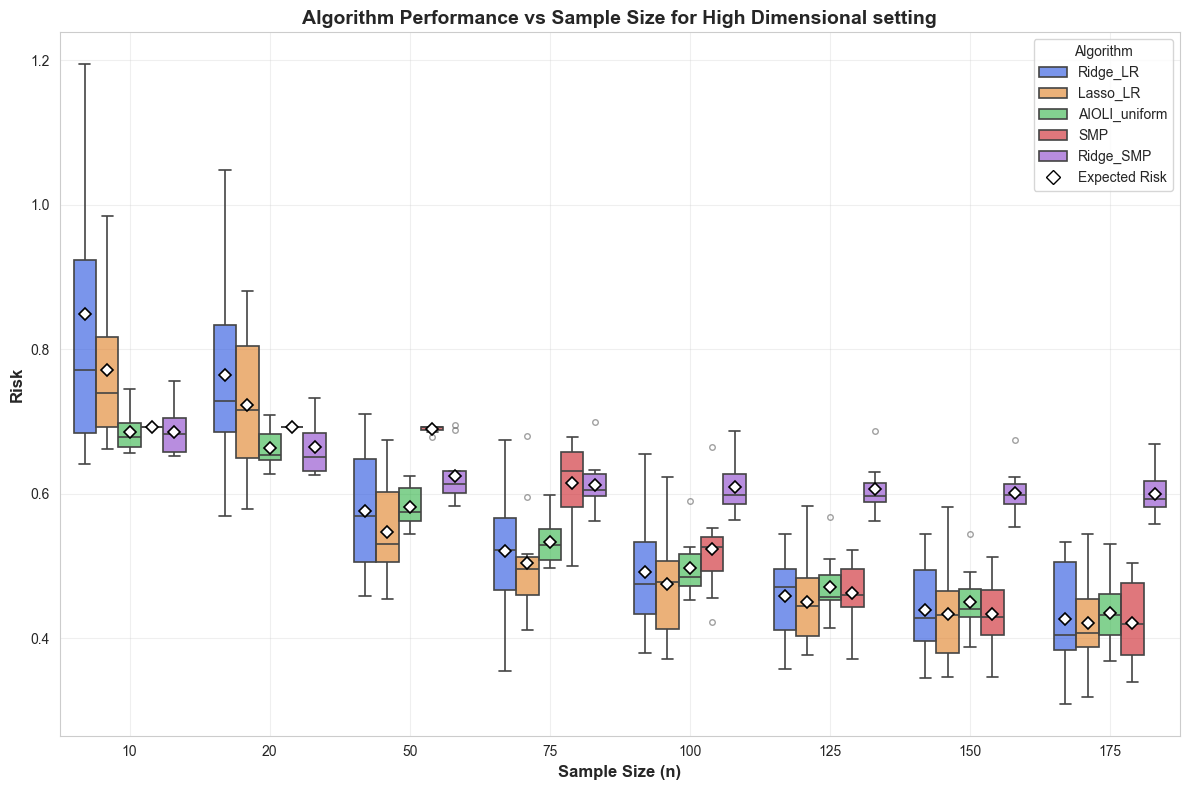

In [346]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR","Ridge_SMP"] ,raw_data= hd_all_n, title = "Algorithm Performance vs Sample Size for High Dimensional setting")

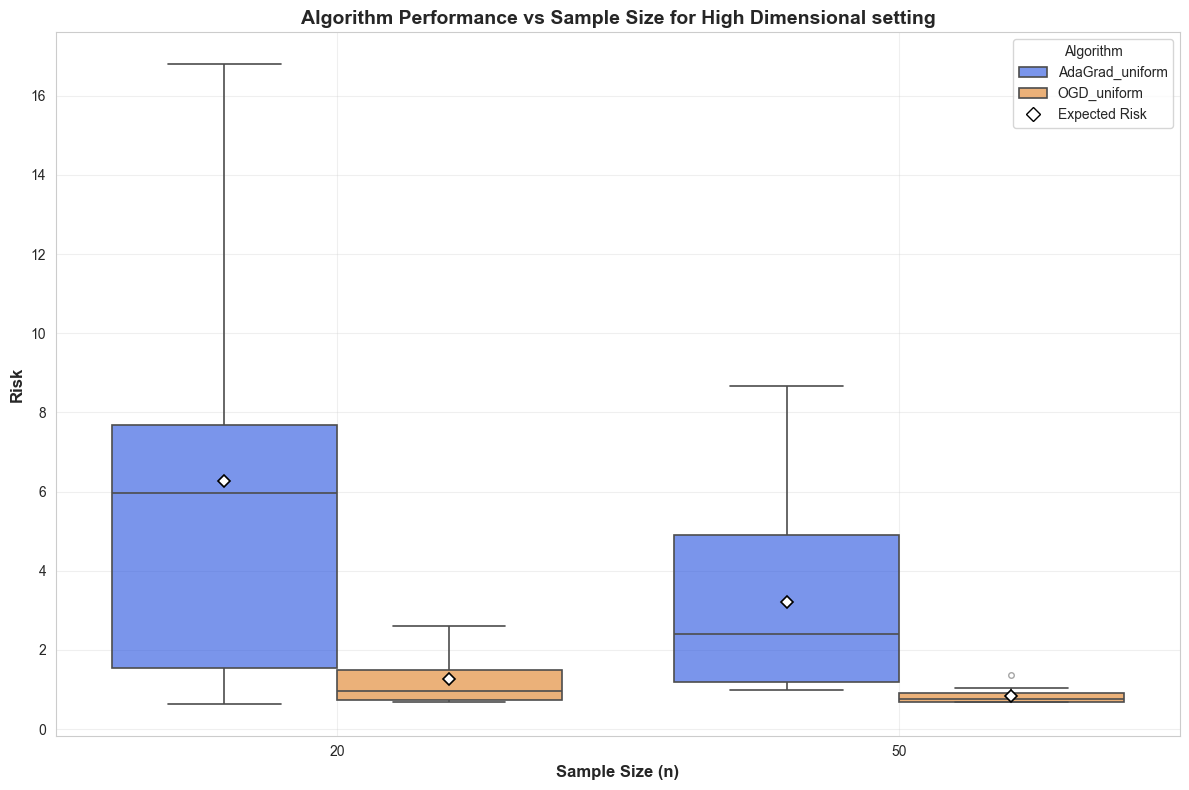

In [269]:
plot_simulation_results(algorithms = ["OGD_uniform","AdaGrad_uniform"] ,raw_data= hd_all_n, title = "Algorithm Performance vs Sample Size for High Dimensional setting")

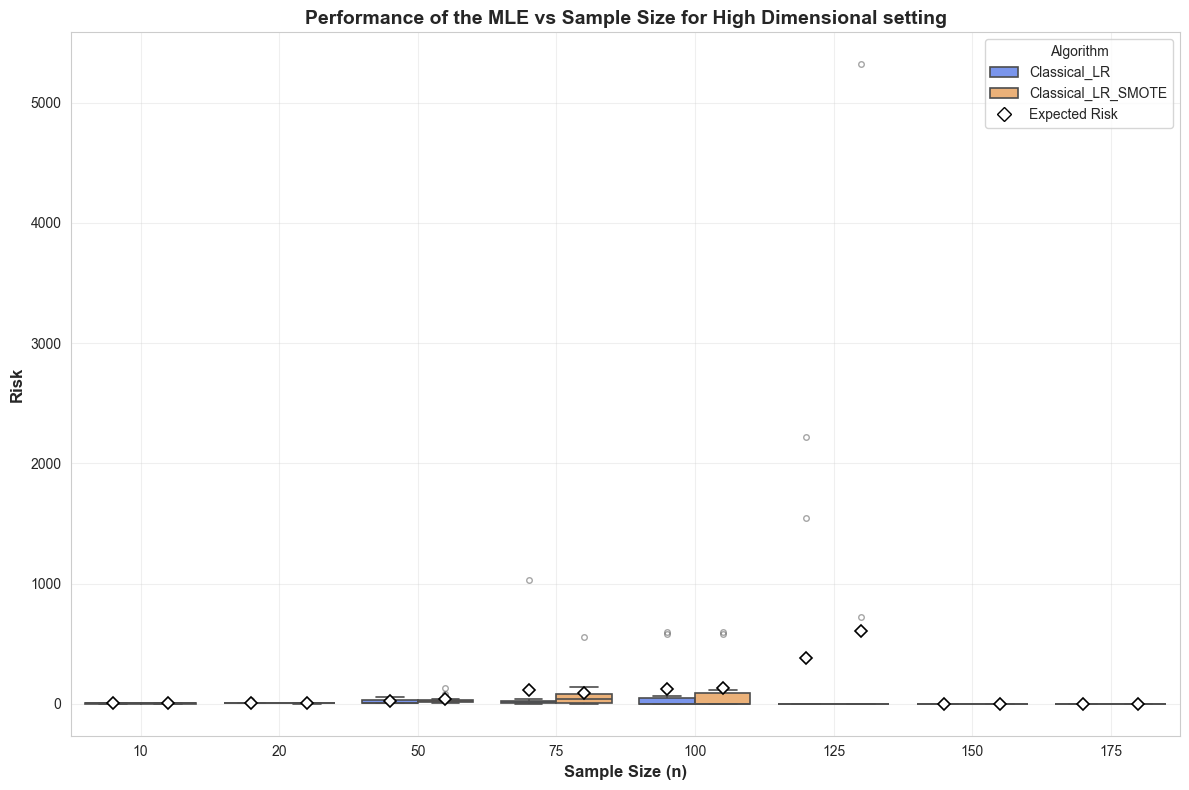

In [270]:
plot_simulation_results(algorithms = ["Classical_LR","Classical_LR_SMOTE"] ,raw_data= hd_all_n, title = "Performance of the MLE vs Sample Size for High Dimensional setting")

In [254]:
HD_LR = hd_all_n[hd_all_n["algorithm"] == "Classical_LR"]

In [255]:
summary_HD_LR = (
    HD_LR
    .groupby("n")["loss"]
    .agg(["mean", "median", "std", "min", "max",
         lambda x: x.quantile(0.25),
         lambda x: x.quantile(0.75)])
)
summary_HD_LR.columns = ["mean", "median", "std", "min", "max", "Q25","Q75"]

In [256]:
summary_HD_LR

,mean,median,std,min,max,Q25,Q75
n,,,,,,,
10,4.4818618993,4.0755161958,3.5377993956,1.7857019499,13.7612630003,2.0793110336,4.6260814246
20,7.9199538214,5.0550292422,8.6594778117,2.4687117162,30.9293835625,3.4083708926,6.7087613332
50,20.8518652308,10.4794975616,19.2318685799,3.4613854834,55.8823801123,5.7320671066,34.3741033454
75,116.7747227992,18.9031160320,321.5122033507,1.3292814724,1031.1196737098,3.1714102287,24.5216476248
100,125.8570389311,0.9709309085,245.1627565386,0.5691197394,598.1620595519,0.8584412533,51.3600378268
125,376.9884763218,0.6448128488,809.0596163662,0.4140345735,2219.5237402756,0.5605907615,1.3719123382
150,0.6300953444,0.5587041150,0.2346736332,0.3975776248,1.2003012495,0.5119898346,0.6945303101
175,0.5126881824,0.4939572114,0.1462421538,0.3465088835,0.8529491476,0.4325978553,0.5646847900


In [257]:
HD_LR_SMOTE = hd_all_n[hd_all_n["algorithm"] == "Classical_LR_SMOTE"]
summary_HD_LR_SMOTE = (
    HD_LR_SMOTE
    .groupby("n")["loss"]
    .agg(["mean", "median", "std", "min", "max",
         lambda x: x.quantile(0.25),
         lambda x: x.quantile(0.75)])
)
summary_HD_LR_SMOTE.columns = ["mean", "median", "std", "min", "max", "Q25","Q75"]
summary_HD_LR_SMOTE

,mean,median,std,min,max,Q25,Q75
n,,,,,,,
10,3.0323516597,2.9399085429,1.2173147930,1.7857019499,5.6227077825,2.1441643524,3.6593101993
20,4.3613438617,4.7855688082,1.5235812671,1.7594389706,6.0276736725,3.1131377483,5.7303949979
50,36.9109960728,22.6942249477,40.3173445928,7.9340024497,132.8366599662,11.8040984929,34.9111863406
75,93.0273481030,38.4032798079,167.8672030526,1.4870110152,553.9455583886,5.4554352707,83.8367501773
100,131.4831279315,1.0796929130,244.0581557168,0.5749458728,598.1620595519,0.8941257641,91.3981762096
125,604.5283413712,0.6808537896,1672.1033460661,0.4217482546,5319.7892007054,0.5871066481,1.5226852483
150,0.6424162226,0.5732871983,0.2560464369,0.3975776248,1.2458082657,0.4718661269,0.6997741516
175,0.5231030417,0.4911669446,0.1558792329,0.3489655865,0.8996862577,0.4334854635,0.5792959681


In [197]:
a,b,c,d = generate_data("high dimensional", balanced = True, n = 125,seed = 48)
print(sum(b == 1)/len(b))
print(sum(d == 1)/len(d))

125 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.493.
0.576
0.44


In [198]:
logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=1000)
lr_result = logreg.fit(a, b)
lr_result.coef_

array([[ 19056.4208,   8862.0487, -19328.4914,   6613.9741,   7712.6946,
          1545.0667,  -1598.3373,   8474.363 ,   6029.433 , -15497.6266,
        -11501.1604,  21053.7139,  -8278.6881,   6761.2501, -10409.1452,
         -4293.1629,  -4916.3029,  22477.7122,   5690.591 ,  -1434.8042,
         -1567.6075,  -2878.5072,  22173.1403,  -4844.5486,  -8214.1425]])

In [199]:
coefs = classic_logistic_regression(a,b)["Batch_estimate"]

In [200]:
log_loss(classic_logistic_regression(a,b)["Batch_estimate"], a,b)

np.float64(6.594695171095486e-05)

## Function to plot data

In [201]:
well_specified_changing_n = simulations_changing_n([10,50,100], well_specified, filename = "well_specified_changing_n")

Running simulations for n = 10

10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505.
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.513.
Lasso LR was fit manually
Run 2 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498.
Lasso LR was fit manually
Run 3 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499.
Lasso LR was fit manually
Run 4 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505.
Lasso LR was fit manually
Run 5 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 var

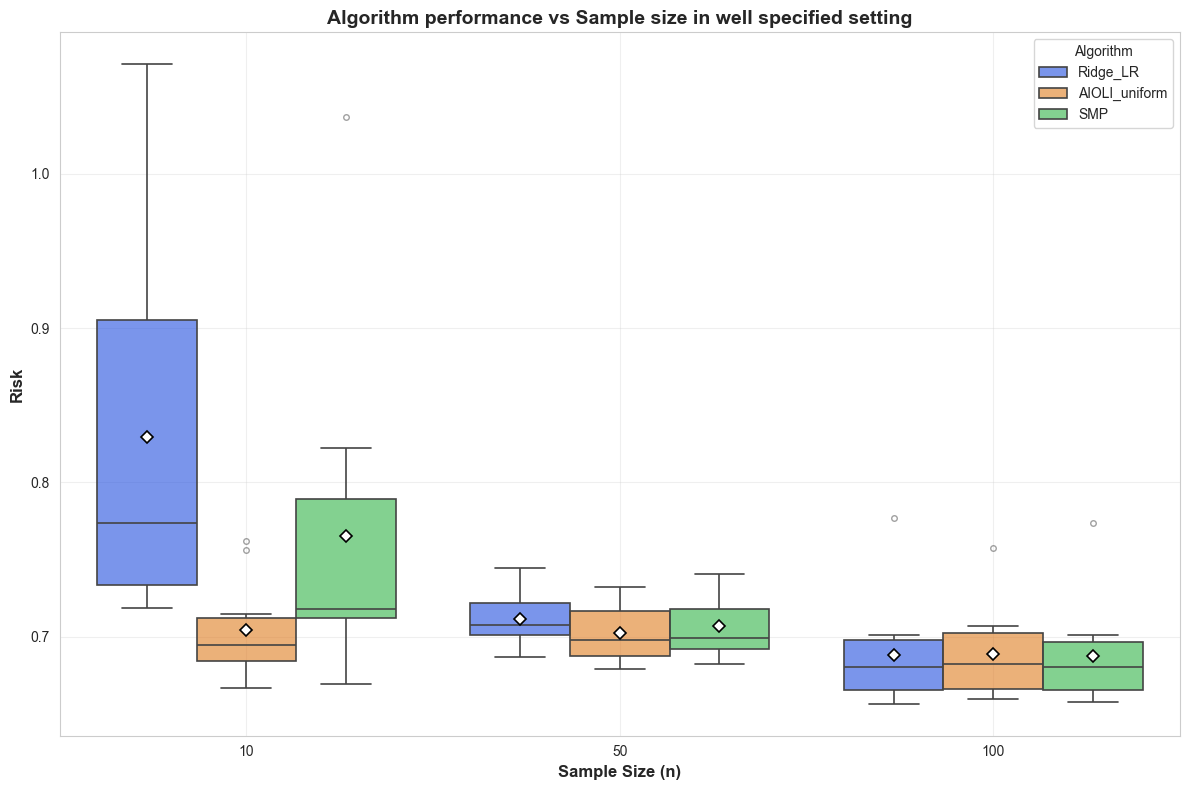

In [260]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR"] ,raw_data= well_specified_changing_n[1],  title= "Algorithm performance vs Sample size in well specified setting")

In [203]:

def plot_xy_dimensions(X, y, figsize=(14, 4), title="Feature vs Label "):
    """
    X: numpy array of shape (n, d)
    y: numpy array of shape (n,1)
    """

    X = np.asarray(X)
    y = np.asarray(y)

    n, d = X.shape
    fig, axes = plt.subplots(1, d, figsize=figsize)

    # Convert labels to colors
    palette = {1: "steelblue", -1: "darkred"}

    for j in range(d):
        ax = axes[j]
        sns.scatterplot(
            x=X[:, j],
            y=y,
            hue=y,
            palette=palette,
            ax=ax,
            s=40,
            alpha=0.8,
            legend=(j == d - 1)  # only show legend on last subplot
        )
        ax.set_xlabel(f"X[:, {j}]")
        ax.set_ylabel("y")
        ax.set_title(f"Dimension {j}")

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()


In [204]:
# plot_xy_dimensions(a[:,3:6],b)

# Datasets

In [ ]:
# to push

In [ ]:

# import kagglehub
# import os
#
# # Set cache to current directory
# os.environ['KAGGLEHUB_CACHE'] = os.getcwd()
#
# # Download latest version  returns the local path to the dataset folder
# path = kagglehub.dataset_download("ashrafkhan94/oil-spill")
# print("Dataset downloaded to:", path)
# print("Files:", os.listdir(path)[0])  # inspect actual filename(s)
# filename = os.listdir(path)[0]

In [ ]:
# csv_file = os.path.join(path, filename)  # adjust name based on os.listdir(path) output
# df = pd.read_csv(csv_file, header = None)

In [ ]:
# df = df.drop(df.columns[0],axis=1) # Remove first column because its for analysis based on the image number and its not one of the predictive variables.

In [ ]:
# df

In [ ]:
# trialdata = generate_data("well specified")

In [ ]:
# oil_x = df[df.columns[:-1]]

In [ ]:
# oil_y = df[df.columns[-1]]
# oil_y.replace(0, -1, inplace=True)
# oil_y

In [ ]:
# test_size = round(0.5*df.shape[0])
# oil_x_train = oil_x[test_size:]
# oil_y_train = oil_y[test_size:]
# oil_x_test = oil_x[:test_size]
# oil_y_test = oil_y[:test_size]

In [ ]:
# def evaluate_on_data(data_x,data_y):
#
#     # Separate test and train
#     test_size = round(0.5*data_x.shape[0])
#     x_train = np.array(data_x[test_size:])
#     y_train = np.array(data_y[test_size:])
#     x_test = np.array(data_x[:test_size])
#     y_test = np.array(data_y[:test_size])
#
#     d = data_x.shape[1]
#
#     # Run algorithms
#     ## Get SMOTE dataset for unbalanced cases
#     sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
#     smote_x, smote_y = sm.apply_smote()
#
#     ogd = online_gd(data_y=y_train, data_x=x_train, B=default_B)
#     adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(5,d))
#     aioli_model = AIOLI()
#     ai = aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=default_B/13)
#     classic_LR = classic_logistic_regression(data_x=x_train, data_y=y_train)
#     ridge_LR = ridge_logistic_regression(data_x=x_train, data_y=y_train)
#     lasso_LR = lasso_logistic_regression(data_x=x_train, data_y=y_train)
#     smp = sample_minmax_predictor(x_train, y_train)
#     ridge_smp = ridge_sample_minmax_predictor(x_train, y_train)
#     classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
#
#     # OTB estimates
#     # OGD
#     OGD_OTB_uniform = calculate_OTB(ogd["All_Betas"], "uniform")
#     OGD_OTB_Suffix  = calculate_OTB(ogd["All_Betas"], "suffix_averaging")
#     OGD_OTB_lastit  = calculate_OTB(ogd["All_Betas"], "last_iterate")
#     # AdaGrad
#     adagrad_OTB_uniform = calculate_OTB(adagrad["All_Betas"], "uniform")
#     adagrad_OTB_Suffix  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
#     adagrad_OTB_lastit  = calculate_OTB(adagrad["All_Betas"], "last_iterate")
#
#     ############################## TEST RESULTS ##############################
#     # OGD
#     loss_OGD_uniform_test = log_loss(OGD_OTB_uniform, x_test, y_test)
#     loss_OGD_Suffix_test  = log_loss(OGD_OTB_Suffix,  x_test, y_test)
#     loss_OGD_lastit_test  = log_loss(OGD_OTB_lastit,  x_test, y_test)
#
#     # Adagrad
#     loss_adagrad_uniform_test = log_loss(adagrad_OTB_uniform, x_test, y_test)
#     loss_adagrad_Suffix_test  = log_loss(adagrad_OTB_Suffix,  x_test, y_test)
#     loss_adagrad_lastit_test  = log_loss(adagrad_OTB_lastit,  x_test, y_test)
#
#     # AIOLI
#     loss_AIOLI_uniform_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
#     loss_AIOLI_Suffix_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"]
#     loss_AIOLI_lastit_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"]
#
#     # Logistic Regression
#     loss_LR_test = log_loss(classic_LR["Batch_estimate"], x_test, y_test)
#     loss_LR_smote_test = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
#     loss_LR_Ridge_test = log_loss(ridge_LR["Batch_estimate"],   x_test, y_test)
#     loss_LR_Lasso_test = log_loss(lasso_LR["Batch_estimate"],   x_test, y_test)
#
#     # SMP
#     smp_result = smp.get_new_loss(x_test, y_test)
#     ridge_smp_result = ridge_smp.get_new_loss(x_test, y_test)
#
#     algorithms_test = {
#         "Classical_LR":  {"loss": loss_LR_test},
#         "Classical_LR_SMOTE":      {"loss": loss_LR_smote_test},
#         "Ridge_LR":      {"loss": loss_LR_Ridge_test},
#         "Lasso_LR":      {"loss": loss_LR_Lasso_test},
#         "OGD_uniform": {"loss": loss_OGD_uniform_test},
#         "OGD_Suffix":  {"loss": loss_OGD_Suffix_test},
#         "OGD_Last_iterate": {"loss": loss_OGD_lastit_test},
#         "AdaGrad_uniform": {"loss": loss_adagrad_uniform_test},
#         "AdaGrad_Suffix":  {"loss": loss_adagrad_Suffix_test},
#         "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test},
#         "AIOLI_uniform": {"loss": loss_AIOLI_uniform_test},
#         "AIOLI_Suffix":  {"loss": loss_AIOLI_Suffix_test},
#         "AIOLI_lastit":  {"loss": loss_AIOLI_lastit_test},
#         "SMP":      {"loss": smp_result["loss"]},
#         "Ridge_SMP":      {"loss": ridge_smp_result["loss"]}
#     }
#
#     test_set_results = []
#     for name, metrics in algorithms_test.items():
#          test_set_results.append({
#             "algorithm": name,
#             **metrics
#         })
#
#     return {
#             "test_results": pd.DataFrame(test_set_results)
#         }


In [ ]:
# type(np.array(oil_x))

In [ ]:
# evaluate_on_data(oil_x,oil_y)

# Ignore from here on, it's simply code to test some functions/debugging

## AIOLI averaging outside sigmoid

In [ ]:
# class AIOLI:
#     def __init__(self):
#         self.first_sum  = []
#         self.etas_gradients = []
#         self.x0 = [] # Initializer for minimizing algorithm
#         self.reg_lambda = 0
#         self.train_size = 0
#         self.d = 0
#         self.n = 0
#
#     # Define function to minimize for AIOLI
#     @staticmethod # Because I dont use the self
#     def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
#         l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
#         # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
#         result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
#         return result
#
#     def new_point_loss(self,X,Y, OTB_method):
#         convergence_new = 0
#         beta_hat = np.zeros((self.train_size,self.d))
#         first_sum  = np.zeros(self.d)
#         etas_gradients = np.zeros((self.d,self.d))
#         for t in range(self.train_size):
#             # Minimize using data up until t-1
#             result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
#             beta_hat[t] = result.x
#             convergence_new += result.success
#             # Update minimization elements for next round
#             first_sum += self.first_sum[t]
#             etas_gradients += self.etas_gradients[t]
#
#         # Get OTB
#         big_beta = calculate_OTB(beta_hat, OTB_method)
#
#         # Suffer loss
#         loss_point = (1/self.n)*np.sum(np.logaddexp(0,-Y*np.inner(X,beta_hat)))
#
#         return loss_point
#
#     def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
#         start_time = datetime.datetime.now()
#         new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
#         end_time = datetime.datetime.now()
#         return{
#                 "runtime" : (end_time - start_time).total_seconds(),
#                 "loss" : sum(new_losses)
#             }
#
#
#     def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b", dynamic_B = False):
#         """AIOLI
#         This is the function to run AIOLI.
#
#         Parameters
#         ---------
#         data_y : ndarray
#             Vector with outcome(y) values. Dimensions: n x 1
#         data_x: ndarray
#             Array with independent variables. Dimensions: n x d
#         B: float
#             Radius of the L2 ball constraint for the parameter vector beta
#         X: float
#             Radius of the L2 ball constraint for the feature vector x"""
#         # Record start time
#         start_time = datetime.datetime.now()
#
#         # Get data dimensions
#         self.n = data_x.shape[0]
#         n = self.n
#         self.d = data_x.shape[1]
#         d = self.d
#         self.x0 = np.zeros(d) # Initializer for minimizing algorithm
#         self.train_size = n
#         # Initialize vectors for storage
#         betas = np.zeros((n, d))
#         ys = np.zeros(n)
#         y_hats = np.zeros(n)
#         loss = np.zeros(n)
#         etas = np.zeros(n)
#         gradients = np.zeros((n, d))
#         self.reg_lambda = 1 / (B**2)
#
#         # Keep sums for loss functions
#         self.first_sum  = np.zeros((n, d))
#         self.etas_gradients = np.zeros((n,d,d))
#         first_sum  = np.zeros(d)
#         etas_gradients = np.zeros((d,d))
#
#         # Track convergence
#         convergence = 0
#         minimizer_gradient = 0
#
#         # Run Algorithm
#         for t in range(n):
#             # Get context vector
#             xt = data_x[t]
#
#             # Update beta parameter
#             # noinspection PyTypeChecker # This is to avoid the underlining which
#             if t == 0: # Initialize to 0 for first round
#                 betas[t] = np.zeros(d)
#             else:
#                 result = minimize(self.parameter_function_AIOLI,
#                                   np.zeros(d),
#                                   method = minimize_method,
#                                   args=(xt, self.reg_lambda,first_sum, etas_gradients),
#                                   options = {"maxiter":100000}
#                                   )
#                 betas[t] = result.x
#                 convergence += result.success
#                 minimizer_gradient += np.linalg.norm(result.jac)
#
#             # # Project beta onto set
#             # betas[t] = project_onto_l2_ball(beta_tilde,B)
#             # betas[t] = self.x0
#
#             # Generate prediction
#             y_hats[t] = np.inner(xt,betas[t])
#
#             # Observe true y from data
#             ys[t] = data_y[t]
#
#              # Compute gradient
#             gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))
#
#             # Estimate eta
#             etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)
#
#             # Suffer loss
#             loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))
#
#             # Compute elements for AIOLI loss function
#
#             fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
#             eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
#             self.first_sum[t] = fs
#             self.etas_gradients[t] = eg
#             first_sum += fs
#             etas_gradients += eg
#             # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.
#
#             # Dynamic Hyperparameter tuning
#             if dynamic_B:
#                 B = max(B, np.linalg.norm(betas[t]))
#
#         # for loop ends
#
#         # Get Batch estimate
#         betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)
#
#         # Get Batch estimate loss
#         loss_OTB = log_loss(betas_OTB,data_x, data_y)
#
#         end_time = datetime.datetime.now()
#
#         return{
#             "runtime" : (end_time - start_time).total_seconds(),
#             "Total_Loss" : loss_OTB,
#             "Online_Loss" : sum(loss),
#             "Batch_estimate": betas_OTB,
#             "All_Betas": betas,
#             "convergence" : convergence,
#             "minimizer_gradient" : minimizer_gradient
#         }
#


## Tests

In [ ]:
#etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
#xt = np.array([1,2,3])
#betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
#reg_lambda = 0.3
#gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
#b = np.array([1,2,3])
#sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [ ]:
#diff = b - betas
#inner_prod = np.sum(gradients * diff,axis = 1)
#np.sum(np.sum(etas)/2 * inner_prod**2)

In [ ]:
# x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [ ]:
# diff = b - betas
# gs_bs = np.sum(gradients * diff,axis = 1)
# quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)
#
# l_hat = sum_loss + np.sum(gs_bs) + quadratic
#
# l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

## Generate data

In [ ]:
# n = 1000
#
# mean = [20, 5, 2]
# cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
# d = np.shape(cov)[1]
# y = np.random.binomial(n=1, p=0.3, size=n)
#
# x1, x2, x3 = np.random.multivariate_normal(mean, cov, size = n).T
# plt.plot(x1, x2, 'x')
# plt.axis('equal')
# plt.show()
#
# plt.plot(x1, x3, 'x')
# plt.axis('equal')
# plt.show()


In [ ]:
# x = np.random.multivariate_normal(mean, cov, size = n)
# sns.countplot(x=y)
# plt.show()


In [ ]:
# np.log(1000)

## OTB conversion proof tests

In [ ]:
# weights = np.array([0.3,0.7])
# values = np.array([2,3])
#
# print(np.sum(values))
# print(np.sum(weights*values))